# 05. Análisis complementario con PetFinder

En este notebook se desarrolla un análisis complementario a partir del dataset **PetFinder**, que incorpora información relacionada con la presentación pública de los perros, como fotografías, vídeos y descripciones textuales.

A diferencia del dataset principal, centrado principalmente en variables estructuradas asociadas al animal y a su estancia, PetFinder permite analizar además **factores de visibilidad, contenido descriptivo y características de la ficha de adopción** que podrían estar relacionados con una adopción más lenta.

El objetivo no es sustituir el modelo principal del proyecto, sino evaluar si estas señales adicionales permiten identificar patrones relevantes en un contexto externo y aportar una perspectiva complementaria al concepto de **Invisible Dogs**, sin mezclar ambos datasets ni utilizar PetFinder para entrenar el modelo final.


In [33]:
from pathlib import Path
import os
import sys
import warnings
import re
import json
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

In [34]:
# Definición de rutas del proyecto

current_path = Path.cwd()

if current_path.name == "notebooks":
    project_path = current_path.parent
else:
    project_path = current_path

data_path = project_path / "data"
processed_data_path = data_path / "processed"

# Carpeta donde se ha guardado y descomprimido PetFinder
petfinder_raw_path = data_path / "raw_petfinder"

outputs_path = project_path / "outputs"
figures_path = outputs_path / "figures"
petfinder_outputs_path = outputs_path / "petfinder"

figures_path.mkdir(parents=True, exist_ok=True)
petfinder_outputs_path.mkdir(parents=True, exist_ok=True)
processed_data_path.mkdir(parents=True, exist_ok=True)

print("Ruta del proyecto:")
print(project_path)

print("\nRuta esperada para PetFinder:")
print(petfinder_raw_path)

print("\n¿Existe la carpeta de PetFinder?")
print(petfinder_raw_path.exists())

Ruta del proyecto:
g:\Mi unidad\TFM\invisible-dogs-tfm

Ruta esperada para PetFinder:
g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder

¿Existe la carpeta de PetFinder?
True


## 1. Carga del dataset PetFinder

El dataset PetFinder.my Adoption Prediction contiene información estructurada de animales en adopción, junto con variables relacionadas con su presentación pública, como número de fotografías, vídeos y descripción textual.

En este notebook se utilizará PetFinder como análisis complementario externo. Para mantener la coherencia con el proyecto principal, el análisis se centrará en perros y no se combinará con los datos de Austin Animal Center.

Los archivos principales esperados son:

- `train.csv`
- `test.csv`
- `breed_labels.csv`
- `color_labels.csv`
- `state_labels.csv`

Además, si están disponibles, se revisarán las carpetas de imágenes, metadatos y sentimiento para preparar análisis posteriores vinculados a visibilidad, texto e imagen.

In [35]:
# Localización flexible de archivos de PetFinder

def buscar_archivo_petfinder(nombres_posibles, carpeta_base):
    """
    Busca un archivo dentro de la carpeta de PetFinder.
    Primero prueba rutas frecuentes y después hace una búsqueda recursiva.
    """
    if isinstance(nombres_posibles, str):
        nombres_posibles = [nombres_posibles]
    
    rutas_frecuentes = []
    
    for nombre in nombres_posibles:
        rutas_frecuentes.extend([
            carpeta_base / nombre,
            carpeta_base / "train" / nombre,
            carpeta_base / "test" / nombre,
            carpeta_base / "labels" / nombre,
        ])
    
    for ruta in rutas_frecuentes:
        if ruta.exists():
            return ruta
    
    candidatos = []
    
    if carpeta_base.exists():
        for nombre in nombres_posibles:
            candidatos.extend(list(carpeta_base.rglob(nombre)))
    
    if len(candidatos) == 0:
        return None
    
    candidatos = sorted(candidatos, key=lambda x: len(str(x)))
    return candidatos[0]


train_petfinder_path = buscar_archivo_petfinder(
    ["train.csv", "Train.csv"],
    petfinder_raw_path
)

test_petfinder_path = buscar_archivo_petfinder(
    ["test.csv", "Test.csv"],
    petfinder_raw_path
)

breed_labels_path = buscar_archivo_petfinder(
    ["breed_labels.csv", "BreedLabels.csv", "PetFinder-BreedLabels.csv"],
    petfinder_raw_path
)

color_labels_path = buscar_archivo_petfinder(
    ["color_labels.csv", "ColorLabels.csv", "PetFinder-ColorLabels.csv"],
    petfinder_raw_path
)

state_labels_path = buscar_archivo_petfinder(
    ["state_labels.csv", "StateLabels.csv", "PetFinder-StateLabels.csv"],
    petfinder_raw_path
)

rutas_petfinder = {
    "train.csv": train_petfinder_path,
    "test.csv": test_petfinder_path,
    "breed_labels.csv": breed_labels_path,
    "color_labels.csv": color_labels_path,
    "state_labels.csv": state_labels_path
}

print("Archivos localizados:")

for nombre, ruta in rutas_petfinder.items():
    print(f"{nombre}: {ruta}")

if train_petfinder_path is None:
    raise FileNotFoundError(
        "No se ha encontrado train.csv. Revisa que el ZIP de PetFinder esté descomprimido dentro de data/raw_petfinder."
    )

Archivos localizados:
train.csv: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\train\train.csv
test.csv: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\test\test.csv
breed_labels.csv: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\breed_labels.csv
color_labels.csv: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\color_labels.csv
state_labels.csv: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\state_labels.csv


In [36]:
# Localización de carpetas complementarias de PetFinder

def buscar_carpeta_petfinder(nombres_posibles, carpeta_base):
    if isinstance(nombres_posibles, str):
        nombres_posibles = [nombres_posibles]
    
    rutas_frecuentes = []
    
    for nombre in nombres_posibles:
        rutas_frecuentes.append(carpeta_base / nombre)
    
    for ruta in rutas_frecuentes:
        if ruta.exists() and ruta.is_dir():
            return ruta
    
    if carpeta_base.exists():
        for ruta in carpeta_base.rglob("*"):
            if ruta.is_dir() and ruta.name in nombres_posibles:
                return ruta
    
    return None


train_images_path = buscar_carpeta_petfinder(["train_images"], petfinder_raw_path)
test_images_path = buscar_carpeta_petfinder(["test_images"], petfinder_raw_path)
train_metadata_path = buscar_carpeta_petfinder(["train_metadata"], petfinder_raw_path)
test_metadata_path = buscar_carpeta_petfinder(["test_metadata"], petfinder_raw_path)
train_sentiment_path = buscar_carpeta_petfinder(["train_sentiment"], petfinder_raw_path)
test_sentiment_path = buscar_carpeta_petfinder(["test_sentiment"], petfinder_raw_path)

carpetas_petfinder = {
    "train_images": train_images_path,
    "test_images": test_images_path,
    "train_metadata": train_metadata_path,
    "test_metadata": test_metadata_path,
    "train_sentiment": train_sentiment_path,
    "test_sentiment": test_sentiment_path,
}

print("Carpetas complementarias localizadas:")

for nombre, ruta in carpetas_petfinder.items():
    print(f"{nombre}: {ruta}")

Carpetas complementarias localizadas:
train_images: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\train_images
test_images: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\test_images
train_metadata: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\train_metadata
test_metadata: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\test_metadata
train_sentiment: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\train_sentiment
test_sentiment: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_petfinder\test_sentiment


In [37]:
# Carga de archivos principales de PetFinder

petfinder_train = pd.read_csv(train_petfinder_path)

if test_petfinder_path is not None:
    petfinder_test = pd.read_csv(test_petfinder_path)
else:
    petfinder_test = None

if breed_labels_path is not None:
    breed_labels = pd.read_csv(breed_labels_path)
else:
    breed_labels = None

if color_labels_path is not None:
    color_labels = pd.read_csv(color_labels_path)
else:
    color_labels = None

if state_labels_path is not None:
    state_labels = pd.read_csv(state_labels_path)
else:
    state_labels = None

print("Dimensiones de PetFinder train:")
print(petfinder_train.shape)

if petfinder_test is not None:
    print("\nDimensiones de PetFinder test:")
    print(petfinder_test.shape)

print("\nPrimeras filas de PetFinder train:")
display(petfinder_train.head())

Dimensiones de PetFinder train:
(14993, 24)

Dimensiones de PetFinder test:
(3972, 23)

Primeras filas de PetFinder train:


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [38]:
# Revisión inicial de columnas y tipos de datos

resumen_columnas_petfinder = pd.DataFrame({
    "variable": petfinder_train.columns,
    "tipo_dato": petfinder_train.dtypes.astype(str).values,
    "n_nulos": petfinder_train.isna().sum().values,
    "porcentaje_nulos": (petfinder_train.isna().mean().values * 100).round(2),
    "n_valores_unicos": petfinder_train.nunique(dropna=False).values
})

print("Resumen de variables de PetFinder:")
display(resumen_columnas_petfinder)

resumen_columnas_petfinder_path = petfinder_outputs_path / "resumen_columnas_petfinder.csv"

resumen_columnas_petfinder.to_csv(
    resumen_columnas_petfinder_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de columnas guardado en:")
print(resumen_columnas_petfinder_path)

Resumen de variables de PetFinder:


,variable,tipo_dato,n_nulos,porcentaje_nulos,n_valores_unicos
0,Type,int64,0,0.00,2
1,Name,str,1265,8.44,9060
2,Age,int64,0,0.00,106
3,Breed1,int64,0,0.00,176
4,Breed2,int64,0,0.00,135
5,Gender,int64,0,0.00,3
6,Color1,int64,0,0.00,7
7,Color2,int64,0,0.00,7
8,Color3,int64,0,0.00,6
9,MaturitySize,int64,0,0.00,4


Resumen de columnas guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_columnas_petfinder.csv


In [39]:
# Comprobación de variables clave esperadas

variables_clave_petfinder = [
    "PetID",
    "Type",
    "Name",
    "Age",
    "Breed1",
    "Breed2",
    "Gender",
    "Color1",
    "Color2",
    "Color3",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Dewormed",
    "Sterilized",
    "Health",
    "Quantity",
    "Fee",
    "State",
    "VideoAmt",
    "Description",
    "PhotoAmt",
    "AdoptionSpeed"
]

comprobacion_variables_clave = pd.DataFrame({
    "variable": variables_clave_petfinder,
    "existe_en_dataset": [
        variable in petfinder_train.columns
        for variable in variables_clave_petfinder
    ]
})

print("Comprobación de variables clave:")
display(comprobacion_variables_clave)

variables_faltantes = comprobacion_variables_clave.loc[
    ~comprobacion_variables_clave["existe_en_dataset"],
    "variable"
].tolist()

if len(variables_faltantes) > 0:
    print("Variables clave no encontradas:")
    print(variables_faltantes)
else:
    print("Todas las variables clave están disponibles.")

Comprobación de variables clave:


,variable,existe_en_dataset
0,PetID,True
1,Type,True
2,Name,True
3,Age,True
4,Breed1,True
5,Breed2,True
6,Gender,True
7,Color1,True
8,Color2,True
9,Color3,True


Todas las variables clave están disponibles.


## 2. Variable objetivo: AdoptionSpeed

La variable `AdoptionSpeed` representa la velocidad de adopción del animal en PetFinder.

Los valores bajos representan adopciones más rápidas, mientras que los valores altos representan adopciones más lentas o ausencia de adopción dentro del periodo observado.

Para conectar este análisis con el objetivo principal del TFM, se construirá una variable binaria complementaria:

- `0`: adopción no lenta
- `1`: adopción lenta

En este notebook se considerará adopción lenta cuando `AdoptionSpeed >= 3`. Esta definición no es idéntica al target de Austin Animal Center, pero sí permite estudiar un concepto relacionado: animales con mayor dificultad o menor rapidez de adopción.

Distribución de AdoptionSpeed:


,AdoptionSpeed,n_animales,porcentaje
0,0,410,2.73
1,1,3090,20.61
2,2,4037,26.93
3,3,3259,21.74
4,4,4197,27.99


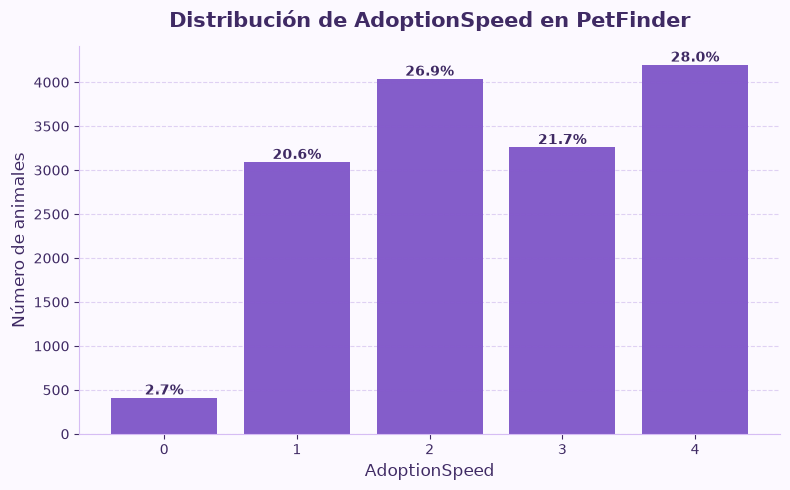

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_distribucion_adoption_speed.png


In [40]:
# Distribución de AdoptionSpeed

if "AdoptionSpeed" not in petfinder_train.columns:
    raise ValueError("No se encuentra la variable AdoptionSpeed en el dataset de entrenamiento.")

distribucion_adoption_speed = (
    petfinder_train["AdoptionSpeed"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("AdoptionSpeed")
    .reset_index(name="n_animales")
)

distribucion_adoption_speed["porcentaje"] = (
    distribucion_adoption_speed["n_animales"]
    / distribucion_adoption_speed["n_animales"].sum()
    * 100
).round(2)

print("Distribución de AdoptionSpeed:")
display(distribucion_adoption_speed)

fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    distribucion_adoption_speed["AdoptionSpeed"].astype(str),
    distribucion_adoption_speed["n_animales"],
    color="#6F42C1",
    alpha=0.85
)

for i, row in distribucion_adoption_speed.iterrows():
    ax.text(
        i,
        row["n_animales"],
        f'{row["porcentaje"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Distribución de AdoptionSpeed en PetFinder",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel("AdoptionSpeed", fontsize=12, color="#3F2A64")
ax.set_ylabel("Número de animales", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_distribucion_adoption_speed.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [41]:
# Filtrado de perros y creación del target de adopción lenta

petfinder = petfinder_train.copy()

if "Type" not in petfinder.columns:
    raise ValueError("No se encuentra la variable Type en PetFinder.")

# En PetFinder, Type = 1 corresponde a perros y Type = 2 a gatos
petfinder_dogs = petfinder.loc[petfinder["Type"] == 1].copy()

petfinder_dogs["target_adopcion_lenta"] = (
    petfinder_dogs["AdoptionSpeed"]
    .astype(int)
    .ge(3)
    .astype(int)
)

distribucion_target_adopcion_lenta = (
    petfinder_dogs["target_adopcion_lenta"]
    .value_counts(normalize=False)
    .sort_index()
    .rename_axis("target_adopcion_lenta")
    .reset_index(name="n_perros")
)

distribucion_target_adopcion_lenta["porcentaje"] = (
    distribucion_target_adopcion_lenta["n_perros"]
    / distribucion_target_adopcion_lenta["n_perros"].sum()
    * 100
).round(2)

print("Dimensiones del dataset completo:")
print(petfinder.shape)

print("\nDimensiones del dataset filtrado a perros:")
print(petfinder_dogs.shape)

print("\nDistribución del target de adopción lenta en perros:")
display(distribucion_target_adopcion_lenta)

Dimensiones del dataset completo:
(14993, 24)

Dimensiones del dataset filtrado a perros:
(8132, 25)

Distribución del target de adopción lenta en perros:


,target_adopcion_lenta,n_perros,porcentaje
0,0,3769,46.35
1,1,4363,53.65


In [42]:
# Guardado del dataset base de perros PetFinder

petfinder_dogs_base_path = processed_data_path / "petfinder_dogs_base.csv"

petfinder_dogs.to_csv(
    petfinder_dogs_base_path,
    index=False,
    encoding="utf-8-sig"
)

distribucion_adoption_speed_path = petfinder_outputs_path / "distribucion_adoption_speed.csv"
distribucion_target_adopcion_lenta_path = petfinder_outputs_path / "distribucion_target_adopcion_lenta_dogs.csv"

distribucion_adoption_speed.to_csv(
    distribucion_adoption_speed_path,
    index=False,
    encoding="utf-8-sig"
)

distribucion_target_adopcion_lenta.to_csv(
    distribucion_target_adopcion_lenta_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset base de perros PetFinder guardado en:")
print(petfinder_dogs_base_path)

print("\nDistribuciones guardadas en:")
print(distribucion_adoption_speed_path)
print(distribucion_target_adopcion_lenta_path)

Dataset base de perros PetFinder guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\petfinder_dogs_base.csv

Distribuciones guardadas en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\distribucion_adoption_speed.csv
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\distribucion_target_adopcion_lenta_dogs.csv


## 3. Enriquecimiento de variables

PetFinder contiene varias variables codificadas numéricamente, como raza, color, sexo, tamaño, longitud del pelaje, estado de vacunación, desparasitación, esterilización, salud y estado geográfico.

Para facilitar el análisis exploratorio y la interpretación, se transforman estos códigos en etiquetas legibles. Además, se crean variables derivadas relacionadas con edad, visibilidad, presencia de nombre, descripción, fotografías, vídeos y cuota de adopción.

Estas variables permiten analizar no solo características propias del animal, sino también elementos vinculados a su presentación pública, aspecto especialmente relevante para el concepto de *Invisible Dogs*.

In [43]:
# Enriquecimiento de variables de PetFinder

petfinder_dogs_enriched = petfinder_dogs.copy()

# Diccionarios principales de PetFinder
map_type = {
    1: "Perro",
    2: "Gato"
}

map_gender = {
    1: "Macho",
    2: "Hembra",
    3: "Mixto"
}

map_maturity_size = {
    1: "Pequeño",
    2: "Mediano",
    3: "Grande",
    4: "Muy grande",
    0: "No especificado"
}

map_fur_length = {
    1: "Corto",
    2: "Medio",
    3: "Largo",
    0: "No especificado"
}

map_yes_no_unknown = {
    1: "Sí",
    2: "No",
    3: "No seguro",
    0: "No especificado"
}

map_health = {
    1: "Sano",
    2: "Lesión leve",
    3: "Lesión grave",
    0: "No especificado"
}

map_adoption_speed = {
    0: "Adoptado el mismo día",
    1: "Adoptado en 1-7 días",
    2: "Adoptado en 8-30 días",
    3: "Adoptado en 31-90 días",
    4: "No adoptado tras 100 días"
}

# Etiquetas directas
petfinder_dogs_enriched["type_label"] = petfinder_dogs_enriched["Type"].map(map_type).fillna("Desconocido")
petfinder_dogs_enriched["gender_label"] = petfinder_dogs_enriched["Gender"].map(map_gender).fillna("Desconocido")
petfinder_dogs_enriched["maturity_size_label"] = petfinder_dogs_enriched["MaturitySize"].map(map_maturity_size).fillna("Desconocido")
petfinder_dogs_enriched["fur_length_label"] = petfinder_dogs_enriched["FurLength"].map(map_fur_length).fillna("Desconocido")
petfinder_dogs_enriched["vaccinated_label"] = petfinder_dogs_enriched["Vaccinated"].map(map_yes_no_unknown).fillna("Desconocido")
petfinder_dogs_enriched["dewormed_label"] = petfinder_dogs_enriched["Dewormed"].map(map_yes_no_unknown).fillna("Desconocido")
petfinder_dogs_enriched["sterilized_label"] = petfinder_dogs_enriched["Sterilized"].map(map_yes_no_unknown).fillna("Desconocido")
petfinder_dogs_enriched["health_label"] = petfinder_dogs_enriched["Health"].map(map_health).fillna("Desconocido")
petfinder_dogs_enriched["adoption_speed_label"] = petfinder_dogs_enriched["AdoptionSpeed"].map(map_adoption_speed).fillna("Desconocido")

# Raza principal y secundaria
if breed_labels is not None and {"BreedID", "BreedName"}.issubset(breed_labels.columns):
    breed_dict = breed_labels.set_index("BreedID")["BreedName"].to_dict()
    petfinder_dogs_enriched["breed1_name"] = petfinder_dogs_enriched["Breed1"].map(breed_dict).fillna("Desconocida")
    petfinder_dogs_enriched["breed2_name"] = petfinder_dogs_enriched["Breed2"].map(breed_dict).fillna("Sin segunda raza")
else:
    petfinder_dogs_enriched["breed1_name"] = petfinder_dogs_enriched["Breed1"].astype(str)
    petfinder_dogs_enriched["breed2_name"] = petfinder_dogs_enriched["Breed2"].astype(str)

# Colores
if color_labels is not None and {"ColorID", "ColorName"}.issubset(color_labels.columns):
    color_dict = color_labels.set_index("ColorID")["ColorName"].to_dict()
    petfinder_dogs_enriched["color1_name"] = petfinder_dogs_enriched["Color1"].map(color_dict).fillna("Desconocido")
    petfinder_dogs_enriched["color2_name"] = petfinder_dogs_enriched["Color2"].map(color_dict).fillna("Sin segundo color")
    petfinder_dogs_enriched["color3_name"] = petfinder_dogs_enriched["Color3"].map(color_dict).fillna("Sin tercer color")
else:
    petfinder_dogs_enriched["color1_name"] = petfinder_dogs_enriched["Color1"].astype(str)
    petfinder_dogs_enriched["color2_name"] = petfinder_dogs_enriched["Color2"].astype(str)
    petfinder_dogs_enriched["color3_name"] = petfinder_dogs_enriched["Color3"].astype(str)

# Estado geográfico
if state_labels is not None and {"StateID", "StateName"}.issubset(state_labels.columns):
    state_dict = state_labels.set_index("StateID")["StateName"].to_dict()
    petfinder_dogs_enriched["state_name"] = petfinder_dogs_enriched["State"].map(state_dict).fillna("Desconocido")
else:
    petfinder_dogs_enriched["state_name"] = petfinder_dogs_enriched["State"].astype(str)

# Variables derivadas de raza
petfinder_dogs_enriched["is_mixed_breed"] = (
    petfinder_dogs_enriched["Breed2"].fillna(0).astype(int).ne(0)
)

petfinder_dogs_enriched["is_mixed_breed_label"] = np.where(
    petfinder_dogs_enriched["is_mixed_breed"],
    "Raza mixta",
    "Raza única"
)

# Variables de nombre
petfinder_dogs_enriched["name_clean"] = (
    petfinder_dogs_enriched["Name"]
    .fillna("")
    .astype(str)
    .str.strip()
)

nombres_sin_nombre = [
    "",
    "no name",
    "no name yet",
    "noname",
    "unnamed",
    "unknown",
    "none",
    "nameless"
]

petfinder_dogs_enriched["has_name"] = ~(
    petfinder_dogs_enriched["name_clean"]
    .str.lower()
    .isin(nombres_sin_nombre)
)

petfinder_dogs_enriched["has_name_label"] = np.where(
    petfinder_dogs_enriched["has_name"],
    "Con nombre",
    "Sin nombre"
)

# Variables de edad
petfinder_dogs_enriched["age_months"] = petfinder_dogs_enriched["Age"].astype(float)

petfinder_dogs_enriched["age_group_petfinder"] = pd.cut(
    petfinder_dogs_enriched["age_months"],
    bins=[-1, 3, 12, 60, 300],
    labels=[
        "Cachorro: 0-3 meses",
        "Joven: 4-12 meses",
        "Adulto: 13-60 meses",
        "Senior: >60 meses"
    ]
)

# Variables de visibilidad
petfinder_dogs_enriched["photo_group"] = pd.cut(
    petfinder_dogs_enriched["PhotoAmt"].astype(float),
    bins=[-0.1, 0, 1, 4, 100],
    labels=[
        "Sin fotos",
        "1 foto",
        "2-4 fotos",
        "5 o más fotos"
    ]
)

petfinder_dogs_enriched["video_group"] = pd.cut(
    petfinder_dogs_enriched["VideoAmt"].astype(float),
    bins=[-0.1, 0, 1, 100],
    labels=[
        "Sin vídeo",
        "1 vídeo",
        "2 o más vídeos"
    ]
)

petfinder_dogs_enriched["has_photo"] = petfinder_dogs_enriched["PhotoAmt"].astype(float).gt(0)
petfinder_dogs_enriched["has_video"] = petfinder_dogs_enriched["VideoAmt"].astype(float).gt(0)

petfinder_dogs_enriched["has_photo_label"] = np.where(
    petfinder_dogs_enriched["has_photo"],
    "Con fotos",
    "Sin fotos"
)

petfinder_dogs_enriched["has_video_label"] = np.where(
    petfinder_dogs_enriched["has_video"],
    "Con vídeo",
    "Sin vídeo"
)

# Variables de descripción
petfinder_dogs_enriched["description_clean"] = (
    petfinder_dogs_enriched["Description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

petfinder_dogs_enriched["has_description"] = petfinder_dogs_enriched["description_clean"].str.len().gt(0)

petfinder_dogs_enriched["has_description_label"] = np.where(
    petfinder_dogs_enriched["has_description"],
    "Con descripción",
    "Sin descripción"
)

petfinder_dogs_enriched["description_chars"] = petfinder_dogs_enriched["description_clean"].str.len()

petfinder_dogs_enriched["description_words"] = (
    petfinder_dogs_enriched["description_clean"]
    .str.split()
    .apply(len)
)

petfinder_dogs_enriched["description_group"] = pd.cut(
    petfinder_dogs_enriched["description_words"],
    bins=[-1, 0, 20, 60, 120, 5000],
    labels=[
        "Sin descripción",
        "Descripción corta",
        "Descripción media",
        "Descripción larga",
        "Descripción muy larga"
    ]
)

# Variables de cuota de adopción
petfinder_dogs_enriched["has_fee"] = petfinder_dogs_enriched["Fee"].astype(float).gt(0)

petfinder_dogs_enriched["has_fee_label"] = np.where(
    petfinder_dogs_enriched["has_fee"],
    "Con fee",
    "Sin fee"
)

petfinder_dogs_enriched["fee_group"] = pd.cut(
    petfinder_dogs_enriched["Fee"].astype(float),
    bins=[-1, 0, 50, 100, 5000],
    labels=[
        "Sin fee",
        "Fee 1-50",
        "Fee 51-100",
        "Fee >100"
    ]
)

print("Dimensiones del dataset enriquecido de perros PetFinder:")
print(petfinder_dogs_enriched.shape)

print("\nPrimeras columnas enriquecidas:")
columnas_muestra_enriquecida = [
    "PetID",
    "Name",
    "age_months",
    "age_group_petfinder",
    "breed1_name",
    "breed2_name",
    "is_mixed_breed_label",
    "gender_label",
    "sterilized_label",
    "health_label",
    "PhotoAmt",
    "photo_group",
    "VideoAmt",
    "video_group",
    "description_words",
    "description_group",
    "AdoptionSpeed",
    "adoption_speed_label",
    "target_adopcion_lenta"
]

display(petfinder_dogs_enriched[columnas_muestra_enriquecida].head(10))

Dimensiones del dataset enriquecido de perros PetFinder:
(8132, 62)

Primeras columnas enriquecidas:


,PetID,Name,age_months,age_group_petfinder,breed1_name,breed2_name,is_mixed_breed_label,gender_label,sterilized_label,health_label,PhotoAmt,photo_group,VideoAmt,video_group,description_words,description_group,AdoptionSpeed,adoption_speed_label,target_adopcion_lenta
2,3422e4906,Brisco,1.0,Cachorro: 0-3 meses,Mixed Breed,Sin segunda raza,Raza única,Macho,No,Sano,7.0,5 o más fotos,0,Sin vídeo,69,Descripción larga,3,Adoptado en 31-90 días,1
3,5842f1ff5,Miko,4.0,Joven: 4-12 meses,Mixed Breed,Sin segunda raza,Raza única,Hembra,No,Sano,8.0,5 o más fotos,0,Sin vídeo,25,Descripción media,2,Adoptado en 8-30 días,0
4,850a43f90,Hunter,1.0,Cachorro: 0-3 meses,Mixed Breed,Sin segunda raza,Raza única,Macho,No,Sano,3.0,2-4 fotos,0,Sin vídeo,81,Descripción larga,2,Adoptado en 8-30 días,0
7,97aa9eeac,Siu Pak & Her 6 Puppies,0.0,Cachorro: 0-3 meses,Mixed Breed,Sin segunda raza,Raza única,Hembra,No,Sano,9.0,5 o más fotos,0,Sin vídeo,20,Descripción corta,3,Adoptado en 31-90 días,1
10,8b693ca84,Bear,2.0,Cachorro: 0-3 meses,Mixed Breed,Sin segunda raza,Raza única,Macho,No,Sano,7.0,5 o más fotos,0,Sin vídeo,12,Descripción corta,1,Adoptado en 1-7 días,0
12,aaedd873d,Peanut,2.0,Cachorro: 0-3 meses,Mixed Breed,Sin segunda raza,Raza única,Macho,No,Sano,1.0,1 foto,0,Sin vídeo,49,Descripción media,2,Adoptado en 8-30 días,0
14,c02be41e6,Lost Dog,3.0,Cachorro: 0-3 meses,Mixed Breed,Sin segunda raza,Raza única,Hembra,No seguro,Sano,2.0,2-4 fotos,0,Sin vídeo,67,Descripción larga,2,Adoptado en 8-30 días,0
15,1fd342e17,Max,78.0,Senior: >60 meses,Terrier,Shih Tzu,Raza mixta,Macho,No seguro,Sano,2.0,2-4 fotos,0,Sin vídeo,68,Descripción larga,4,No adoptado tras 100 días,1
17,f9d07d5fa,Blackie,8.0,Joven: 4-12 meses,Mixed Breed,Mixed Breed,Raza mixta,Hembra,Sí,Sano,2.0,2-4 fotos,0,Sin vídeo,71,Descripción larga,4,No adoptado tras 100 días,1
18,1c92ce464,Beauty,2.0,Cachorro: 0-3 meses,Mixed Breed,Sin segunda raza,Raza única,Hembra,No,Sano,8.0,5 o más fotos,0,Sin vídeo,139,Descripción muy larga,2,Adoptado en 8-30 días,0


In [44]:
# Guardado del dataset enriquecido de perros PetFinder

petfinder_dogs_enriched_path = processed_data_path / "petfinder_dogs_enriched.csv"

petfinder_dogs_enriched.to_csv(
    petfinder_dogs_enriched_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset enriquecido de perros PetFinder guardado en:")
print(petfinder_dogs_enriched_path)

Dataset enriquecido de perros PetFinder guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\petfinder_dogs_enriched.csv


## 4. Análisis exploratorio estructurado

A continuación se analiza la relación entre la adopción lenta y distintas variables estructuradas del dataset PetFinder.

El objetivo no es extraer conclusiones causales, sino identificar patrones descriptivos que puedan ayudar a comprender qué características aparecen asociadas a una mayor dificultad de adopción en este dataset externo.

Este análisis complementa el trabajo realizado con Austin Animal Center, incorporando variables que no estaban disponibles en el dataset principal, como número de fotografías, vídeos, descripción textual y cuota de adopción.

In [45]:
# Función de resumen de adopción lenta por variable categórica

def resumen_adopcion_lenta_por_categoria(df, variable, nombre_variable=None, min_n=20):
    if nombre_variable is None:
        nombre_variable = variable
    
    resumen = (
        df
        .groupby(variable, observed=False)
        .agg(
            n_perros=("target_adopcion_lenta", "size"),
            n_adopcion_lenta=("target_adopcion_lenta", "sum"),
            tasa_adopcion_lenta=("target_adopcion_lenta", "mean"),
            adoption_speed_medio=("AdoptionSpeed", "mean"),
            adoption_speed_mediano=("AdoptionSpeed", "median")
        )
        .reset_index()
        .rename(columns={variable: "categoria"})
    )
    
    resumen["variable"] = nombre_variable
    resumen["porcentaje_perros"] = (
        resumen["n_perros"] / resumen["n_perros"].sum() * 100
    )
    
    resumen = resumen.loc[resumen["n_perros"] >= min_n].copy()
    
    resumen = resumen[
        [
            "variable",
            "categoria",
            "n_perros",
            "porcentaje_perros",
            "n_adopcion_lenta",
            "tasa_adopcion_lenta",
            "adoption_speed_medio",
            "adoption_speed_mediano"
        ]
    ]
    
    resumen["porcentaje_perros"] = resumen["porcentaje_perros"].round(2)
    resumen["tasa_adopcion_lenta"] = resumen["tasa_adopcion_lenta"].round(4)
    resumen["adoption_speed_medio"] = resumen["adoption_speed_medio"].round(4)
    resumen["adoption_speed_mediano"] = resumen["adoption_speed_mediano"].round(4)
    
    return resumen.sort_values(
        ["tasa_adopcion_lenta", "n_perros"],
        ascending=[False, False]
    ).reset_index(drop=True)


variables_eda_petfinder = {
    "age_group_petfinder": "Grupo de edad",
    "gender_label": "Sexo",
    "sterilized_label": "Esterilización",
    "vaccinated_label": "Vacunación",
    "dewormed_label": "Desparasitación",
    "health_label": "Salud",
    "maturity_size_label": "Tamaño",
    "fur_length_label": "Longitud del pelaje",
    "is_mixed_breed_label": "Tipo de raza",
    "photo_group": "Número de fotos",
    "video_group": "Número de vídeos",
    "has_name_label": "Presencia de nombre",
    "has_description_label": "Presencia de descripción",
    "description_group": "Longitud de descripción",
    "has_fee_label": "Presencia de fee",
    "fee_group": "Grupo de fee"
}

resumenes_eda_petfinder = []

for variable, nombre_variable in variables_eda_petfinder.items():
    resumen_variable = resumen_adopcion_lenta_por_categoria(
        df=petfinder_dogs_enriched,
        variable=variable,
        nombre_variable=nombre_variable,
        min_n=20
    )
    resumenes_eda_petfinder.append(resumen_variable)

resumen_eda_petfinder = pd.concat(
    resumenes_eda_petfinder,
    ignore_index=True
)

resumen_eda_petfinder_path = petfinder_outputs_path / "resumen_eda_adopcion_lenta_petfinder.csv"

resumen_eda_petfinder.to_csv(
    resumen_eda_petfinder_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen EDA de adopción lenta guardado en:")
print(resumen_eda_petfinder_path)

print("\nPrimeras filas del resumen EDA:")
display(resumen_eda_petfinder.head(30))

Resumen EDA de adopción lenta guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_eda_adopcion_lenta_petfinder.csv

Primeras filas del resumen EDA:


,variable,categoria,n_perros,porcentaje_perros,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,adoption_speed_mediano
0,Grupo de edad,Joven: 4-12 meses,1913,23.52,1239,0.6477,2.9012,3.0
1,Grupo de edad,Adulto: 13-60 meses,1596,19.63,953,0.5971,2.7462,3.0
2,Grupo de edad,Senior: >60 meses,327,4.02,191,0.5841,2.7492,3.0
3,Grupo de edad,Cachorro: 0-3 meses,4296,52.83,1980,0.4609,2.4288,2.0
4,Sexo,Mixto,875,10.76,508,0.5806,2.7497,3.0
5,Sexo,Hembra,4252,52.29,2408,0.5663,2.6771,3.0
6,Sexo,Macho,3005,36.95,1447,0.4815,2.4882,2.0
7,Esterilización,Sí,1843,22.66,1239,0.6723,2.9457,3.0
8,Esterilización,No seguro,1117,13.74,676,0.6052,2.8111,3.0
9,Esterilización,No,5172,63.60,2448,0.4733,2.4549,2.0


In [46]:
# Función para graficar tasa de adopción lenta por categoría manteniendo formato visual del proyecto

def graficar_tasa_adopcion_lenta(
    resumen_variable,
    titulo,
    nombre_archivo,
    top_n=None
):
    datos_plot = resumen_variable.copy()
    
    if top_n is not None:
        datos_plot = datos_plot.head(top_n)
    
    datos_plot = datos_plot.sort_values("tasa_adopcion_lenta", ascending=True)
    
    fig_height = max(4.5, 0.42 * len(datos_plot) + 1.5)
    
    fig, ax = plt.subplots(figsize=(10, fig_height))
    
    fig.patch.set_facecolor("#FCF9FF")
    ax.set_facecolor("#FCF9FF")
    
    ax.barh(
        datos_plot["categoria"].astype(str),
        datos_plot["tasa_adopcion_lenta"],
        color="#6F42C1",
        alpha=0.85
    )
    
    for i, row in enumerate(datos_plot.itertuples()):
        ax.text(
            row.tasa_adopcion_lenta + 0.01,
            i,
            f"{row.tasa_adopcion_lenta:.3f}",
            va="center",
            ha="left",
            fontsize=9,
            color="#3F2A64",
            fontweight="bold"
        )
    
    ax.set_title(
        titulo,
        fontsize=15,
        fontweight="bold",
        color="#3F2A64",
        pad=14
    )
    
    ax.set_xlabel(
        "Tasa de adopción lenta",
        fontsize=12,
        color="#3F2A64"
    )
    
    ax.set_ylabel(
        "Categoría",
        fontsize=12,
        color="#3F2A64"
    )
    
    ax.set_xlim(0, min(1.05, max(datos_plot["tasa_adopcion_lenta"].max() + 0.12, 0.65)))
    
    ax.tick_params(axis="x", colors="#3F2A64")
    ax.tick_params(axis="y", colors="#3F2A64")
    
    ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
    ax.grid(axis="y", visible=False)
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    
    ax.spines["left"].set_color("#D6BDF4")
    ax.spines["bottom"].set_color("#D6BDF4")
    
    fig.tight_layout()
    
    fig_path = figures_path / nombre_archivo
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print("Gráfico guardado en:")
    print(fig_path)

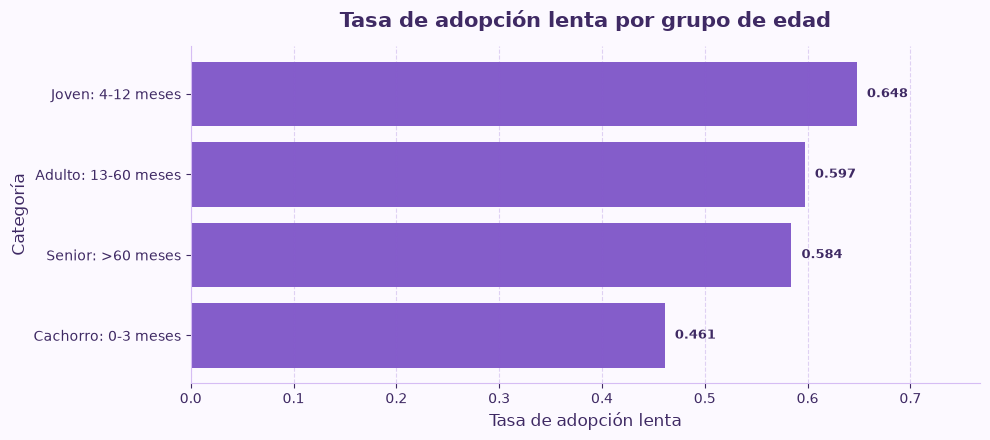

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_edad.png


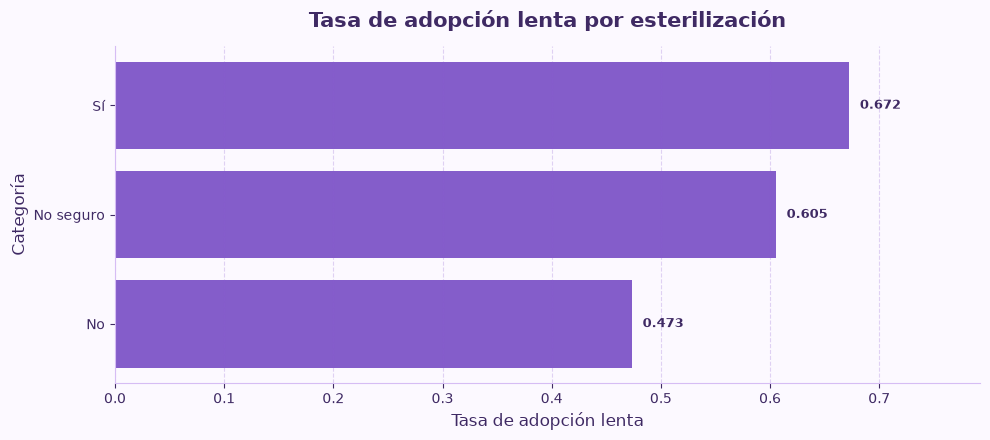

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_esterilizacion.png


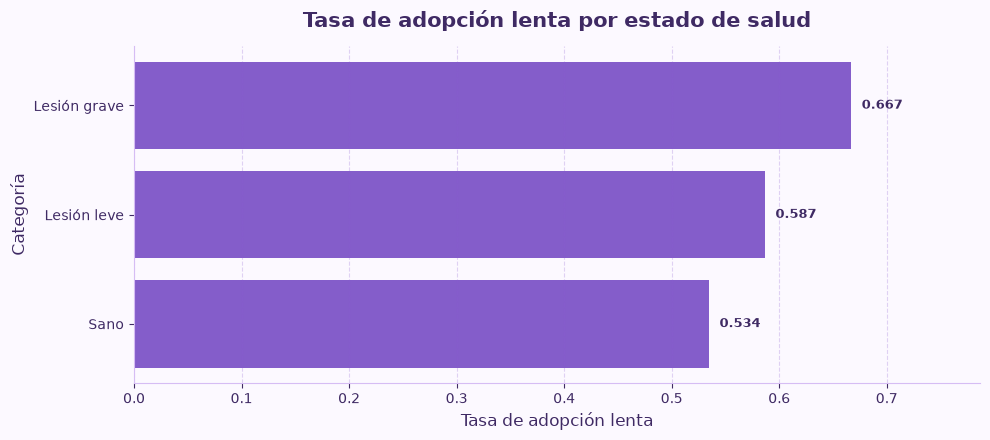

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_salud.png


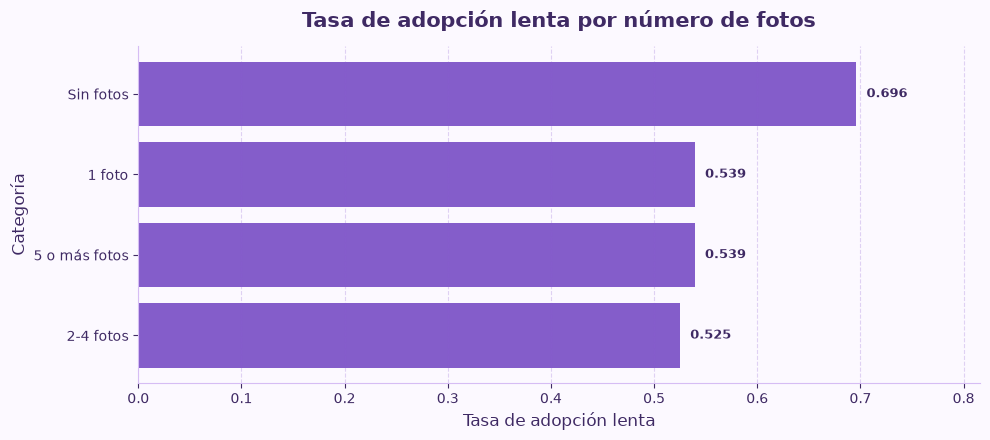

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_fotos.png


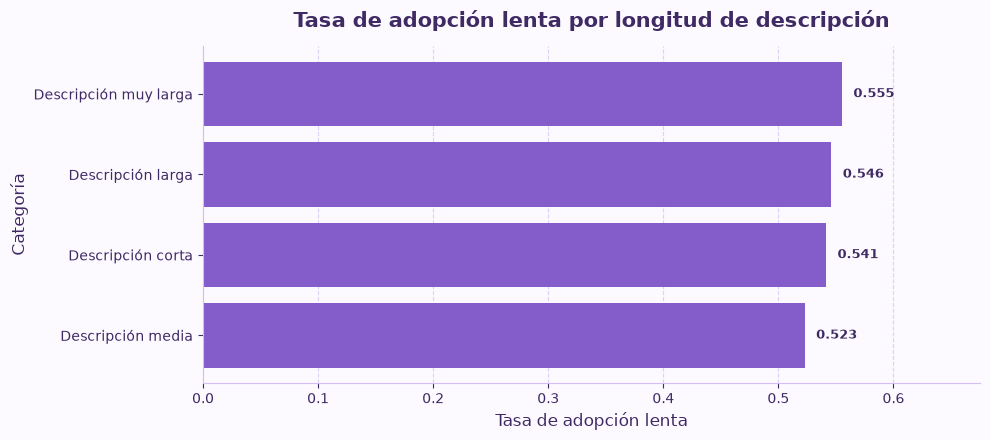

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_descripcion.png


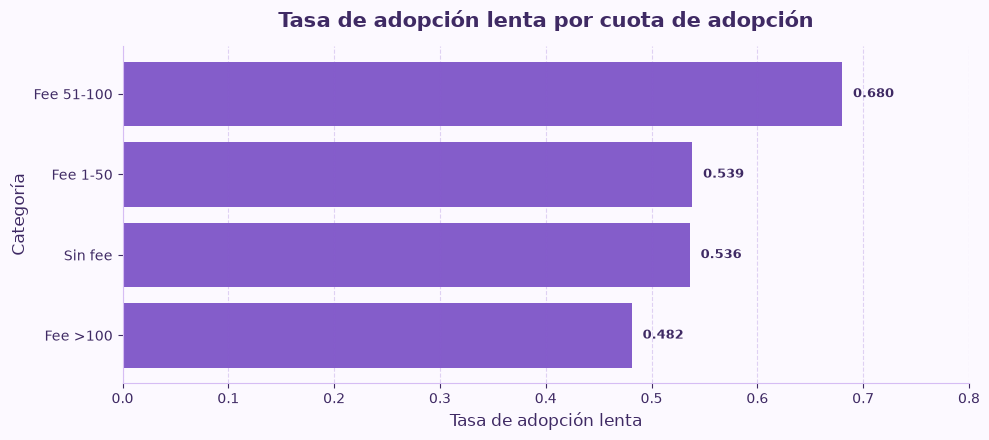

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_fee.png


In [47]:
# Gráficas principales del análisis exploratorio estructurado

graficas_eda_petfinder = [
    (
        "age_group_petfinder",
        "Tasa de adopción lenta por grupo de edad",
        "petfinder_tasa_adopcion_lenta_por_edad.png"
    ),
    (
        "sterilized_label",
        "Tasa de adopción lenta por esterilización",
        "petfinder_tasa_adopcion_lenta_por_esterilizacion.png"
    ),
    (
        "health_label",
        "Tasa de adopción lenta por estado de salud",
        "petfinder_tasa_adopcion_lenta_por_salud.png"
    ),
    (
        "photo_group",
        "Tasa de adopción lenta por número de fotos",
        "petfinder_tasa_adopcion_lenta_por_fotos.png"
    ),
    (
        "description_group",
        "Tasa de adopción lenta por longitud de descripción",
        "petfinder_tasa_adopcion_lenta_por_descripcion.png"
    ),
    (
        "fee_group",
        "Tasa de adopción lenta por cuota de adopción",
        "petfinder_tasa_adopcion_lenta_por_fee.png"
    )
]

for variable, titulo, nombre_archivo in graficas_eda_petfinder:
    resumen_variable = resumen_adopcion_lenta_por_categoria(
        df=petfinder_dogs_enriched,
        variable=variable,
        nombre_variable=variables_eda_petfinder.get(variable, variable),
        min_n=20
    )
    
    graficar_tasa_adopcion_lenta(
        resumen_variable=resumen_variable,
        titulo=titulo,
        nombre_archivo=nombre_archivo
    )

El análisis exploratorio estructurado permite estudiar cómo varía la tasa de adopción lenta según distintas características del animal y de su presentación pública.

A diferencia de Austin Animal Center, PetFinder incorpora variables directamente relacionadas con la visibilidad del animal, como número de fotografías, vídeos y descripción textual. Estas variables son especialmente relevantes para el enfoque del proyecto, ya que permiten analizar no solo el perfil del perro, sino también cómo se presenta ante posibles adoptantes.

Los resultados de este bloque deben interpretarse como patrones descriptivos. No implican causalidad, pero ayudan a identificar variables candidatas para los modelos complementarios posteriores y para el diseño del prototipo final de la aplicación.

## 5. Análisis de variables de visibilidad

PetFinder permite estudiar variables relacionadas con la presentación pública del animal, como la presencia de fotografías, vídeos, nombre, descripción textual y cuota de adopción.

Este bloque profundiza en estas variables porque son especialmente relevantes para el concepto de *Invisible Dogs*. En un entorno de adopción online, un perro puede tener mayor dificultad de adopción no solo por sus características individuales, sino también por la forma en que se presenta ante posibles adoptantes.

El objetivo de este análisis es evaluar si las variables de visibilidad muestran diferencias entre perros con adopción lenta y no lenta.

In [48]:
# Resumen de variables numéricas de visibilidad según adopción lenta

variables_visibilidad_numericas = [
    "PhotoAmt",
    "VideoAmt",
    "description_chars",
    "description_words",
    "Fee"
]

resumen_visibilidad_por_target = (
    petfinder_dogs_enriched
    .groupby("target_adopcion_lenta")
    .agg(
        n_perros=("PetID", "size"),
        photo_mean=("PhotoAmt", "mean"),
        photo_median=("PhotoAmt", "median"),
        video_mean=("VideoAmt", "mean"),
        video_median=("VideoAmt", "median"),
        description_words_mean=("description_words", "mean"),
        description_words_median=("description_words", "median"),
        description_chars_mean=("description_chars", "mean"),
        description_chars_median=("description_chars", "median"),
        fee_mean=("Fee", "mean"),
        fee_median=("Fee", "median")
    )
    .reset_index()
)

resumen_visibilidad_por_target["target_label"] = resumen_visibilidad_por_target["target_adopcion_lenta"].map({
    0: "Adopción no lenta",
    1: "Adopción lenta"
})

columnas_redondear_visibilidad = [
    "photo_mean",
    "photo_median",
    "video_mean",
    "video_median",
    "description_words_mean",
    "description_words_median",
    "description_chars_mean",
    "description_chars_median",
    "fee_mean",
    "fee_median"
]

resumen_visibilidad_por_target[columnas_redondear_visibilidad] = (
    resumen_visibilidad_por_target[columnas_redondear_visibilidad]
    .round(3)
)

resumen_visibilidad_por_target_path = petfinder_outputs_path / "resumen_visibilidad_por_target_petfinder.csv"

resumen_visibilidad_por_target.to_csv(
    resumen_visibilidad_por_target_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de variables de visibilidad por target:")
display(resumen_visibilidad_por_target)

print("Resumen guardado en:")
print(resumen_visibilidad_por_target_path)

Resumen de variables de visibilidad por target:


,target_adopcion_lenta,n_perros,photo_mean,photo_median,video_mean,video_median,description_words_mean,description_words_median,description_chars_mean,description_chars_median,fee_mean,fee_median,target_label
0,0,3769,3.663,3.0,0.052,0.0,59.538,42.0,321.062,229.0,26.663,0.0,Adopción no lenta
1,1,4363,3.790,3.0,0.064,0.0,62.485,43.0,336.475,231.0,22.249,0.0,Adopción lenta


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_visibilidad_por_target_petfinder.csv


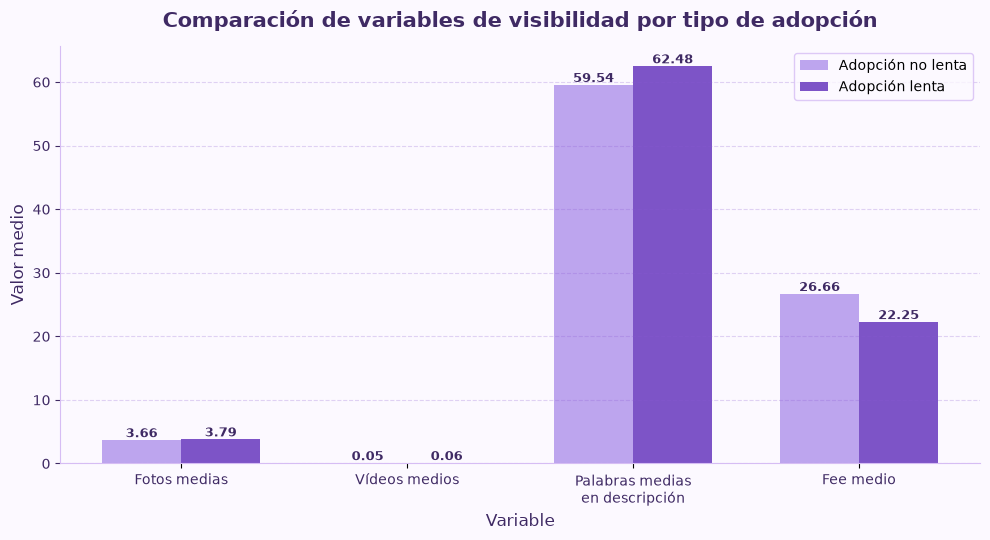

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_comparacion_visibilidad_por_target.png


In [49]:
# Gráfico comparativo de variables de visibilidad por adopción lenta

metricas_visibilidad_plot = pd.DataFrame({
    "variable": [
        "Fotos medias",
        "Vídeos medios",
        "Palabras medias\nen descripción",
        "Fee medio"
    ],
    "adopcion_no_lenta": [
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 0,
            "photo_mean"
        ].iloc[0],
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 0,
            "video_mean"
        ].iloc[0],
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 0,
            "description_words_mean"
        ].iloc[0],
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 0,
            "fee_mean"
        ].iloc[0]
    ],
    "adopcion_lenta": [
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 1,
            "photo_mean"
        ].iloc[0],
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 1,
            "video_mean"
        ].iloc[0],
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 1,
            "description_words_mean"
        ].iloc[0],
        resumen_visibilidad_por_target.loc[
            resumen_visibilidad_por_target["target_adopcion_lenta"] == 1,
            "fee_mean"
        ].iloc[0]
    ]
})

metricas_visibilidad_plot_melt = metricas_visibilidad_plot.melt(
    id_vars="variable",
    value_vars=["adopcion_no_lenta", "adopcion_lenta"],
    var_name="grupo",
    value_name="valor"
)

metricas_visibilidad_plot_melt["grupo"] = metricas_visibilidad_plot_melt["grupo"].map({
    "adopcion_no_lenta": "Adopción no lenta",
    "adopcion_lenta": "Adopción lenta"
})

fig, ax = plt.subplots(figsize=(10, 5.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

x = np.arange(len(metricas_visibilidad_plot["variable"]))
width = 0.35

datos_no_lenta = metricas_visibilidad_plot["adopcion_no_lenta"].values
datos_lenta = metricas_visibilidad_plot["adopcion_lenta"].values

bars1 = ax.bar(
    x - width / 2,
    datos_no_lenta,
    width,
    label="Adopción no lenta",
    color="#B79CED",
    alpha=0.9
)

bars2 = ax.bar(
    x + width / 2,
    datos_lenta,
    width,
    label="Adopción lenta",
    color="#6F42C1",
    alpha=0.9
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "Comparación de variables de visibilidad por tipo de adopción",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel("Variable", fontsize=12, color="#3F2A64")
ax.set_ylabel("Valor medio", fontsize=12, color="#3F2A64")

ax.set_xticks(x)
ax.set_xticklabels(metricas_visibilidad_plot["variable"], color="#3F2A64")

ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF")
legend.get_frame().set_edgecolor("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_comparacion_visibilidad_por_target.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

### 5.1. Calidad básica de la ficha del animal

Además de analizar cada variable de visibilidad por separado, se construye una variable sintética de calidad básica de ficha.

Esta variable no pretende ser una medida definitiva, sino una aproximación sencilla basada en elementos observables:

- presencia de nombre;
- presencia de fotografías;
- número suficiente de fotografías;
- presencia de descripción;
- descripción con una longitud mínima;
- presencia de vídeo.

Esta lógica resulta útil para el diseño posterior del prototipo, ya que permite transformar variables dispersas en una señal interpretable sobre la presentación pública del perro.

In [50]:
# Creación de un score simple de calidad básica de ficha

petfinder_dogs_enriched["score_calidad_ficha"] = 0

petfinder_dogs_enriched["score_calidad_ficha"] += petfinder_dogs_enriched["has_name"].astype(int)
petfinder_dogs_enriched["score_calidad_ficha"] += petfinder_dogs_enriched["has_photo"].astype(int)
petfinder_dogs_enriched["score_calidad_ficha"] += petfinder_dogs_enriched["PhotoAmt"].astype(float).ge(3).astype(int)
petfinder_dogs_enriched["score_calidad_ficha"] += petfinder_dogs_enriched["has_description"].astype(int)
petfinder_dogs_enriched["score_calidad_ficha"] += petfinder_dogs_enriched["description_words"].ge(30).astype(int)
petfinder_dogs_enriched["score_calidad_ficha"] += petfinder_dogs_enriched["has_video"].astype(int)

petfinder_dogs_enriched["calidad_ficha_label"] = pd.cut(
    petfinder_dogs_enriched["score_calidad_ficha"],
    bins=[-1, 1, 3, 6],
    labels=[
        "Ficha básica baja",
        "Ficha básica media",
        "Ficha básica alta"
    ]
)

resumen_calidad_ficha = resumen_adopcion_lenta_por_categoria(
    df=petfinder_dogs_enriched,
    variable="calidad_ficha_label",
    nombre_variable="Calidad básica de ficha",
    min_n=20
)

resumen_calidad_ficha_path = petfinder_outputs_path / "resumen_calidad_ficha_petfinder.csv"

resumen_calidad_ficha.to_csv(
    resumen_calidad_ficha_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de calidad básica de ficha:")
display(resumen_calidad_ficha)

print("Resumen guardado en:")
print(resumen_calidad_ficha_path)

Resumen de calidad básica de ficha:


,variable,categoria,n_perros,porcentaje_perros,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,adoption_speed_mediano
0,Calidad básica de ficha,Ficha básica media,1978,24.32,1096,0.5541,2.6734,3.0
1,Calidad básica de ficha,Ficha básica alta,6139,75.49,3256,0.5304,2.5947,3.0


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_calidad_ficha_petfinder.csv


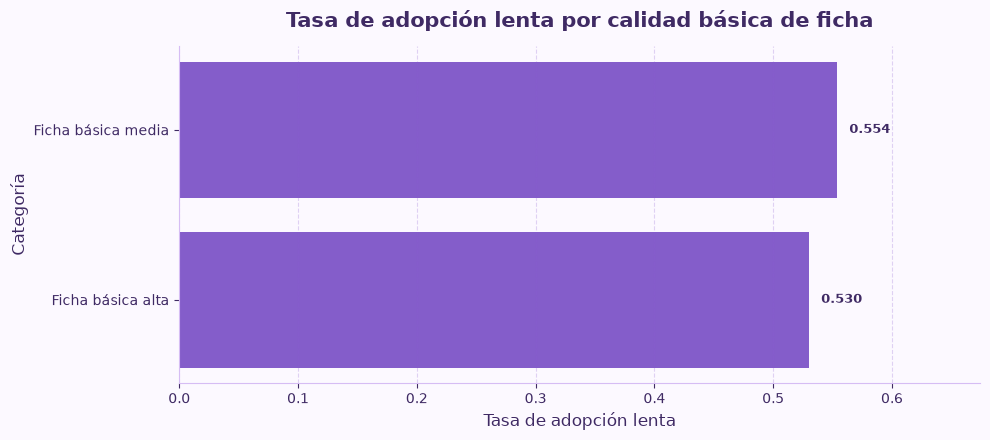

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_calidad_ficha.png


In [51]:
# Gráfico de adopción lenta por calidad básica de ficha

graficar_tasa_adopcion_lenta(
    resumen_variable=resumen_calidad_ficha,
    titulo="Tasa de adopción lenta por calidad básica de ficha",
    nombre_archivo="petfinder_tasa_adopcion_lenta_por_calidad_ficha.png"
)

El análisis de visibilidad muestra que la presentación pública del animal puede aportar información relevante para estudiar la adopción lenta.

La variable más directamente relacionada con el concepto de *Invisible Dogs* es la presencia de fotografías. Los perros sin fotografías presentan una tasa de adopción lenta claramente superior, lo que sugiere que la ausencia de elementos visuales puede estar asociada a una menor visibilidad ante posibles adoptantes.

La longitud de la descripción muestra diferencias más moderadas, por lo que no debe interpretarse de forma aislada. Una descripción más extensa no garantiza necesariamente una adopción más rápida, pero sí puede aportar información útil cuando se combina con otros elementos de ficha, como nombre, fotografías y vídeos.

La variable de calidad básica de ficha resume estos elementos de presentación y permite preparar una señal interpretable para el prototipo final. Su utilidad principal no es sustituir al modelo predictivo, sino ayudar a traducir la información disponible en recomendaciones operativas para mejorar la visibilidad del perro.

## 6. Text mining inicial de las descripciones

PetFinder incorpora una variable textual especialmente relevante: la descripción pública del animal.

Esta información permite estudiar un aspecto que no estaba disponible en Austin Animal Center: la forma en que el perro se presenta ante posibles adoptantes. Por ello, se realiza un primer análisis de text mining orientado a identificar patrones de contenido asociados a adopción lenta.

El objetivo de este bloque no es construir todavía un modelo avanzado de lenguaje, sino extraer variables interpretables relacionadas con:

- riqueza textual de la descripción;
- vocabulario más frecuente;
- términos diferenciales entre adopción lenta y no lenta;
- menciones a personalidad, sociabilidad, salud, urgencia o necesidades especiales.

Este análisis servirá como base para los modelos complementarios con texto y para el diseño posterior del prototipo de aplicación.

In [52]:
# Limpieza y tokenización básica de las descripciones

stopwords_english_basicas = set("""
a about above after again against all am an and any are as at be because been before being below between both but by
can could did do does doing down during each few for from further had has have having he her here hers herself him
himself his how i if in into is it its itself just me more most my myself no nor not now of off on once only or
other our ours ourselves out over own same she should so some such than that the their theirs them themselves then
there these they this those through to too under until up very was we were what when where which while who whom why
will with you your yours yourself yourselves
""".split())

stopwords_petfinder_extra = set("""
dog dogs puppy puppies pup pups pet pets animal animals cat cats kitten kittens
adopt adoption adopted adopter adopters rehome rehomed
please pls kindly thanks thank
find finding looking look
home homes family families forever loving love loved
malaysia malaysian
""".split())

stopwords_texto_petfinder = stopwords_english_basicas.union(stopwords_petfinder_extra)


def normalizar_texto_petfinder(texto):
    texto = "" if pd.isna(texto) else str(texto)
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def tokenizar_texto_petfinder(texto):
    texto_norm = normalizar_texto_petfinder(texto)
    tokens = [
        token
        for token in texto_norm.split()
        if len(token) >= 3 and token not in stopwords_texto_petfinder
    ]
    return tokens


petfinder_dogs_enriched["description_norm"] = (
    petfinder_dogs_enriched["Description"]
    .fillna("")
    .astype(str)
    .apply(normalizar_texto_petfinder)
)

petfinder_dogs_enriched["description_tokens"] = (
    petfinder_dogs_enriched["Description"]
    .fillna("")
    .astype(str)
    .apply(tokenizar_texto_petfinder)
)

petfinder_dogs_enriched["description_tokens_count"] = (
    petfinder_dogs_enriched["description_tokens"]
    .apply(len)
)

petfinder_dogs_enriched["description_unique_tokens"] = (
    petfinder_dogs_enriched["description_tokens"]
    .apply(lambda tokens: len(set(tokens)))
)

petfinder_dogs_enriched["description_lexical_diversity"] = np.where(
    petfinder_dogs_enriched["description_tokens_count"] > 0,
    petfinder_dogs_enriched["description_unique_tokens"] / petfinder_dogs_enriched["description_tokens_count"],
    0
)

petfinder_dogs_enriched["description_lexical_diversity"] = (
    petfinder_dogs_enriched["description_lexical_diversity"]
    .round(4)
)

columnas_texto_muestra = [
    "PetID",
    "Description",
    "description_words",
    "description_tokens_count",
    "description_unique_tokens",
    "description_lexical_diversity",
    "target_adopcion_lenta"
]

print("Variables textuales iniciales creadas:")
display(petfinder_dogs_enriched[columnas_texto_muestra].head(10))

Variables textuales iniciales creadas:


,PetID,Description,description_words,description_tokens_count,description_unique_tokens,description_lexical_diversity,target_adopcion_lenta
2,3422e4906,Their pregnant mother was dumped by her irresp...,69,32,31,0.9688,1
3,5842f1ff5,"Good guard dog, very alert, active, obedience ...",25,15,14,0.9333,0
4,850a43f90,This handsome yet cute boy is up for adoption....,81,28,27,0.9643,0
7,97aa9eeac,Siu Pak just give birth on 13/6/10 to 6puppies...,20,9,9,1.0000,1
10,8b693ca84,"For serious adopter, please do sms or call for...",12,4,4,1.0000,0
12,aaedd873d,Peanut was an abused puppy until he was rescue...,49,13,13,1.0000,0
14,c02be41e6,"Lost Dog Found (Bandar Menjalara, Kepong／Taman...",67,46,32,0.6957,0
15,1fd342e17,We moved out of our apartment to a landed home...,68,24,23,0.9583,1
17,f9d07d5fa,shes active... she can obey wht command that u...,71,40,38,0.9500,1
18,1c92ce464,This cutie dumped by it's owner at the market ...,139,52,47,0.9038,0


In [53]:
# Resumen de riqueza textual por adopción lenta

resumen_riqueza_textual = (
    petfinder_dogs_enriched
    .groupby("target_adopcion_lenta")
    .agg(
        n_perros=("PetID", "size"),
        palabras_originales_media=("description_words", "mean"),
        palabras_originales_mediana=("description_words", "median"),
        tokens_limpios_media=("description_tokens_count", "mean"),
        tokens_limpios_mediana=("description_tokens_count", "median"),
        tokens_unicos_media=("description_unique_tokens", "mean"),
        tokens_unicos_mediana=("description_unique_tokens", "median"),
        diversidad_lexica_media=("description_lexical_diversity", "mean"),
        diversidad_lexica_mediana=("description_lexical_diversity", "median")
    )
    .reset_index()
)

resumen_riqueza_textual["target_label"] = resumen_riqueza_textual["target_adopcion_lenta"].map({
    0: "Adopción no lenta",
    1: "Adopción lenta"
})

columnas_redondear_texto = [
    "palabras_originales_media",
    "palabras_originales_mediana",
    "tokens_limpios_media",
    "tokens_limpios_mediana",
    "tokens_unicos_media",
    "tokens_unicos_mediana",
    "diversidad_lexica_media",
    "diversidad_lexica_mediana"
]

resumen_riqueza_textual[columnas_redondear_texto] = (
    resumen_riqueza_textual[columnas_redondear_texto]
    .round(4)
)

resumen_riqueza_textual_path = petfinder_outputs_path / "resumen_riqueza_textual_petfinder.csv"

resumen_riqueza_textual.to_csv(
    resumen_riqueza_textual_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de riqueza textual por target:")
display(resumen_riqueza_textual)

print("Resumen guardado en:")
print(resumen_riqueza_textual_path)

Resumen de riqueza textual por target:


,target_adopcion_lenta,n_perros,palabras_originales_media,palabras_originales_mediana,tokens_limpios_media,tokens_limpios_mediana,tokens_unicos_media,tokens_unicos_mediana,diversidad_lexica_media,diversidad_lexica_mediana,target_label
0,0,3769,59.5383,42.0,26.126,19.0,23.7097,18.0,0.9026,0.9615,Adopción no lenta
1,1,4363,62.4854,43.0,27.245,19.0,24.5072,18.0,0.9187,0.9643,Adopción lenta


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_riqueza_textual_petfinder.csv


### 6.1. Comparación visual de longitud y riqueza textual

La longitud de las descripciones y su diversidad léxica se comparan entre perros con adopción lenta y no lenta. Estas representaciones tienen un objetivo descriptivo: permiten comprobar si ambos grupos presentan diferencias sistemáticas en la cantidad y variedad del texto, sin atribuirles una interpretación causal.


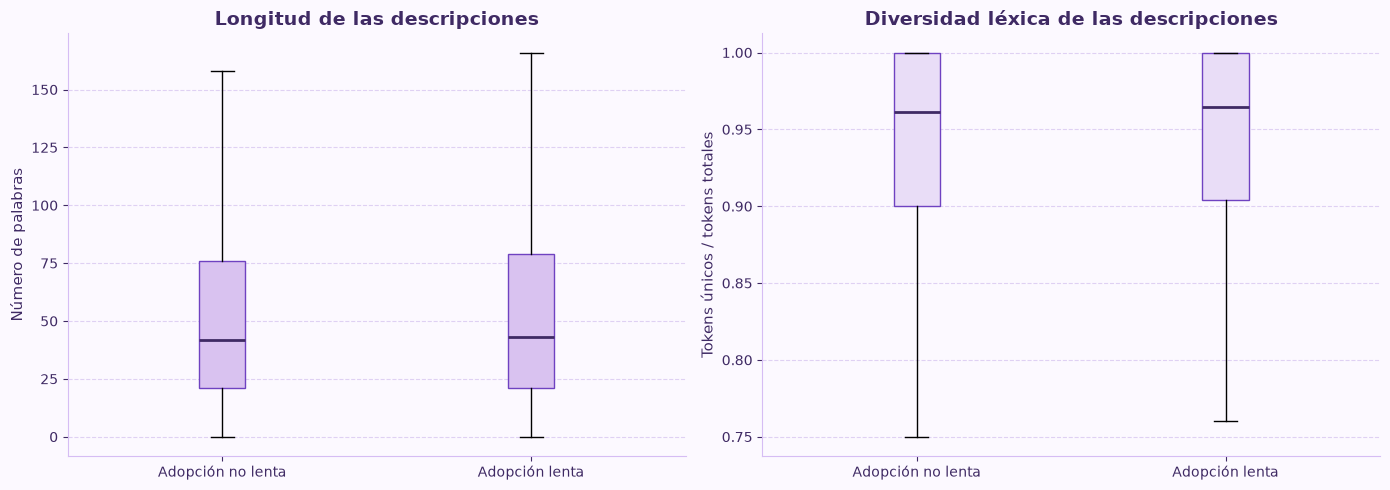

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_longitud_riqueza_textual.png


In [54]:
# Comparación visual de longitud y riqueza textual por target

datos_texto_visual = petfinder_dogs_enriched[
    [
        "target_adopcion_lenta",
        "description_words",
        "description_lexical_diversity"
    ]
].copy()

datos_texto_visual["target_label"] = datos_texto_visual["target_adopcion_lenta"].map({
    0: "Adopción no lenta",
    1: "Adopción lenta"
})

orden_target_texto = ["Adopción no lenta", "Adopción lenta"]

# Compatibilidad entre versiones de Matplotlib: en versiones recientes
# `labels` fue sustituido por `tick_labels` en Axes.boxplot().
import inspect

argumento_etiquetas_boxplot = (
    "tick_labels"
    if "tick_labels" in inspect.signature(plt.Axes.boxplot).parameters
    else "labels"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#FCF9FF")

for ax in axes:
    ax.set_facecolor("#FCF9FF")

valores_longitud = [
    datos_texto_visual.loc[
        datos_texto_visual["target_label"] == etiqueta,
        "description_words"
    ].dropna().values
    for etiqueta in orden_target_texto
]

box_longitud = axes[0].boxplot(
    valores_longitud,
    patch_artist=True,
    showfliers=False,
    **{argumento_etiquetas_boxplot: orden_target_texto}
)

for caja in box_longitud["boxes"]:
    caja.set_facecolor("#D9C2F0")
    caja.set_edgecolor("#6F42C1")

for mediana in box_longitud["medians"]:
    mediana.set_color("#3F2A64")
    mediana.set_linewidth(2)

axes[0].set_title(
    "Longitud de las descripciones",
    fontsize=14,
    fontweight="bold",
    color="#3F2A64"
)
axes[0].set_ylabel("Número de palabras", fontsize=11, color="#3F2A64")
axes[0].tick_params(axis="x", colors="#3F2A64")
axes[0].tick_params(axis="y", colors="#3F2A64")
axes[0].grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

valores_diversidad = [
    datos_texto_visual.loc[
        datos_texto_visual["target_label"] == etiqueta,
        "description_lexical_diversity"
    ].dropna().values
    for etiqueta in orden_target_texto
]

box_diversidad = axes[1].boxplot(
    valores_diversidad,
    patch_artist=True,
    showfliers=False,
    **{argumento_etiquetas_boxplot: orden_target_texto}
)

for caja in box_diversidad["boxes"]:
    caja.set_facecolor("#E9DDF7")
    caja.set_edgecolor("#6F42C1")

for mediana in box_diversidad["medians"]:
    mediana.set_color("#3F2A64")
    mediana.set_linewidth(2)

axes[1].set_title(
    "Diversidad léxica de las descripciones",
    fontsize=14,
    fontweight="bold",
    color="#3F2A64"
)
axes[1].set_ylabel("Tokens únicos / tokens totales", fontsize=11, color="#3F2A64")
axes[1].tick_params(axis="x", colors="#3F2A64")
axes[1].tick_params(axis="y", colors="#3F2A64")
axes[1].grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#D6BDF4")
    ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path_longitud_riqueza_textual = figures_path / "petfinder_longitud_riqueza_textual.png"
fig.savefig(fig_path_longitud_riqueza_textual, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:")
print(fig_path_longitud_riqueza_textual)



In [55]:
# Grupos semánticos de palabras clave en las descripciones

grupos_keywords_texto = {
    "menciona_personalidad_positiva": [
        "friendly", "sweet", "gentle", "playful", "calm", "active", "lovely",
        "affectionate", "loyal", "obedient", "smart", "cute", "adorable",
        "happy", "good", "nice"
    ],
    "menciona_sociabilidad": [
        "children", "kids", "child", "baby", "babies", "people", "human",
        "dogs", "cats", "friendly", "social", "companions", "companion"
    ],
    "menciona_salud_cuidados": [
        "healthy", "health", "vaccinated", "vaccine", "dewormed", "spayed",
        "neutered", "sterilized", "medical", "vet", "clinic", "injured",
        "sick", "disabled", "blind"
    ],
    "menciona_urgencia_rescate": [
        "urgent", "urgently", "rescue", "rescued", "abandoned", "stray",
        "street", "dumped", "neglected", "saved", "foster", "shelter"
    ],
    "menciona_comportamiento_necesidades": [
        "training", "train", "attention", "care", "patient", "shy",
        "timid", "scared", "fearful", "needs", "special", "energy",
        "exercise", "walk", "walking"
    ],
    "menciona_vinculo_emocional": [
        "heart", "hope", "chance", "forever", "family", "home", "love",
        "loving", "companion", "friend", "best", "deserve", "deserves"
    ]
}


def contiene_keywords(texto_norm, lista_keywords):
    if not isinstance(texto_norm, str) or texto_norm.strip() == "":
        return False
    
    patron = r"\b(?:" + "|".join([re.escape(palabra) for palabra in lista_keywords]) + r")\b"
    return bool(re.search(patron, texto_norm))


for nombre_grupo, keywords in grupos_keywords_texto.items():
    petfinder_dogs_enriched[nombre_grupo] = (
        petfinder_dogs_enriched["description_norm"]
        .apply(lambda texto: contiene_keywords(texto, keywords))
    )

variables_keywords_texto = list(grupos_keywords_texto.keys())

print("Variables de grupos semánticos creadas:")
display(
    petfinder_dogs_enriched[
        ["PetID", "target_adopcion_lenta"] + variables_keywords_texto
    ].head(10)
)

Variables de grupos semánticos creadas:


,PetID,target_adopcion_lenta,menciona_personalidad_positiva,menciona_sociabilidad,menciona_salud_cuidados,menciona_urgencia_rescate,menciona_comportamiento_necesidades,menciona_vinculo_emocional
2,3422e4906,1,True,True,True,True,False,True
3,5842f1ff5,0,True,False,False,False,False,False
4,850a43f90,0,True,False,False,True,True,True
7,97aa9eeac,1,False,False,False,False,False,False
10,8b693ca84,0,False,False,False,False,False,False
12,aaedd873d,0,True,True,False,True,True,True
14,c02be41e6,0,False,False,True,False,True,False
15,1fd342e17,1,True,True,False,False,False,True
17,f9d07d5fa,1,True,False,False,False,True,False
18,1c92ce464,0,False,True,False,True,False,True


In [56]:
# Resumen de adopción lenta según presencia de grupos semánticos

resumen_keywords_texto = []

for variable in variables_keywords_texto:
    resumen_variable = (
        petfinder_dogs_enriched
        .groupby(variable)
        .agg(
            n_perros=("PetID", "size"),
            n_adopcion_lenta=("target_adopcion_lenta", "sum"),
            tasa_adopcion_lenta=("target_adopcion_lenta", "mean"),
            adoption_speed_medio=("AdoptionSpeed", "mean")
        )
        .reset_index()
        .rename(columns={variable: "menciona_grupo"})
    )
    
    resumen_variable["grupo_textual"] = variable.replace("menciona_", "").replace("_", " ")
    
    resumen_variable["porcentaje_perros"] = (
        resumen_variable["n_perros"] / resumen_variable["n_perros"].sum() * 100
    )
    
    resumen_keywords_texto.append(resumen_variable)

resumen_keywords_texto = pd.concat(
    resumen_keywords_texto,
    ignore_index=True
)

resumen_keywords_texto["menciona_grupo_label"] = np.where(
    resumen_keywords_texto["menciona_grupo"],
    "Menciona el grupo",
    "No menciona el grupo"
)

resumen_keywords_texto["tasa_adopcion_lenta"] = resumen_keywords_texto["tasa_adopcion_lenta"].round(4)
resumen_keywords_texto["adoption_speed_medio"] = resumen_keywords_texto["adoption_speed_medio"].round(4)
resumen_keywords_texto["porcentaje_perros"] = resumen_keywords_texto["porcentaje_perros"].round(2)

resumen_keywords_texto_path = petfinder_outputs_path / "resumen_keywords_texto_petfinder.csv"

resumen_keywords_texto.to_csv(
    resumen_keywords_texto_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de grupos semánticos de texto:")
display(resumen_keywords_texto)

print("Resumen guardado en:")
print(resumen_keywords_texto_path)

Resumen de grupos semánticos de texto:


,menciona_grupo,n_perros,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,grupo_textual,porcentaje_perros,menciona_grupo_label
0,False,2811,1436,0.5109,2.5510,personalidad positiva,34.57,No menciona el grupo
1,True,5321,2927,0.5501,2.6489,personalidad positiva,65.43,Menciona el grupo
2,False,5125,2624,0.5120,2.5450,sociabilidad,63.02,No menciona el grupo
3,True,3007,1739,0.5783,2.7346,sociabilidad,36.98,Menciona el grupo
4,False,5797,3080,0.5313,2.6036,salud cuidados,71.29,No menciona el grupo
5,True,2335,1283,0.5495,2.6437,salud cuidados,28.71,Menciona el grupo
6,False,5275,2774,0.5259,2.5700,urgencia rescate,64.87,No menciona el grupo
7,True,2857,1589,0.5562,2.6983,urgencia rescate,35.13,Menciona el grupo
8,False,5949,3166,0.5322,2.6065,comportamiento necesidades,73.16,No menciona el grupo
9,True,2183,1197,0.5483,2.6386,comportamiento necesidades,26.84,Menciona el grupo


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_keywords_texto_petfinder.csv


Diferencia de tasa de adopción lenta asociada a menciones textuales:


,grupo_textual,tasa_con_mencion,tasa_sin_mencion,diferencia_tasa,n_con_mencion
0,comportamiento necesidades,0.5483,0.5322,0.0161,2183
1,salud cuidados,0.5495,0.5313,0.0182,2335
2,urgencia rescate,0.5562,0.5259,0.0303,2857
3,personalidad positiva,0.5501,0.5109,0.0392,5321
4,vinculo emocional,0.5592,0.5033,0.0559,4834
5,sociabilidad,0.5783,0.5120,0.0663,3007


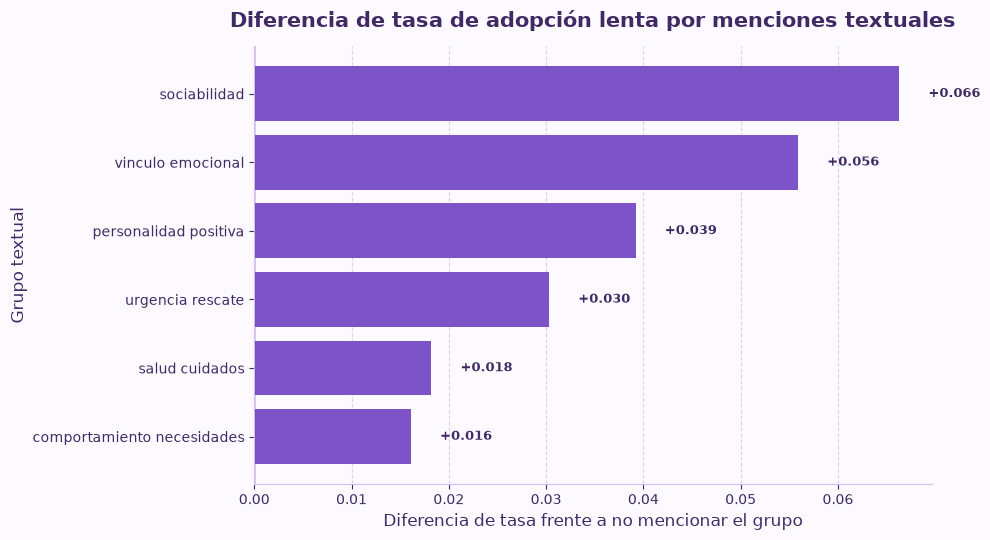

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_diferencia_tasa_adopcion_lenta_menciones_textuales.png


In [57]:
# Diferencia de tasa de adopción lenta cuando se menciona cada grupo semántico

diferencias_keywords_texto = []

for variable in variables_keywords_texto:
    resumen_variable = resumen_keywords_texto.loc[
        resumen_keywords_texto["grupo_textual"] == variable.replace("menciona_", "").replace("_", " ")
    ].copy()
    
    tasa_con = resumen_variable.loc[
        resumen_variable["menciona_grupo"] == True,
        "tasa_adopcion_lenta"
    ]
    
    tasa_sin = resumen_variable.loc[
        resumen_variable["menciona_grupo"] == False,
        "tasa_adopcion_lenta"
    ]
    
    n_con = resumen_variable.loc[
        resumen_variable["menciona_grupo"] == True,
        "n_perros"
    ]
    
    if len(tasa_con) > 0 and len(tasa_sin) > 0:
        diferencias_keywords_texto.append({
            "grupo_textual": variable.replace("menciona_", "").replace("_", " "),
            "tasa_con_mencion": float(tasa_con.iloc[0]),
            "tasa_sin_mencion": float(tasa_sin.iloc[0]),
            "diferencia_tasa": float(tasa_con.iloc[0] - tasa_sin.iloc[0]),
            "n_con_mencion": int(n_con.iloc[0])
        })

diferencias_keywords_texto = pd.DataFrame(diferencias_keywords_texto)

diferencias_keywords_texto["diferencia_tasa"] = diferencias_keywords_texto["diferencia_tasa"].round(4)
diferencias_keywords_texto["tasa_con_mencion"] = diferencias_keywords_texto["tasa_con_mencion"].round(4)
diferencias_keywords_texto["tasa_sin_mencion"] = diferencias_keywords_texto["tasa_sin_mencion"].round(4)

diferencias_keywords_texto = diferencias_keywords_texto.sort_values(
    "diferencia_tasa",
    ascending=True
).reset_index(drop=True)

print("Diferencia de tasa de adopción lenta asociada a menciones textuales:")
display(diferencias_keywords_texto)

fig, ax = plt.subplots(figsize=(10, 5.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colores_barras = [
    "#6F42C1" if valor >= 0 else "#B79CED"
    for valor in diferencias_keywords_texto["diferencia_tasa"]
]

ax.barh(
    diferencias_keywords_texto["grupo_textual"],
    diferencias_keywords_texto["diferencia_tasa"],
    color=colores_barras,
    alpha=0.9
)

for i, row in enumerate(diferencias_keywords_texto.itertuples()):
    ha_texto = "left" if row.diferencia_tasa >= 0 else "right"
    desplazamiento = 0.003 if row.diferencia_tasa >= 0 else -0.003
    
    ax.text(
        row.diferencia_tasa + desplazamiento,
        i,
        f"{row.diferencia_tasa:+.3f}",
        va="center",
        ha=ha_texto,
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.axvline(0, color="#3F2A64", linewidth=1)

ax.set_title(
    "Diferencia de tasa de adopción lenta por menciones textuales",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel(
    "Diferencia de tasa frente a no mencionar el grupo",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Grupo textual",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_diferencia_tasa_adopcion_lenta_menciones_textuales.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [58]:
from collections import Counter

# Frecuencias de palabras por target

def calcular_frecuencia_tokens(df, target_value):
    tokens = (
        df.loc[df["target_adopcion_lenta"] == target_value, "description_tokens"]
        .explode()
        .dropna()
        .astype(str)
    )
    
    contador = Counter(tokens)
    
    frecuencia = pd.DataFrame(
        contador.items(),
        columns=["palabra", "frecuencia"]
    )
    
    frecuencia = frecuencia.sort_values(
        "frecuencia",
        ascending=False
    ).reset_index(drop=True)
    
    return frecuencia


frecuencia_tokens_no_lenta = calcular_frecuencia_tokens(
    petfinder_dogs_enriched,
    target_value=0
)

frecuencia_tokens_lenta = calcular_frecuencia_tokens(
    petfinder_dogs_enriched,
    target_value=1
)

frecuencia_tokens_no_lenta["grupo"] = "Adopción no lenta"
frecuencia_tokens_lenta["grupo"] = "Adopción lenta"

frecuencia_tokens_petfinder = pd.concat(
    [
        frecuencia_tokens_no_lenta,
        frecuencia_tokens_lenta
    ],
    ignore_index=True
)

frecuencia_tokens_petfinder_path = petfinder_outputs_path / "frecuencia_tokens_descripciones_petfinder.csv"

frecuencia_tokens_petfinder.to_csv(
    frecuencia_tokens_petfinder_path,
    index=False,
    encoding="utf-8-sig"
)

print("Top 25 palabras en perros con adopción no lenta:")
display(frecuencia_tokens_no_lenta.head(25))

print("\nTop 25 palabras en perros con adopción lenta:")
display(frecuencia_tokens_lenta.head(25))

print("\nFrecuencias guardadas en:")
print(frecuencia_tokens_petfinder_path)

Top 25 palabras en perros con adopción no lenta:


,palabra,frecuencia,grupo
0,good,1019,Adopción no lenta
1,contact,817,Adopción no lenta
2,call,811,Adopción no lenta
3,interested,773,Adopción no lenta
4,old,770,Adopción no lenta
5,give,759,Adopción no lenta
6,owner,719,Adopción no lenta
7,found,672,Adopción no lenta
8,one,592,Adopción no lenta
9,rescued,581,Adopción no lenta



Top 25 palabras en perros con adopción lenta:


,palabra,frecuencia,grupo
0,good,1396,Adopción lenta
1,give,1032,Adopción lenta
2,contact,998,Adopción lenta
3,call,878,Adopción lenta
4,interested,833,Adopción lenta
5,old,781,Adopción lenta
6,found,770,Adopción lenta
7,friendly,750,Adopción lenta
8,owner,716,Adopción lenta
9,rescued,697,Adopción lenta



Frecuencias guardadas en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\frecuencia_tokens_descripciones_petfinder.csv


In [59]:
# Palabras diferenciales entre adopción lenta y no lenta

frecuencia_no_lenta = frecuencia_tokens_no_lenta.rename(
    columns={"frecuencia": "frecuencia_no_lenta"}
)[["palabra", "frecuencia_no_lenta"]]

frecuencia_lenta = frecuencia_tokens_lenta.rename(
    columns={"frecuencia": "frecuencia_lenta"}
)[["palabra", "frecuencia_lenta"]]

comparacion_frecuencias_texto = frecuencia_no_lenta.merge(
    frecuencia_lenta,
    on="palabra",
    how="outer"
).fillna(0)

comparacion_frecuencias_texto["frecuencia_no_lenta"] = comparacion_frecuencias_texto["frecuencia_no_lenta"].astype(int)
comparacion_frecuencias_texto["frecuencia_lenta"] = comparacion_frecuencias_texto["frecuencia_lenta"].astype(int)

total_tokens_no_lenta = comparacion_frecuencias_texto["frecuencia_no_lenta"].sum()
total_tokens_lenta = comparacion_frecuencias_texto["frecuencia_lenta"].sum()

comparacion_frecuencias_texto["freq_rel_no_lenta"] = (
    (comparacion_frecuencias_texto["frecuencia_no_lenta"] + 1)
    / (total_tokens_no_lenta + len(comparacion_frecuencias_texto))
)

comparacion_frecuencias_texto["freq_rel_lenta"] = (
    (comparacion_frecuencias_texto["frecuencia_lenta"] + 1)
    / (total_tokens_lenta + len(comparacion_frecuencias_texto))
)

comparacion_frecuencias_texto["log_ratio_lenta_vs_no_lenta"] = np.log(
    comparacion_frecuencias_texto["freq_rel_lenta"]
    / comparacion_frecuencias_texto["freq_rel_no_lenta"]
)

comparacion_frecuencias_texto["frecuencia_total"] = (
    comparacion_frecuencias_texto["frecuencia_no_lenta"]
    + comparacion_frecuencias_texto["frecuencia_lenta"]
)

comparacion_frecuencias_texto_filtrada = comparacion_frecuencias_texto.loc[
    comparacion_frecuencias_texto["frecuencia_total"] >= 20
].copy()

comparacion_frecuencias_texto_filtrada = comparacion_frecuencias_texto_filtrada.sort_values(
    "log_ratio_lenta_vs_no_lenta",
    ascending=False
).reset_index(drop=True)

palabras_mas_asociadas_lenta = comparacion_frecuencias_texto_filtrada.head(25).copy()

palabras_mas_asociadas_no_lenta = (
    comparacion_frecuencias_texto_filtrada
    .sort_values("log_ratio_lenta_vs_no_lenta", ascending=True)
    .head(25)
    .copy()
)

comparacion_frecuencias_texto_path = petfinder_outputs_path / "comparacion_frecuencias_texto_petfinder.csv"

comparacion_frecuencias_texto_filtrada.to_csv(
    comparacion_frecuencias_texto_path,
    index=False,
    encoding="utf-8-sig"
)

print("Palabras más asociadas a adopción lenta:")
display(
    palabras_mas_asociadas_lenta[
        [
            "palabra",
            "frecuencia_lenta",
            "frecuencia_no_lenta",
            "frecuencia_total",
            "log_ratio_lenta_vs_no_lenta"
        ]
    ]
    .round(4)
)

print("\nPalabras más asociadas a adopción no lenta:")
display(
    palabras_mas_asociadas_no_lenta[
        [
            "palabra",
            "frecuencia_lenta",
            "frecuencia_no_lenta",
            "frecuencia_total",
            "log_ratio_lenta_vs_no_lenta"
        ]
    ]
    .round(4)
)

Palabras más asociadas a adopción lenta:


,palabra,frecuencia_lenta,frecuencia_no_lenta,frecuencia_total,log_ratio_lenta_vs_no_lenta
0,gabby,33,0,33,3.3567
1,goden,21,0,21,2.9214
2,page,49,5,54,1.9506
3,traffic,51,9,60,1.4790
4,rex,19,3,22,1.4398
5,grandma,29,5,34,1.4398
6,port,23,4,27,1.3990
7,lived,18,3,21,1.3885
8,alternatively,18,3,21,1.3885
9,trust,36,7,43,1.3618



Palabras más asociadas a adopción no lenta:


,palabra,frecuencia_lenta,frecuencia_no_lenta,frecuencia_total,log_ratio_lenta_vs_no_lenta
1617,mickey,2,18,20,-2.0155
1616,chihuahua,5,30,35,-1.8119
1615,condominium,5,27,32,-1.7101
1614,drops,3,17,20,-1.6737
1613,cocker,5,22,27,-1.5134
1612,posting,7,28,35,-1.4575
1611,marley,6,24,30,-1.4426
1610,behalf,5,20,25,-1.4224
1609,spaniel,5,20,25,-1.4224
1608,litters,9,30,39,-1.3010


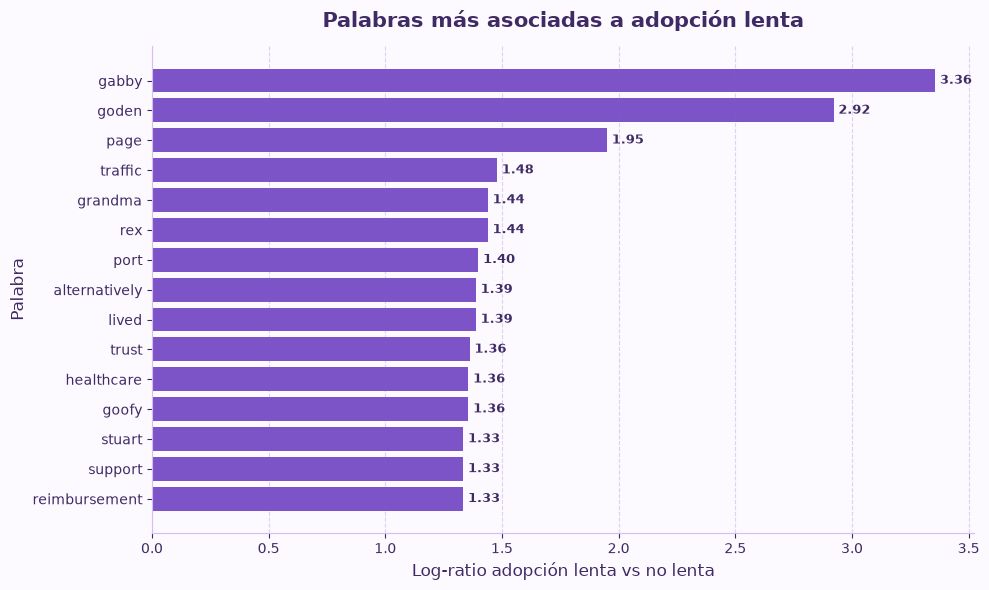

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_palabras_asociadas_adopcion_lenta.png


In [60]:
# Gráfico de palabras más asociadas a adopción lenta

datos_palabras_lenta_plot = (
    palabras_mas_asociadas_lenta
    .head(15)
    .sort_values("log_ratio_lenta_vs_no_lenta", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_palabras_lenta_plot["palabra"],
    datos_palabras_lenta_plot["log_ratio_lenta_vs_no_lenta"],
    color="#6F42C1",
    alpha=0.9
)

for i, row in enumerate(datos_palabras_lenta_plot.itertuples()):
    ax.text(
        row.log_ratio_lenta_vs_no_lenta + 0.02,
        i,
        f"{row.log_ratio_lenta_vs_no_lenta:.2f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Palabras más asociadas a adopción lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel(
    "Log-ratio adopción lenta vs no lenta",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Palabra",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_palabras_asociadas_adopcion_lenta.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [61]:
# Versión depurada de palabras diferenciales para interpretación cualitativa

stopwords_diferenciales_extra = set("""
contact call interested give take like one around well need time must old months male female owner house
page traffic port lived alternatively reimbursement security texting finalised posting calls travel behalf
gabby goden rex lucy bailey mickey snoopy marley muffin stuart makhota kajang seri mka
""".split())

comparacion_frecuencias_texto_depurada = comparacion_frecuencias_texto.copy()

comparacion_frecuencias_texto_depurada = comparacion_frecuencias_texto_depurada.loc[
    ~comparacion_frecuencias_texto_depurada["palabra"].isin(stopwords_diferenciales_extra)
].copy()

comparacion_frecuencias_texto_depurada = comparacion_frecuencias_texto_depurada.loc[
    comparacion_frecuencias_texto_depurada["frecuencia_total"] >= 30
].copy()

comparacion_frecuencias_texto_depurada = comparacion_frecuencias_texto_depurada.sort_values(
    "log_ratio_lenta_vs_no_lenta",
    ascending=False
).reset_index(drop=True)

palabras_lenta_depuradas = comparacion_frecuencias_texto_depurada.head(25).copy()

palabras_no_lenta_depuradas = (
    comparacion_frecuencias_texto_depurada
    .sort_values("log_ratio_lenta_vs_no_lenta", ascending=True)
    .head(25)
    .copy()
)

comparacion_frecuencias_texto_depurada_path = (
    petfinder_outputs_path / "comparacion_frecuencias_texto_depurada_petfinder.csv"
)

comparacion_frecuencias_texto_depurada.to_csv(
    comparacion_frecuencias_texto_depurada_path,
    index=False,
    encoding="utf-8-sig"
)

print("Palabras depuradas más asociadas a adopción lenta:")
display(
    palabras_lenta_depuradas[
        [
            "palabra",
            "frecuencia_lenta",
            "frecuencia_no_lenta",
            "frecuencia_total",
            "log_ratio_lenta_vs_no_lenta"
        ]
    ].round(4)
)

print("\nPalabras depuradas más asociadas a adopción no lenta:")
display(
    palabras_no_lenta_depuradas[
        [
            "palabra",
            "frecuencia_lenta",
            "frecuencia_no_lenta",
            "frecuencia_total",
            "log_ratio_lenta_vs_no_lenta"
        ]
    ].round(4)
)

print("\nComparación depurada guardada en:")
print(comparacion_frecuencias_texto_depurada_path)

Palabras depuradas más asociadas a adopción lenta:


,palabra,frecuencia_lenta,frecuencia_no_lenta,frecuencia_total,log_ratio_lenta_vs_no_lenta
0,grandma,29,5,34,1.4398
1,trust,36,7,43,1.3618
2,support,26,5,31,1.3344
3,rehabilitation,25,5,30,1.2967
4,elderly,28,6,34,1.2517
5,flyover,27,6,33,1.2166
6,signboard,26,6,32,1.1803
7,cages,29,7,36,1.1521
8,doggie,84,22,106,1.1375
9,hind,38,10,48,1.0960



Palabras depuradas más asociadas a adopción no lenta:


,palabra,frecuencia_lenta,frecuencia_no_lenta,frecuencia_total,log_ratio_lenta_vs_no_lenta
1165,chihuahua,5,30,35,-1.8119
1164,condominium,5,27,32,-1.7101
1163,litters,9,30,39,-1.3010
1162,tzu,18,57,75,-1.2856
1161,fluffy,14,40,54,-1.1752
1160,dry,12,34,46,-1.1600
1159,shih,20,50,70,-1.0569
1158,kembangan,9,22,31,-1.0026
1157,poodle,31,72,103,-0.9944
1156,rottweiler,17,38,55,-0.9428



Comparación depurada guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\comparacion_frecuencias_texto_depurada_petfinder.csv


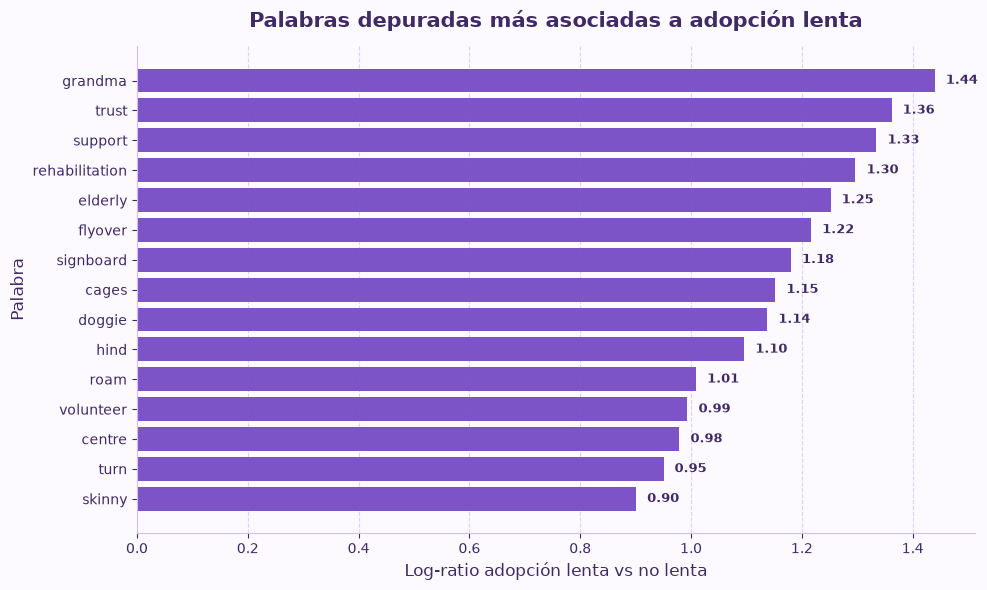

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_palabras_depuradas_asociadas_adopcion_lenta.png


In [62]:
# Gráfico depurado de palabras más asociadas a adopción lenta

datos_palabras_lenta_depuradas_plot = (
    palabras_lenta_depuradas
    .head(15)
    .sort_values("log_ratio_lenta_vs_no_lenta", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_palabras_lenta_depuradas_plot["palabra"],
    datos_palabras_lenta_depuradas_plot["log_ratio_lenta_vs_no_lenta"],
    color="#6F42C1",
    alpha=0.9
)

for i, row in enumerate(datos_palabras_lenta_depuradas_plot.itertuples()):
    ax.text(
        row.log_ratio_lenta_vs_no_lenta + 0.02,
        i,
        f"{row.log_ratio_lenta_vs_no_lenta:.2f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Palabras depuradas más asociadas a adopción lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel(
    "Log-ratio adopción lenta vs no lenta",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Palabra",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_palabras_depuradas_asociadas_adopcion_lenta.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

### 6.2. Nubes de palabras por velocidad de adopción

Como complemento exploratorio, se representan nubes de palabras separadas para adopción lenta y no lenta. El tamaño de cada término refleja su frecuencia dentro de cada grupo tras la limpieza y depuración del vocabulario. Esta figura facilita una lectura visual del contenido, pero no sustituye al análisis de términos diferenciales ni a la interpretación posterior de los coeficientes TF-IDF.


In [63]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Máscara utilizada:
G:\Mi unidad\TFM\invisible-dogs-tfm\assets\masks\shiba_mask.png


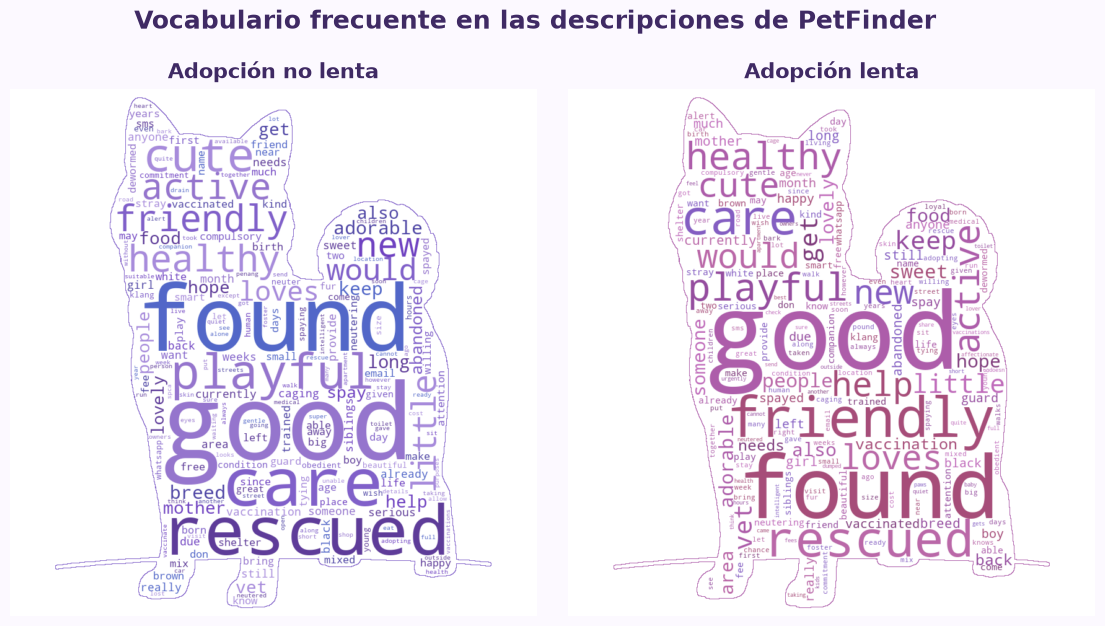

Nube de palabras guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_wordcloud_adopcion_lenta_vs_no_lenta.png


In [144]:
# Nubes de palabras comparativas con silueta de shiba inu

from pathlib import Path
from wordcloud import WordCloud
from PIL import Image, ImageOps
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import random

# Semilla reproducible
SEED_WC = globals().get("RANDOM_STATE", 42)


# ============================================================
# 1. FRECUENCIAS DE PALABRAS
# ============================================================

frecuencias_wc_no_lenta = {
    row.palabra: int(row.frecuencia_no_lenta)
    for row in comparacion_frecuencias_texto_depurada.itertuples()
    if row.frecuencia_no_lenta > 0
}

frecuencias_wc_lenta = {
    row.palabra: int(row.frecuencia_lenta)
    for row in comparacion_frecuencias_texto_depurada.itertuples()
    if row.frecuencia_lenta > 0
}


# ============================================================
# 2. LOCALIZACIÓN DE LA IMAGEN DEL SHIBA
# ============================================================

ruta_mascara_shiba = (
    project_path
    / "assets"
    / "masks"
    / "shiba_mask.png"
)

if not ruta_mascara_shiba.exists():
    raise FileNotFoundError(
        "No se ha encontrado la máscara del shiba.\n"
        f"Ruta esperada: {ruta_mascara_shiba}"
    )

print("Máscara utilizada:")
print(ruta_mascara_shiba.resolve())


# ============================================================
# 3. PREPARACIÓN DE LA SILUETA
# ============================================================

imagen_original = Image.open(
    ruta_mascara_shiba
).convert("L")

gris = np.array(imagen_original)

# Detectamos las líneas del dibujo.
# La ilustración original contiene líneas de color sobre fondo blanco.
lineas = gris < 245


# ============================================================
# 4. ELIMINACIÓN DE LA LÍNEA HORIZONTAL INFERIOR
# ============================================================

# La imagen original incluye una línea de suelo bajo el perro.
# Se detectan estructuras horizontales largas para eliminarla
# sin afectar al contorno principal del animal.

ancho_imagen = lineas.shape[1]

longitud_horizontal = max(
    50,
    int(ancho_imagen * 0.18)
)

estructura_horizontal = np.ones(
    (1, longitud_horizontal),
    dtype=bool
)

lineas_horizontales_largas = ndimage.binary_opening(
    lineas,
    structure=estructura_horizontal
)

# Engrosamos ligeramente la detección para eliminar
# todo el grosor de la línea horizontal.
lineas_horizontales_largas = ndimage.binary_dilation(
    lineas_horizontales_largas,
    structure=np.ones((7, 1), dtype=bool)
)

# Solo se eliminan líneas horizontales largas situadas
# en la parte inferior de la imagen.
zona_inferior = np.zeros_like(
    lineas,
    dtype=bool
)

inicio_zona_inferior = int(
    lineas.shape[0] * 0.60
)

zona_inferior[
    inicio_zona_inferior:,
    :
] = True

linea_suelo = (
    lineas_horizontales_largas
    & zona_inferior
)

lineas_sin_suelo = (
    lineas
    & ~linea_suelo
)


# ============================================================
# 5. CIERRE DEL CONTORNO
# ============================================================

# Se engrosan ligeramente las líneas para cerrar pequeñas
# discontinuidades de la ilustración.
contorno = ndimage.binary_dilation(
    lineas_sin_suelo,
    structure=np.ones((3, 3), dtype=bool),
    iterations=1
)

# Cierre de pequeños huecos del borde.
contorno = ndimage.binary_closing(
    contorno,
    structure=np.ones((5, 5), dtype=bool),
    iterations=2
)


# ============================================================
# 6. RELLENO DE LA SILUETA
# ============================================================

silueta_rellena = ndimage.binary_fill_holes(
    contorno
)


# ============================================================
# 7. CONSERVAR ÚNICAMENTE EL PERRO
# ============================================================

# Si quedan pequeños elementos aislados, se conserva
# únicamente el componente conectado principal.
etiquetas, numero_componentes = ndimage.label(
    silueta_rellena
)

if numero_componentes > 0:

    tamanos_componentes = ndimage.sum(
        silueta_rellena,
        etiquetas,
        range(1, numero_componentes + 1)
    )

    componente_principal = (
        np.argmax(tamanos_componentes) + 1
    )

    silueta_rellena = (
        etiquetas == componente_principal
    )


# ============================================================
# 8. RECORTE DEL ESPACIO SOBRANTE
# ============================================================

filas, columnas = np.where(
    silueta_rellena
)

if len(filas) == 0 or len(columnas) == 0:
    raise ValueError(
        "No se ha podido detectar correctamente "
        "la silueta del shiba."
    )

margen = 20

y_min = max(
    filas.min() - margen,
    0
)

y_max = min(
    filas.max() + margen + 1,
    silueta_rellena.shape[0]
)

x_min = max(
    columnas.min() - margen,
    0
)

x_max = min(
    columnas.max() + margen + 1,
    silueta_rellena.shape[1]
)

silueta_recortada = silueta_rellena[
    y_min:y_max,
    x_min:x_max
]


# ============================================================
# 9. CREACIÓN DE LA MÁSCARA SIN DEFORMAR EL SHIBA
# ============================================================

# En WordCloud:
# 0   = zona en la que pueden aparecer palabras
# 255 = zona excluida

mascara_base = np.where(
    silueta_recortada,
    0,
    255
).astype(np.uint8)

mascara_imagen = Image.fromarray(
    mascara_base
)

# Lienzo cuadrado para mantener las proporciones
# originales del perro y evitar deformaciones.
tamano_lienzo = 850

mascara_redimensionada = ImageOps.contain(
    mascara_imagen,
    (tamano_lienzo, tamano_lienzo),
    method=Image.Resampling.LANCZOS
)

lienzo = Image.new(
    "L",
    (tamano_lienzo, tamano_lienzo),
    255
)

x_centrado = (
    tamano_lienzo
    - mascara_redimensionada.width
) // 2

y_centrado = (
    tamano_lienzo
    - mascara_redimensionada.height
) // 2

lienzo.paste(
    mascara_redimensionada,
    (x_centrado, y_centrado)
)

mascara_perro_wc = np.array(
    lienzo
)

# Eliminamos los niveles de gris introducidos
# durante el redimensionado.
mascara_perro_wc = np.where(
    mascara_perro_wc < 200,
    0,
    255
).astype(np.uint8)


# ============================================================
# 10. PALETAS DE COLOR
# ============================================================

# Se mantiene la estética morada general del notebook,
# utilizando algo más de variedad para facilitar la lectura.

paleta_wc_no_lenta = [
    "#4F46A5",
    "#5E3C99",
    "#6F42C1",
    "#8060C9",
    "#9575CD",
    "#A78BDB",
    "#5267C8"
]

paleta_wc_lenta = [
    "#803D7D",
    "#954D9F",
    "#A64D79",
    "#AD5DAA",
    "#BA68A8",
    "#C06CBB",
    "#845EC2"
]


def crear_color_func(paleta, seed):
    rng = random.Random(seed)

    def color_func(*args, **kwargs):
        return rng.choice(paleta)

    return color_func


# ============================================================
# 11. WORD CLOUD: ADOPCIÓN NO LENTA
# ============================================================

wordcloud_no_lenta = WordCloud(
    width=tamano_lienzo,
    height=tamano_lienzo,
    background_color="white",
    mask=mascara_perro_wc,
    contour_width=1,
    contour_color="#8060C9",
    max_words=200,
    prefer_horizontal=0.88,
    collocations=False,
    margin=2,
    min_font_size=5,
    relative_scaling=0.40,
    random_state=SEED_WC
).generate_from_frequencies(
    frecuencias_wc_no_lenta
)

wordcloud_no_lenta.recolor(
    color_func=crear_color_func(
        paleta_wc_no_lenta,
        seed=SEED_WC + 11
    )
)


# ============================================================
# 12. WORD CLOUD: ADOPCIÓN LENTA
# ============================================================

wordcloud_lenta = WordCloud(
    width=tamano_lienzo,
    height=tamano_lienzo,
    background_color="white",
    mask=mascara_perro_wc,
    contour_width=1,
    contour_color="#AD5DAA",
    max_words=200,
    prefer_horizontal=0.88,
    collocations=False,
    margin=2,
    min_font_size=5,
    relative_scaling=0.40,
    random_state=SEED_WC + 7
).generate_from_frequencies(
    frecuencias_wc_lenta
)

wordcloud_lenta.recolor(
    color_func=crear_color_func(
        paleta_wc_lenta,
        seed=SEED_WC + 23
    )
)


# ============================================================
# 13. VISUALIZACIÓN
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

fig.patch.set_facecolor(
    "#FCF9FF"
)

for ax in axes:
    ax.set_facecolor(
        "#FCF9FF"
    )


# Adopción no lenta
axes[0].imshow(
    wordcloud_no_lenta,
    interpolation="bilinear"
)

axes[0].set_title(
    "Adopción no lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=8
)

axes[0].axis(
    "off"
)


# Adopción lenta
axes[1].imshow(
    wordcloud_lenta,
    interpolation="bilinear"
)

axes[1].set_title(
    "Adopción lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=8
)

axes[1].axis(
    "off"
)


# Título general
fig.suptitle(
    "Vocabulario frecuente en las descripciones de PetFinder",
    fontsize=18,
    fontweight="bold",
    color="#3F2A64",
    y=0.985
)

# Espacio entre el título principal
# y los títulos de cada grupo.
fig.subplots_adjust(
    top=0.88,
    wspace=0.06
)


# ============================================================
# 14. GUARDADO DE LA FIGURA
# ============================================================

fig_path_wordcloud_texto = (
    figures_path
    / "petfinder_wordcloud_adopcion_lenta_vs_no_lenta.png"
)

fig.savefig(
    fig_path_wordcloud_texto,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Nube de palabras guardada en:")
print(fig_path_wordcloud_texto)

El análisis textual inicial permite complementar el estudio estructurado de PetFinder con información procedente de las descripciones públicas de los perros.

Las variables de riqueza textual muestran diferencias moderadas entre perros con adopción lenta y no lenta. La comparación gráfica de longitud y diversidad léxica permite visualizar estas diferencias sin interpretar la cantidad de texto como un factor aislado.

El análisis de grupos semánticos muestra que las menciones relacionadas con sociabilidad, vínculo emocional, personalidad positiva, urgencia o necesidades aparecen asociadas a una mayor tasa de adopción lenta. Esta relación debe interpretarse con cautela: no implica que mencionar estos aspectos reduzca la adopción, sino que probablemente las descripciones de casos más complejos o con mayor necesidad de difusión incluyen más información emocional, social o contextual.

El análisis de palabras diferenciales aporta una primera lectura del vocabulario asociado a cada grupo. Sin embargo, algunas palabras destacadas corresponden a nombres propios, localizaciones o términos poco interpretables. Por ello, se utiliza una versión depurada del vocabulario y se complementa con nubes de palabras separadas por clase. Estas nubes tienen un carácter exploratorio y se interpretan junto con las frecuencias diferenciales y, posteriormente, con los coeficientes TF-IDF del modelo.

En conjunto, el bloque de text mining refuerza la idea de que la descripción pública forma parte de la visibilidad del animal. Estas variables se conservarán para la modelización complementaria posterior y para el diseño del prototipo final de la aplicación.

## 7. Enriquecimiento con sentiment y metadata

PetFinder incluye archivos complementarios generados a partir de las descripciones y las imágenes de los animales.

En este bloque se revisan los archivos de sentimiento asociados a las descripciones. Estos archivos permiten incorporar variables adicionales relacionadas con el tono del texto, como la polaridad y la magnitud del sentimiento.

El objetivo es evaluar si estas señales textuales avanzadas aportan información adicional sobre la adopción lenta. Al igual que en los bloques anteriores, este análisis se interpreta como complementario y no causal.

In [65]:
# Ruta local alternativa para acelerar la lectura de archivos sentiment

petfinder_local_path = Path(
    r"C:\Users\isaa-\OneDrive\Escritorio\Master Data Science\0. TEMARIO\_TFM\Invisible Dogs\3. petfinder-adoption-prediction\petfinder-adoption-prediction"
)

train_sentiment_path_local = petfinder_local_path / "train_sentiment"

if train_sentiment_path_local.exists():
    train_sentiment_path = train_sentiment_path_local

print("Ruta usada para train_sentiment:")
print(train_sentiment_path)

print("\n¿Existe la carpeta de sentiment?")
print(train_sentiment_path.exists())

Ruta usada para train_sentiment:
C:\Users\isaa-\OneDrive\Escritorio\Master Data Science\0. TEMARIO\_TFM\Invisible Dogs\3. petfinder-adoption-prediction\petfinder-adoption-prediction\train_sentiment

¿Existe la carpeta de sentiment?
True


In [66]:
# Lectura optimizada de archivos de sentiment de PetFinder con caché

sentiment_cache_path = petfinder_outputs_path / "petfinder_sentiment_train_dogs.csv"

def leer_sentiment_petfinder_filtrado_cache(sentiment_folder, pet_ids_objetivo, cache_path):
    if cache_path.exists():
        print("Cargando sentiment desde caché:")
        print(cache_path)
        sentiment_df = pd.read_csv(cache_path)
        return sentiment_df
    
    registros_sentiment = []
    
    if sentiment_folder is None or not sentiment_folder.exists():
        print("No se ha encontrado carpeta de sentiment.")
        return pd.DataFrame()
    
    pet_ids_objetivo = set(pet_ids_objetivo)
    
    print("Número de PetID objetivo:")
    print(len(pet_ids_objetivo))
    
    archivos_json = [
        sentiment_folder / f"{pet_id}.json"
        for pet_id in pet_ids_objetivo
    ]
    
    archivos_existentes = [
        archivo
        for archivo in archivos_json
        if archivo.exists()
    ]
    
    print("Número de archivos sentiment encontrados para perros:")
    print(len(archivos_existentes))
    
    for i, archivo in enumerate(archivos_existentes, start=1):
        pet_id = archivo.stem
        
        try:
            with open(archivo, "r", encoding="utf-8") as f:
                contenido = json.load(f)
            
            document_sentiment = contenido.get("documentSentiment", {})
            
            registros_sentiment.append({
                "PetID": pet_id,
                "sentiment_score": document_sentiment.get("score", np.nan),
                "sentiment_magnitude": document_sentiment.get("magnitude", np.nan),
                "sentiment_language": contenido.get("language", np.nan),
                "n_sentences_sentiment": len(contenido.get("sentences", [])),
                "n_entities_sentiment": len(contenido.get("entities", []))
            })
        
        except Exception:
            registros_sentiment.append({
                "PetID": pet_id,
                "sentiment_score": np.nan,
                "sentiment_magnitude": np.nan,
                "sentiment_language": np.nan,
                "n_sentences_sentiment": np.nan,
                "n_entities_sentiment": np.nan
            })
        
        if i % 1000 == 0:
            print(f"Archivos procesados: {i}/{len(archivos_existentes)}")
    
    sentiment_df = pd.DataFrame(registros_sentiment)
    
    sentiment_df.to_csv(
        cache_path,
        index=False,
        encoding="utf-8-sig"
    )
    
    print("Caché de sentiment guardada en:")
    print(cache_path)
    
    return sentiment_df


petfinder_sentiment_train = leer_sentiment_petfinder_filtrado_cache(
    sentiment_folder=train_sentiment_path,
    pet_ids_objetivo=petfinder_dogs_enriched["PetID"].unique(),
    cache_path=sentiment_cache_path
)

print("\nDimensiones del dataset de sentiment:")
print(petfinder_sentiment_train.shape)

print("\nPrimeras filas de sentiment:")
display(petfinder_sentiment_train.head())

Cargando sentiment desde caché:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\petfinder_sentiment_train_dogs.csv

Dimensiones del dataset de sentiment:
(8086, 6)

Primeras filas de sentiment:


,PetID,sentiment_score,sentiment_magnitude,sentiment_language,n_sentences_sentiment,n_entities_sentiment
0,bf8aa8f96,0.3,4.3,en,9,20
1,e7176bba4,0.1,2.7,en,7,10
2,e239373ff,0.7,1.5,en,2,2
3,44594e996,0.0,1.1,en,3,4
4,cbdeed3f9,0.1,0.1,en,1,2


In [67]:
# Unión de sentiment con el dataset enriquecido de perros

columnas_sentiment_a_eliminar = [
    "sentiment_score",
    "sentiment_magnitude",
    "sentiment_language",
    "n_sentences_sentiment",
    "n_entities_sentiment",
    "sentiment_score_group",
    "sentiment_magnitude_group"
]

columnas_existentes_sentiment = [
    columna
    for columna in columnas_sentiment_a_eliminar
    if columna in petfinder_dogs_enriched.columns
]

if len(columnas_existentes_sentiment) > 0:
    petfinder_dogs_enriched = petfinder_dogs_enriched.drop(
        columns=columnas_existentes_sentiment
    )

petfinder_dogs_enriched = petfinder_dogs_enriched.merge(
    petfinder_sentiment_train,
    on="PetID",
    how="left"
)

variables_sentiment = [
    "sentiment_score",
    "sentiment_magnitude",
    "n_sentences_sentiment",
    "n_entities_sentiment"
]

for variable in variables_sentiment:
    petfinder_dogs_enriched[variable] = petfinder_dogs_enriched[variable].fillna(0)

petfinder_dogs_enriched["sentiment_score_group"] = pd.cut(
    petfinder_dogs_enriched["sentiment_score"],
    bins=[-1.01, -0.2, 0.2, 1.01],
    labels=[
        "Sentimiento negativo",
        "Sentimiento neutro",
        "Sentimiento positivo"
    ]
)

petfinder_dogs_enriched["sentiment_magnitude_group"] = pd.cut(
    petfinder_dogs_enriched["sentiment_magnitude"],
    bins=[-0.01, 1, 3, 100],
    labels=[
        "Magnitud baja",
        "Magnitud media",
        "Magnitud alta"
    ]
)

print("Dataset enriquecido con sentiment:")
print(petfinder_dogs_enriched.shape)

print("\nResumen de nulos en variables sentiment:")
display(
    petfinder_dogs_enriched[variables_sentiment]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_nulos"})
)

print("\nPrimeras variables sentiment:")
display(
    petfinder_dogs_enriched[
        [
            "PetID",
            "target_adopcion_lenta",
            "sentiment_score",
            "sentiment_magnitude",
            "n_sentences_sentiment",
            "n_entities_sentiment",
            "sentiment_score_group",
            "sentiment_magnitude_group"
        ]
    ].head(10)
)

Dataset enriquecido con sentiment:
(8132, 82)

Resumen de nulos en variables sentiment:


,variable,n_nulos
0,sentiment_score,0
1,sentiment_magnitude,0
2,n_sentences_sentiment,0
3,n_entities_sentiment,0



Primeras variables sentiment:


,PetID,target_adopcion_lenta,sentiment_score,sentiment_magnitude,n_sentences_sentiment,n_entities_sentiment,sentiment_score_group,sentiment_magnitude_group
0,3422e4906,1,0.2,3.7,7.0,13.0,Sentimiento neutro,Magnitud alta
1,5842f1ff5,0,0.9,0.9,1.0,6.0,Sentimiento positivo,Magnitud baja
2,850a43f90,0,0.6,3.7,6.0,13.0,Sentimiento positivo,Magnitud alta
3,97aa9eeac,1,0.1,0.9,3.0,3.0,Sentimiento neutro,Magnitud baja
4,8b693ca84,0,0.8,0.8,1.0,3.0,Sentimiento positivo,Magnitud baja
5,aaedd873d,0,0.4,2.9,6.0,6.0,Sentimiento positivo,Magnitud media
6,c02be41e6,0,0.1,3.4,10.0,22.0,Sentimiento neutro,Magnitud alta
7,1fd342e17,1,0.6,1.8,3.0,15.0,Sentimiento positivo,Magnitud media
8,f9d07d5fa,1,0.3,1.0,3.0,15.0,Sentimiento positivo,Magnitud baja
9,1c92ce464,0,0.1,1.8,4.0,23.0,Sentimiento neutro,Magnitud media


In [68]:
# Resumen de variables de sentiment por adopción lenta

resumen_sentiment_por_target = (
    petfinder_dogs_enriched
    .groupby("target_adopcion_lenta")
    .agg(
        n_perros=("PetID", "size"),
        sentiment_score_mean=("sentiment_score", "mean"),
        sentiment_score_median=("sentiment_score", "median"),
        sentiment_magnitude_mean=("sentiment_magnitude", "mean"),
        sentiment_magnitude_median=("sentiment_magnitude", "median"),
        n_sentences_mean=("n_sentences_sentiment", "mean"),
        n_sentences_median=("n_sentences_sentiment", "median"),
        n_entities_mean=("n_entities_sentiment", "mean"),
        n_entities_median=("n_entities_sentiment", "median")
    )
    .reset_index()
)

resumen_sentiment_por_target["target_label"] = resumen_sentiment_por_target["target_adopcion_lenta"].map({
    0: "Adopción no lenta",
    1: "Adopción lenta"
})

columnas_redondear_sentiment = [
    "sentiment_score_mean",
    "sentiment_score_median",
    "sentiment_magnitude_mean",
    "sentiment_magnitude_median",
    "n_sentences_mean",
    "n_sentences_median",
    "n_entities_mean",
    "n_entities_median"
]

resumen_sentiment_por_target[columnas_redondear_sentiment] = (
    resumen_sentiment_por_target[columnas_redondear_sentiment]
    .round(4)
)

resumen_sentiment_por_target_path = petfinder_outputs_path / "resumen_sentiment_por_target_petfinder.csv"

resumen_sentiment_por_target.to_csv(
    resumen_sentiment_por_target_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de sentiment por target:")
display(resumen_sentiment_por_target)

print("Resumen guardado en:")
print(resumen_sentiment_por_target_path)

Resumen de sentiment por target:


,target_adopcion_lenta,n_perros,sentiment_score_mean,sentiment_score_median,sentiment_magnitude_mean,sentiment_magnitude_median,n_sentences_mean,n_sentences_median,n_entities_mean,n_entities_median,target_label
0,0,3769,0.2519,0.2,1.9802,1.6,4.8384,4.0,10.6877,8.0,Adopción no lenta
1,1,4363,0.2787,0.3,2.0921,1.6,4.9356,4.0,11.0287,8.0,Adopción lenta


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_sentiment_por_target_petfinder.csv


In [69]:
# Resumen de adopción lenta por grupos de sentiment

resumen_sentiment_score_group = resumen_adopcion_lenta_por_categoria(
    df=petfinder_dogs_enriched,
    variable="sentiment_score_group",
    nombre_variable="Grupo de sentimiento",
    min_n=20
)

resumen_sentiment_magnitude_group = resumen_adopcion_lenta_por_categoria(
    df=petfinder_dogs_enriched,
    variable="sentiment_magnitude_group",
    nombre_variable="Magnitud del sentimiento",
    min_n=20
)

resumen_sentiment_group = pd.concat(
    [
        resumen_sentiment_score_group,
        resumen_sentiment_magnitude_group
    ],
    ignore_index=True
)

resumen_sentiment_group_path = petfinder_outputs_path / "resumen_sentiment_groups_petfinder.csv"

resumen_sentiment_group.to_csv(
    resumen_sentiment_group_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen por grupos de sentimiento:")
display(resumen_sentiment_group)

print("Resumen guardado en:")
print(resumen_sentiment_group_path)

Resumen por grupos de sentimiento:


,variable,categoria,n_perros,porcentaje_perros,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,adoption_speed_mediano
0,Grupo de sentimiento,Sentimiento negativo,234,2.88,132,0.5641,2.7735,3.0
1,Grupo de sentimiento,Sentimiento positivo,3940,48.45,2212,0.5614,2.6769,3.0
2,Grupo de sentimiento,Sentimiento neutro,3958,48.67,2019,0.5101,2.5442,3.0
3,Magnitud del sentimiento,Magnitud alta,1677,20.62,945,0.5635,2.6655,3.0
4,Magnitud del sentimiento,Magnitud media,3640,44.76,1940,0.5330,2.6082,3.0
5,Magnitud del sentimiento,Magnitud baja,2815,34.62,1478,0.5250,2.5940,3.0


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_sentiment_groups_petfinder.csv


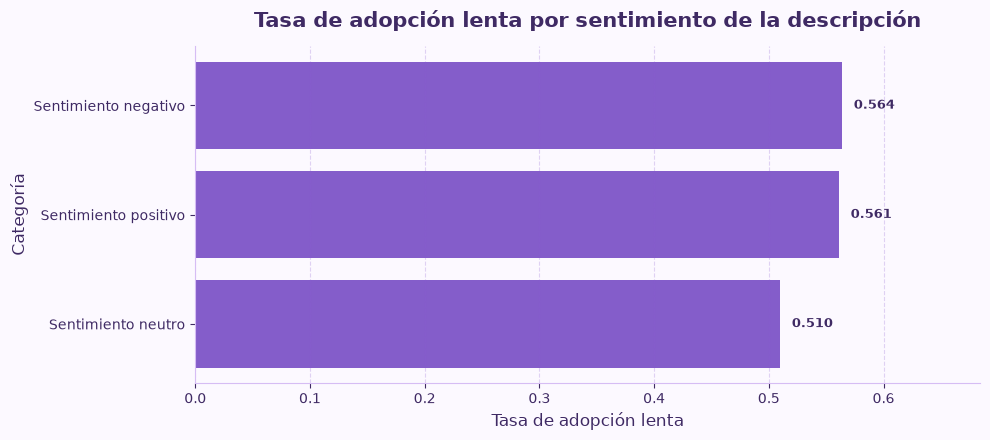

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_sentimiento.png


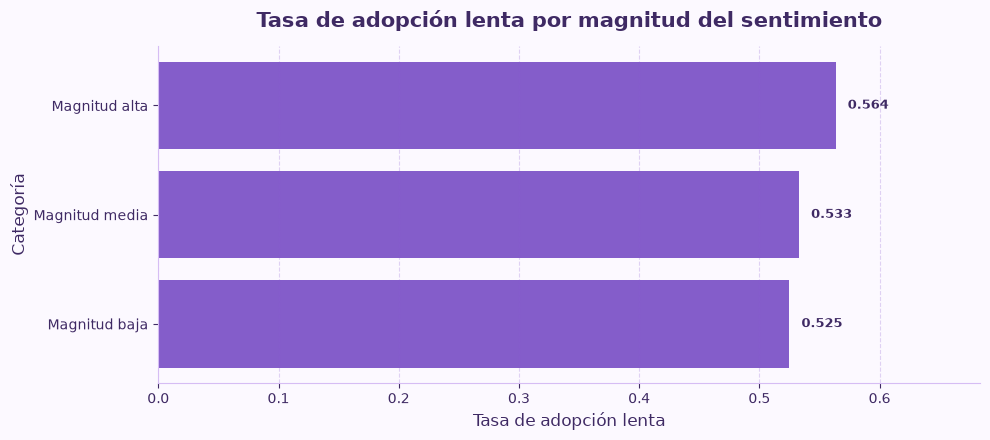

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_magnitud_sentimiento.png


In [70]:
# Gráficos de adopción lenta por sentiment

graficar_tasa_adopcion_lenta(
    resumen_variable=resumen_sentiment_score_group,
    titulo="Tasa de adopción lenta por sentimiento de la descripción",
    nombre_archivo="petfinder_tasa_adopcion_lenta_por_sentimiento.png"
)

graficar_tasa_adopcion_lenta(
    resumen_variable=resumen_sentiment_magnitude_group,
    titulo="Tasa de adopción lenta por magnitud del sentimiento",
    nombre_archivo="petfinder_tasa_adopcion_lenta_por_magnitud_sentimiento.png"
)

El análisis de sentimiento aporta una señal complementaria sobre el tono de las descripciones públicas de los perros.

Los resultados muestran que las descripciones clasificadas como positivas o negativas presentan tasas de adopción lenta superiores a las descripciones neutras. Además, las descripciones con mayor magnitud de sentimiento también muestran una tasa de adopción lenta más elevada.

Este patrón debe interpretarse con cautela. No implica que una descripción positiva o emocional reduzca la probabilidad de adopción, sino que los casos más complejos o con mayor necesidad de difusión pueden incluir textos más elaborados, más emocionales o con más contexto.

Por tanto, las variables de sentimiento se consideran señales complementarias de presentación textual. Su valor principal en este proyecto no es causal, sino operativo: pueden ayudar a caracterizar la ficha pública del perro y alimentar el futuro módulo de análisis textual del prototipo.

## 8. Enriquecimiento con metadata de imágenes

Además de las descripciones textuales, PetFinder incorpora metadatos asociados a las imágenes de los animales.

Estos archivos permiten extraer información visual agregada sin entrenar todavía una red neuronal sobre las imágenes. En este notebook se utilizan como una primera aproximación al análisis visual, mientras que el entrenamiento con imágenes se reserva para el notebook posterior de redes neuronales.

El objetivo de este bloque es estudiar si variables como el número de imágenes con metadatos, la luminosidad media o las etiquetas visuales detectadas muestran diferencias entre perros con adopción lenta y no lenta.

In [71]:
# Ruta local alternativa para acelerar la lectura de metadata

petfinder_local_path = Path(
    r"C:\Users\isaa-\OneDrive\Escritorio\Master Data Science\0. TEMARIO\_TFM\Invisible Dogs\3. petfinder-adoption-prediction\petfinder-adoption-prediction"
)

train_metadata_path_local = petfinder_local_path / "train_metadata"

if train_metadata_path_local.exists():
    train_metadata_path = train_metadata_path_local

print("Ruta usada para train_metadata:")
print(train_metadata_path)

print("\n¿Existe la carpeta de metadata?")
print(train_metadata_path.exists())

Ruta usada para train_metadata:
C:\Users\isaa-\OneDrive\Escritorio\Master Data Science\0. TEMARIO\_TFM\Invisible Dogs\3. petfinder-adoption-prediction\petfinder-adoption-prediction\train_metadata

¿Existe la carpeta de metadata?
True


In [72]:
# Lectura de metadata de imágenes de PetFinder con caché

metadata_cache_path = petfinder_outputs_path / "petfinder_metadata_train_dogs.csv"
image_labels_cache_path = petfinder_outputs_path / "petfinder_image_labels_train_dogs.csv"

def calcular_brightness_color(color_dict):
    if not isinstance(color_dict, dict):
        return np.nan
    
    red = color_dict.get("red", 0)
    green = color_dict.get("green", 0)
    blue = color_dict.get("blue", 0)
    
    return 0.299 * red + 0.587 * green + 0.114 * blue


def leer_metadata_petfinder_filtrado_cache(metadata_folder, df_dogs, cache_path, labels_cache_path):
    if cache_path.exists() and labels_cache_path.exists():
        print("Cargando metadata desde caché:")
        print(cache_path)
        metadata_df = pd.read_csv(cache_path)
        
        print("\nCargando etiquetas visuales desde caché:")
        print(labels_cache_path)
        labels_df = pd.read_csv(labels_cache_path)
        
        return metadata_df, labels_df
    
    registros_metadata = []
    registros_labels = []
    
    if metadata_folder is None or not metadata_folder.exists():
        print("No se ha encontrado carpeta de metadata.")
        return pd.DataFrame(), pd.DataFrame()
    
    df_iter = df_dogs[["PetID", "PhotoAmt"]].copy()
    df_iter["PhotoAmt"] = df_iter["PhotoAmt"].fillna(0).astype(int)
    
    total_imagenes_esperadas = int(df_iter["PhotoAmt"].sum())
    
    print("Número de perros objetivo:")
    print(df_iter["PetID"].nunique())
    
    print("\nNúmero de imágenes esperadas según PhotoAmt:")
    print(total_imagenes_esperadas)
    
    contador_archivos = 0
    
    for fila in df_iter.itertuples(index=False):
        pet_id = fila.PetID
        n_fotos = fila.PhotoAmt
        
        for image_number in range(1, n_fotos + 1):
            archivo = metadata_folder / f"{pet_id}-{image_number}.json"
            
            if not archivo.exists():
                continue
            
            contador_archivos += 1
            
            try:
                with open(archivo, "r", encoding="utf-8") as f:
                    contenido = json.load(f)
                
                labels = contenido.get("labelAnnotations", [])
                n_labels = len(labels)
                
                scores_labels = [
                    label.get("score", np.nan)
                    for label in labels
                    if isinstance(label, dict)
                ]
                
                descriptions_labels = [
                    str(label.get("description", "")).lower()
                    for label in labels
                    if isinstance(label, dict)
                ]
                
                contiene_dog_label = any(
                    ("dog" in descripcion) or ("puppy" in descripcion)
                    for descripcion in descriptions_labels
                )
                
                contiene_person_label = any(
                    ("person" in descripcion) or ("human" in descripcion) or ("people" in descripcion)
                    for descripcion in descriptions_labels
                )
                
                colores = (
                    contenido
                    .get("imagePropertiesAnnotation", {})
                    .get("dominantColors", {})
                    .get("colors", [])
                )
                
                if len(colores) > 0:
                    color_principal = colores[0].get("color", {})
                    color_score = colores[0].get("score", np.nan)
                    color_pixel_fraction = colores[0].get("pixelFraction", np.nan)
                    brightness = calcular_brightness_color(color_principal)
                else:
                    color_score = np.nan
                    color_pixel_fraction = np.nan
                    brightness = np.nan
                
                registros_metadata.append({
                    "PetID": pet_id,
                    "image_number": image_number,
                    "n_label_annotations": n_labels,
                    "label_score_mean": np.nanmean(scores_labels) if len(scores_labels) > 0 else np.nan,
                    "contains_dog_label": contiene_dog_label,
                    "contains_person_label": contiene_person_label,
                    "dominant_color_score": color_score,
                    "dominant_color_pixel_fraction": color_pixel_fraction,
                    "brightness": brightness
                })
                
                for label in labels:
                    if isinstance(label, dict):
                        registros_labels.append({
                            "PetID": pet_id,
                            "image_number": image_number,
                            "label_description": str(label.get("description", "")).lower(),
                            "label_score": label.get("score", np.nan),
                            "label_topicality": label.get("topicality", np.nan)
                        })
            
            except Exception:
                registros_metadata.append({
                    "PetID": pet_id,
                    "image_number": image_number,
                    "n_label_annotations": np.nan,
                    "label_score_mean": np.nan,
                    "contains_dog_label": False,
                    "contains_person_label": False,
                    "dominant_color_score": np.nan,
                    "dominant_color_pixel_fraction": np.nan,
                    "brightness": np.nan
                })
            
            if contador_archivos % 5000 == 0:
                print(f"Archivos metadata procesados: {contador_archivos}")
    
    metadata_imagenes = pd.DataFrame(registros_metadata)
    labels_imagenes = pd.DataFrame(registros_labels)
    
    if metadata_imagenes.empty:
        return metadata_imagenes, labels_imagenes
    
    metadata_df = (
        metadata_imagenes
        .groupby("PetID")
        .agg(
            n_metadata_images=("image_number", "count"),
            n_label_annotations_mean=("n_label_annotations", "mean"),
            label_score_mean=("label_score_mean", "mean"),
            pct_images_with_dog_label=("contains_dog_label", "mean"),
            pct_images_with_person_label=("contains_person_label", "mean"),
            brightness_mean=("brightness", "mean"),
            brightness_median=("brightness", "median"),
            dominant_color_score_mean=("dominant_color_score", "mean"),
            dominant_color_pixel_fraction_mean=("dominant_color_pixel_fraction", "mean")
        )
        .reset_index()
    )
    
    metadata_df.to_csv(
        cache_path,
        index=False,
        encoding="utf-8-sig"
    )
    
    labels_imagenes.to_csv(
        labels_cache_path,
        index=False,
        encoding="utf-8-sig"
    )
    
    print("Metadata agregada guardada en:")
    print(cache_path)
    
    print("\nEtiquetas visuales guardadas en:")
    print(labels_cache_path)
    
    return metadata_df, labels_imagenes


petfinder_metadata_train_dogs, petfinder_image_labels_train_dogs = leer_metadata_petfinder_filtrado_cache(
    metadata_folder=train_metadata_path,
    df_dogs=petfinder_dogs_enriched,
    cache_path=metadata_cache_path,
    labels_cache_path=image_labels_cache_path
)

print("\nDimensiones de metadata agregada:")
print(petfinder_metadata_train_dogs.shape)

print("\nDimensiones de etiquetas visuales:")
print(petfinder_image_labels_train_dogs.shape)

print("\nPrimeras filas de metadata agregada:")
display(petfinder_metadata_train_dogs.head())

Cargando metadata desde caché:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\petfinder_metadata_train_dogs.csv

Cargando etiquetas visuales desde caché:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\petfinder_image_labels_train_dogs.csv

Dimensiones de metadata agregada:
(7938, 10)

Dimensiones de etiquetas visuales:
(279592, 5)

Primeras filas de metadata agregada:


,PetID,n_metadata_images,n_label_annotations_mean,label_score_mean,pct_images_with_dog_label,pct_images_with_person_label,brightness_mean,brightness_median,dominant_color_score_mean,dominant_color_pixel_fraction_mean
0,000a290e4,2,10.000000,0.752176,1.0,0.0,86.653500,86.6535,0.152365,0.014944
1,000fb9572,6,9.666667,0.765480,1.0,0.0,57.754167,51.2510,0.243434,0.104781
2,00156db4a,5,9.000000,0.727939,1.0,0.0,167.150400,157.6740,0.176091,0.080742
3,0038234c6,3,9.333333,0.769609,1.0,0.0,147.494000,161.0990,0.397034,0.200119
4,0038c9343,5,10.000000,0.856037,1.0,0.0,116.269400,154.2280,0.261724,0.121766


In [73]:
# Unión de metadata de imágenes con el dataset enriquecido

columnas_metadata_a_eliminar = [
    "n_metadata_images",
    "n_label_annotations_mean",
    "label_score_mean",
    "pct_images_with_dog_label",
    "pct_images_with_person_label",
    "brightness_mean",
    "brightness_median",
    "dominant_color_score_mean",
    "dominant_color_pixel_fraction_mean",
    "metadata_images_group",
    "brightness_group",
    "dog_label_visibility_group",
    "person_label_group"
]

columnas_existentes_metadata = [
    columna
    for columna in columnas_metadata_a_eliminar
    if columna in petfinder_dogs_enriched.columns
]

if len(columnas_existentes_metadata) > 0:
    petfinder_dogs_enriched = petfinder_dogs_enriched.drop(
        columns=columnas_existentes_metadata
    )

petfinder_dogs_enriched = petfinder_dogs_enriched.merge(
    petfinder_metadata_train_dogs,
    on="PetID",
    how="left"
)

variables_metadata_numericas = [
    "n_metadata_images",
    "n_label_annotations_mean",
    "label_score_mean",
    "pct_images_with_dog_label",
    "pct_images_with_person_label",
    "brightness_mean",
    "brightness_median",
    "dominant_color_score_mean",
    "dominant_color_pixel_fraction_mean"
]

for variable in variables_metadata_numericas:
    petfinder_dogs_enriched[variable] = petfinder_dogs_enriched[variable].fillna(0)

petfinder_dogs_enriched["metadata_images_group"] = pd.cut(
    petfinder_dogs_enriched["n_metadata_images"],
    bins=[-0.1, 0, 1, 4, 100],
    labels=[
        "Sin metadata de imagen",
        "1 imagen con metadata",
        "2-4 imágenes con metadata",
        "5 o más imágenes con metadata"
    ]
)

petfinder_dogs_enriched["brightness_group"] = pd.cut(
    petfinder_dogs_enriched["brightness_mean"],
    bins=[-0.1, 85, 170, 255],
    labels=[
        "Luminosidad baja",
        "Luminosidad media",
        "Luminosidad alta"
    ]
)

petfinder_dogs_enriched["dog_label_visibility_group"] = pd.cut(
    petfinder_dogs_enriched["pct_images_with_dog_label"],
    bins=[-0.01, 0, 0.99, 1.01],
    labels=[
        "Sin etiqueta visual de perro",
        "Etiqueta de perro parcial",
        "Etiqueta de perro en todas las imágenes"
    ]
)

petfinder_dogs_enriched["person_label_group"] = pd.cut(
    petfinder_dogs_enriched["pct_images_with_person_label"],
    bins=[-0.01, 0, 0.01, 1.01],
    labels=[
        "Sin presencia humana detectada",
        "Presencia humana baja",
        "Presencia humana detectada"
    ]
)

print("Dataset enriquecido con metadata de imágenes:")
print(petfinder_dogs_enriched.shape)

print("\nPrimeras variables de metadata:")
display(
    petfinder_dogs_enriched[
        [
            "PetID",
            "PhotoAmt",
            "n_metadata_images",
            "brightness_mean",
            "brightness_group",
            "pct_images_with_dog_label",
            "dog_label_visibility_group",
            "pct_images_with_person_label",
            "person_label_group",
            "target_adopcion_lenta"
        ]
    ].head(10)
)

Dataset enriquecido con metadata de imágenes:
(8132, 95)

Primeras variables de metadata:


,PetID,PhotoAmt,n_metadata_images,brightness_mean,brightness_group,pct_images_with_dog_label,dog_label_visibility_group,pct_images_with_person_label,person_label_group,target_adopcion_lenta
0,3422e4906,7.0,7.0,123.947143,Luminosidad media,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,1
1,5842f1ff5,8.0,8.0,104.659875,Luminosidad media,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,0
2,850a43f90,3.0,3.0,65.600333,Luminosidad baja,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,0
3,97aa9eeac,9.0,9.0,106.096222,Luminosidad media,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,1
4,8b693ca84,7.0,7.0,130.117857,Luminosidad media,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,0
5,aaedd873d,1.0,1.0,52.262000,Luminosidad baja,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,0
6,c02be41e6,2.0,2.0,101.904000,Luminosidad media,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,0
7,1fd342e17,2.0,2.0,158.915500,Luminosidad media,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,1
8,f9d07d5fa,2.0,2.0,85.116500,Luminosidad media,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,1
9,1c92ce464,8.0,8.0,30.961750,Luminosidad baja,1.0,Etiqueta de perro en todas las imágenes,0.0,Sin presencia humana detectada,0


In [74]:
# Resumen de metadata visual por adopción lenta

resumen_metadata_por_target = (
    petfinder_dogs_enriched
    .groupby("target_adopcion_lenta")
    .agg(
        n_perros=("PetID", "size"),
        metadata_images_mean=("n_metadata_images", "mean"),
        metadata_images_median=("n_metadata_images", "median"),
        label_score_mean=("label_score_mean", "mean"),
        pct_images_with_dog_label_mean=("pct_images_with_dog_label", "mean"),
        pct_images_with_person_label_mean=("pct_images_with_person_label", "mean"),
        brightness_mean=("brightness_mean", "mean"),
        brightness_median=("brightness_median", "median"),
        dominant_color_score_mean=("dominant_color_score_mean", "mean")
    )
    .reset_index()
)

resumen_metadata_por_target["target_label"] = resumen_metadata_por_target["target_adopcion_lenta"].map({
    0: "Adopción no lenta",
    1: "Adopción lenta"
})

columnas_redondear_metadata = [
    "metadata_images_mean",
    "metadata_images_median",
    "label_score_mean",
    "pct_images_with_dog_label_mean",
    "pct_images_with_person_label_mean",
    "brightness_mean",
    "brightness_median",
    "dominant_color_score_mean"
]

resumen_metadata_por_target[columnas_redondear_metadata] = (
    resumen_metadata_por_target[columnas_redondear_metadata]
    .round(4)
)

resumen_metadata_por_target_path = petfinder_outputs_path / "resumen_metadata_imagenes_por_target_petfinder.csv"

resumen_metadata_por_target.to_csv(
    resumen_metadata_por_target_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de metadata de imágenes por target:")
display(resumen_metadata_por_target)

print("Resumen guardado en:")
print(resumen_metadata_por_target_path)

Resumen de metadata de imágenes por target:


,target_adopcion_lenta,n_perros,metadata_images_mean,metadata_images_median,label_score_mean,pct_images_with_dog_label_mean,pct_images_with_person_label_mean,brightness_mean,brightness_median,dominant_color_score_mean,target_label
0,0,3769,3.6625,3.0,0.7667,0.9735,0.0006,110.6956,115.738,0.2702,Adopción no lenta
1,1,4363,3.7903,3.0,0.7439,0.9542,0.0002,110.1932,116.358,0.2577,Adopción lenta


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_metadata_imagenes_por_target_petfinder.csv


In [75]:
# Resumen de adopción lenta por grupos de metadata visual

variables_metadata_eda = {
    "metadata_images_group": "Número de imágenes con metadata",
    "brightness_group": "Luminosidad media de imagen",
    "dog_label_visibility_group": "Etiqueta visual de perro",
    "person_label_group": "Presencia humana detectada"
}

resumenes_metadata_eda = []

for variable, nombre_variable in variables_metadata_eda.items():
    resumen_variable = resumen_adopcion_lenta_por_categoria(
        df=petfinder_dogs_enriched,
        variable=variable,
        nombre_variable=nombre_variable,
        min_n=20
    )
    resumenes_metadata_eda.append(resumen_variable)

resumen_metadata_eda = pd.concat(
    resumenes_metadata_eda,
    ignore_index=True
)

resumen_metadata_eda_path = petfinder_outputs_path / "resumen_metadata_eda_petfinder.csv"

resumen_metadata_eda.to_csv(
    resumen_metadata_eda_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de adopción lenta por grupos visuales:")
display(resumen_metadata_eda)

print("Resumen guardado en:")
print(resumen_metadata_eda_path)

Resumen de adopción lenta por grupos visuales:


,variable,categoria,n_perros,porcentaje_perros,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,adoption_speed_mediano
0,Número de imágenes con metadata,Sin metadata de imagen,194,2.39,135,0.6959,3.0103,4.0
1,Número de imágenes con metadata,1 imagen con metadata,1880,23.12,1014,0.5394,2.6426,3.0
2,Número de imágenes con metadata,5 o más imágenes con metadata,2342,28.80,1263,0.5393,2.5863,3.0
3,Número de imágenes con metadata,2-4 imágenes con metadata,3716,45.70,1951,0.5250,2.5988,3.0
4,Luminosidad media de imagen,Luminosidad media,4407,54.19,2425,0.5503,2.6392,3.0
5,Luminosidad media de imagen,Luminosidad baja,2636,32.42,1375,0.5216,2.5979,3.0
6,Luminosidad media de imagen,Luminosidad alta,1089,13.39,563,0.5170,2.5592,3.0
7,Etiqueta visual de perro,Sin etiqueta visual de perro,218,2.68,153,0.7018,3.0321,4.0
8,Etiqueta visual de perro,Etiqueta de perro parcial,319,3.92,187,0.5862,2.7085,3.0
9,Etiqueta visual de perro,Etiqueta de perro en todas las imágenes,7595,93.40,4023,0.5297,2.5992,3.0


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_metadata_eda_petfinder.csv


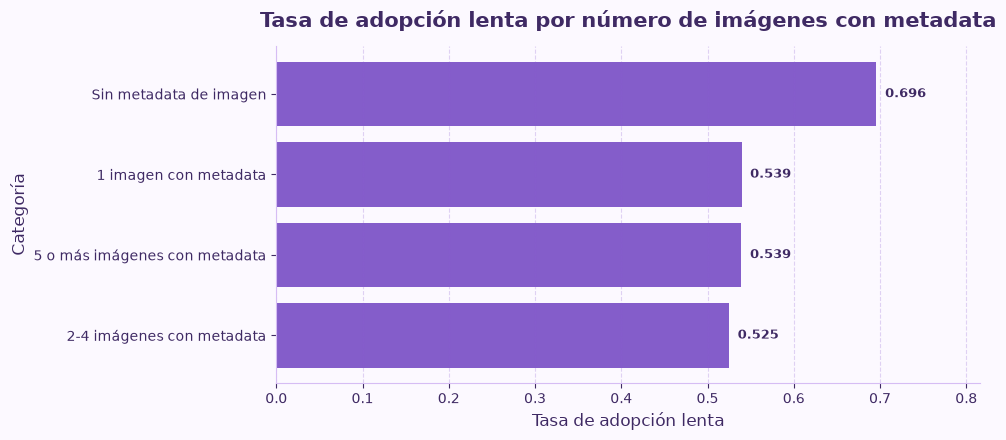

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_metadata_images_group.png


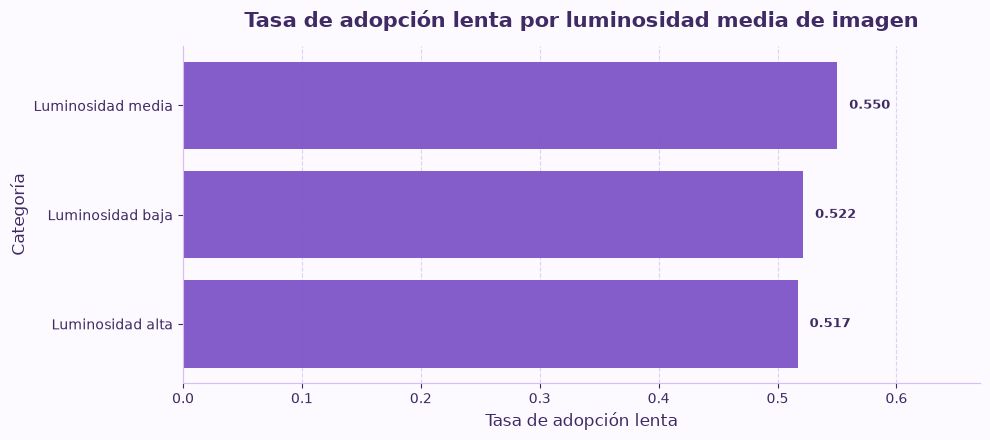

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_brightness_group.png


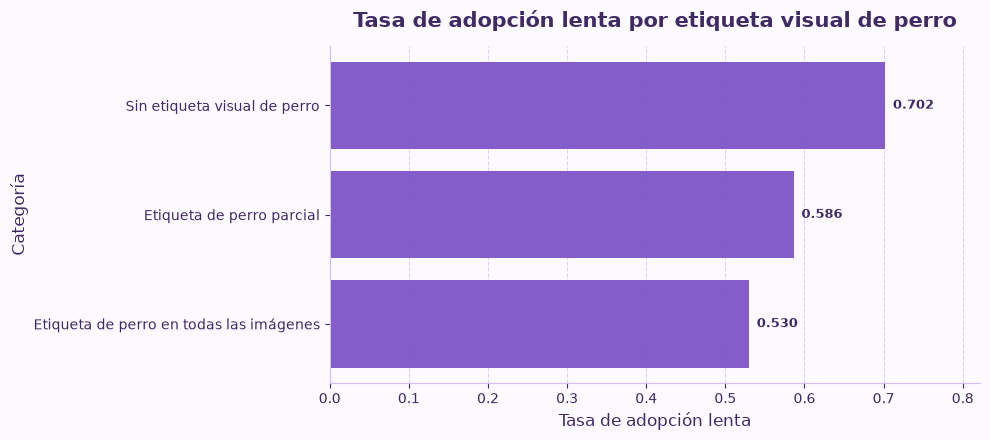

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_dog_label_visibility_group.png


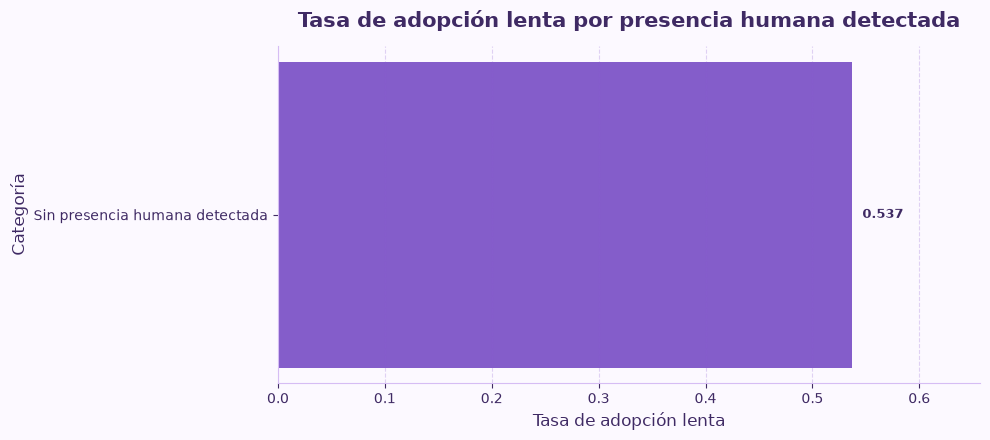

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_tasa_adopcion_lenta_por_person_label_group.png


In [76]:
# Gráficas de adopción lenta por metadata visual

for variable, nombre_variable in variables_metadata_eda.items():
    resumen_variable = resumen_adopcion_lenta_por_categoria(
        df=petfinder_dogs_enriched,
        variable=variable,
        nombre_variable=nombre_variable,
        min_n=20
    )
    
    nombre_archivo = (
        "petfinder_tasa_adopcion_lenta_por_"
        + variable
        + ".png"
    )
    
    graficar_tasa_adopcion_lenta(
        resumen_variable=resumen_variable,
        titulo=f"Tasa de adopción lenta por {nombre_variable.lower()}",
        nombre_archivo=nombre_archivo
    )

El análisis de metadata visual permite complementar el estudio de fotografías con información extraída automáticamente de las imágenes.

Los resultados muestran que los perros sin metadata de imagen presentan una tasa de adopción lenta elevada. Este patrón es coherente con el análisis previo de número de fotografías, ya que la ausencia de imágenes o de información visual reduce la visibilidad pública del animal.

Además, la variable de etiqueta visual de perro resulta especialmente relevante. Los perros cuyas imágenes no contienen una etiqueta visual clara de perro presentan una tasa de adopción lenta superior. En cambio, cuando la etiqueta de perro aparece en todas las imágenes, la tasa de adopción lenta es menor.

Este resultado refuerza la idea de que la calidad y claridad visual de las fotografías puede formar parte del problema de invisibilidad. No basta con tener una ficha publicada: la imagen debe permitir identificar correctamente al animal y presentarlo de forma reconocible ante posibles adoptantes.

La luminosidad muestra diferencias más moderadas, por lo que se interpreta como una señal complementaria. La presencia humana detectada no resulta especialmente informativa en este análisis, ya que la gran mayoría de los casos no contiene presencia humana identificada en las imágenes.

### 8.1. Análisis de etiquetas visuales

Además de las variables agregadas de metadata, se analizan las etiquetas visuales detectadas en las imágenes.

Este análisis permite identificar qué conceptos aparecen con más frecuencia en las fotografías de los perros y si algunas etiquetas están más asociadas a adopción lenta o no lenta.

Al igual que en el análisis textual, los resultados se interpretan como patrones descriptivos. No se consideran causalidad, sino señales útiles para entender la presentación visual del animal y preparar el módulo visual del prototipo.

In [77]:
# Unión de etiquetas visuales con el target de adopción lenta

labels_visuales_dogs = petfinder_image_labels_train_dogs.merge(
    petfinder_dogs_enriched[["PetID", "target_adopcion_lenta"]],
    on="PetID",
    how="inner"
)

labels_visuales_dogs["label_description"] = (
    labels_visuales_dogs["label_description"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Dimensiones de etiquetas visuales con target:")
print(labels_visuales_dogs.shape)

print("\nPrimeras etiquetas visuales:")
display(labels_visuales_dogs.head(10))

Dimensiones de etiquetas visuales con target:
(279592, 6)

Primeras etiquetas visuales:


,PetID,image_number,label_description,label_score,label_topicality,target_adopcion_lenta
0,3422e4906,1,dog,0.960457,0.960457,1
1,3422e4906,1,dog like mammal,0.941660,0.941660,1
2,3422e4906,1,dog breed,0.941017,0.941017,1
3,3422e4906,1,dog breed group,0.903123,0.903123,1
4,3422e4906,1,miniature fox terrier,0.737992,0.737992,1
5,3422e4906,1,jack russell terrier,0.727047,0.727047,1
6,3422e4906,1,puppy,0.720260,0.720260,1
7,3422e4906,1,russell terrier,0.674215,0.674215,1
8,3422e4906,1,carnivoran,0.649802,0.649802,1
9,3422e4906,1,snout,0.616009,0.616009,1


In [78]:
# Etiquetas visuales más frecuentes en imágenes de perros PetFinder

frecuencia_labels_visuales = (
    labels_visuales_dogs
    .groupby("label_description")
    .agg(
        frecuencia=("label_description", "size"),
        score_medio=("label_score", "mean"),
        topicality_media=("label_topicality", "mean"),
        n_pets=("PetID", "nunique")
    )
    .reset_index()
    .sort_values("frecuencia", ascending=False)
)

frecuencia_labels_visuales["score_medio"] = frecuencia_labels_visuales["score_medio"].round(4)
frecuencia_labels_visuales["topicality_media"] = frecuencia_labels_visuales["topicality_media"].round(4)

frecuencia_labels_visuales_path = petfinder_outputs_path / "frecuencia_labels_visuales_petfinder.csv"

frecuencia_labels_visuales.to_csv(
    frecuencia_labels_visuales_path,
    index=False,
    encoding="utf-8-sig"
)

print("Top 30 etiquetas visuales más frecuentes:")
display(frecuencia_labels_visuales.head(30))

print("Frecuencia de etiquetas visuales guardada en:")
print(frecuencia_labels_visuales_path)

Top 30 etiquetas visuales más frecuentes:


,label_description,frecuencia,score_medio,topicality_media,n_pets
273,dog like mammal,29611,0.9004,0.9004,7900
266,dog breed,29251,0.9301,0.9301,7872
264,dog,29232,0.9536,0.9536,7875
267,dog breed group,27686,0.8561,0.8561,7665
874,snout,21746,0.7133,0.7133,6918
167,carnivoran,21141,0.6350,0.6350,6810
752,puppy,13079,0.7086,0.7086,4554
907,street dog,10222,0.7454,0.7454,4211
888,sporting group,8690,0.5532,0.5532,3883
764,rare breed dog,6183,0.5593,0.5593,2990


Frecuencia de etiquetas visuales guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\frecuencia_labels_visuales_petfinder.csv


In [79]:
# Etiquetas visuales diferenciales entre adopción lenta y no lenta

frecuencia_labels_target = (
    labels_visuales_dogs
    .groupby(["label_description", "target_adopcion_lenta"])
    .size()
    .reset_index(name="frecuencia")
)

frecuencia_labels_pivot = (
    frecuencia_labels_target
    .pivot_table(
        index="label_description",
        columns="target_adopcion_lenta",
        values="frecuencia",
        fill_value=0
    )
    .reset_index()
)

frecuencia_labels_pivot.columns.name = None

if 0 not in frecuencia_labels_pivot.columns:
    frecuencia_labels_pivot[0] = 0

if 1 not in frecuencia_labels_pivot.columns:
    frecuencia_labels_pivot[1] = 0

frecuencia_labels_pivot = frecuencia_labels_pivot.rename(
    columns={
        0: "frecuencia_no_lenta",
        1: "frecuencia_lenta"
    }
)

frecuencia_labels_pivot["frecuencia_no_lenta"] = frecuencia_labels_pivot["frecuencia_no_lenta"].astype(int)
frecuencia_labels_pivot["frecuencia_lenta"] = frecuencia_labels_pivot["frecuencia_lenta"].astype(int)

frecuencia_labels_pivot["frecuencia_total"] = (
    frecuencia_labels_pivot["frecuencia_no_lenta"]
    + frecuencia_labels_pivot["frecuencia_lenta"]
)

total_labels_no_lenta = frecuencia_labels_pivot["frecuencia_no_lenta"].sum()
total_labels_lenta = frecuencia_labels_pivot["frecuencia_lenta"].sum()

frecuencia_labels_pivot["freq_rel_no_lenta"] = (
    (frecuencia_labels_pivot["frecuencia_no_lenta"] + 1)
    / (total_labels_no_lenta + len(frecuencia_labels_pivot))
)

frecuencia_labels_pivot["freq_rel_lenta"] = (
    (frecuencia_labels_pivot["frecuencia_lenta"] + 1)
    / (total_labels_lenta + len(frecuencia_labels_pivot))
)

frecuencia_labels_pivot["log_ratio_lenta_vs_no_lenta"] = np.log(
    frecuencia_labels_pivot["freq_rel_lenta"]
    / frecuencia_labels_pivot["freq_rel_no_lenta"]
)

frecuencia_labels_pivot_filtrada = frecuencia_labels_pivot.loc[
    frecuencia_labels_pivot["frecuencia_total"] >= 50
].copy()

frecuencia_labels_pivot_filtrada = frecuencia_labels_pivot_filtrada.sort_values(
    "log_ratio_lenta_vs_no_lenta",
    ascending=False
).reset_index(drop=True)

labels_mas_asociadas_lenta = frecuencia_labels_pivot_filtrada.head(25).copy()

labels_mas_asociadas_no_lenta = (
    frecuencia_labels_pivot_filtrada
    .sort_values("log_ratio_lenta_vs_no_lenta", ascending=True)
    .head(25)
    .copy()
)

frecuencia_labels_pivot_filtrada_path = (
    petfinder_outputs_path / "comparacion_labels_visuales_petfinder.csv"
)

frecuencia_labels_pivot_filtrada.to_csv(
    frecuencia_labels_pivot_filtrada_path,
    index=False,
    encoding="utf-8-sig"
)

print("Etiquetas visuales más asociadas a adopción lenta:")
display(
    labels_mas_asociadas_lenta[
        [
            "label_description",
            "frecuencia_lenta",
            "frecuencia_no_lenta",
            "frecuencia_total",
            "log_ratio_lenta_vs_no_lenta"
        ]
    ].round(4)
)

print("\nEtiquetas visuales más asociadas a adopción no lenta:")
display(
    labels_mas_asociadas_no_lenta[
        [
            "label_description",
            "frecuencia_lenta",
            "frecuencia_no_lenta",
            "frecuencia_total",
            "log_ratio_lenta_vs_no_lenta"
        ]
    ].round(4)
)

Etiquetas visuales más asociadas a adopción lenta:


,label_description,frecuencia_lenta,frecuencia_no_lenta,frecuencia_total,log_ratio_lenta_vs_no_lenta
0,galgo español,69,21,90,1.0004
1,pointer,80,25,105,0.9793
2,car,66,21,87,0.9566
3,play,56,18,74,0.9416
4,hunting dog,451,155,606,0.9068
5,vehicle,44,15,59,0.8770
6,greyhound,259,94,353,0.8498
7,formosan mountain dog,317,116,433,0.8428
8,lurcher,54,20,74,0.8058
9,pariah dog,892,347,1239,0.7853



Etiquetas visuales más asociadas a adopción no lenta:


,label_description,frecuencia_lenta,frecuencia_no_lenta,frecuencia_total,log_ratio_lenta_vs_no_lenta
229,volpino italiano,9,48,57,-1.7463
228,löwchen,13,50,63,-1.4498
227,german spitz klein,18,63,81,-1.3715
226,bichon,12,39,51,-1.2810
225,german spitz mittel,14,44,58,-1.2557
224,chinese imperial dog,32,96,128,-1.2353
223,tornjak,15,43,58,-1.1687
222,tibetan spaniel,24,65,89,-1.1278
221,maltese,61,153,214,-1.0669
220,morkie,41,99,140,-1.0246


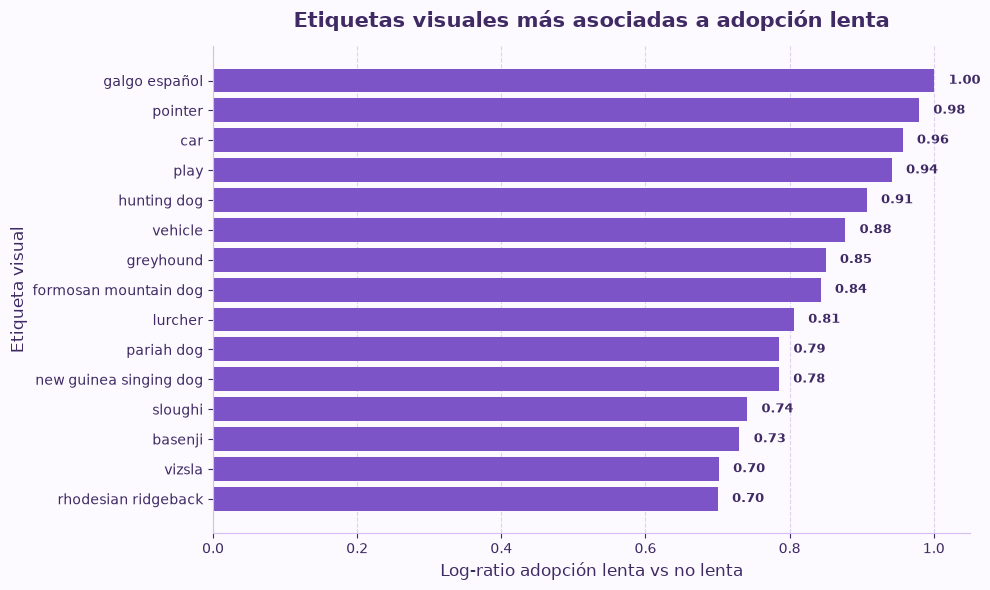

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_labels_visuales_asociadas_adopcion_lenta.png


In [80]:
# Gráfico de etiquetas visuales más asociadas a adopción lenta

datos_labels_lenta_plot = (
    labels_mas_asociadas_lenta
    .head(15)
    .sort_values("log_ratio_lenta_vs_no_lenta", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_labels_lenta_plot["label_description"],
    datos_labels_lenta_plot["log_ratio_lenta_vs_no_lenta"],
    color="#6F42C1",
    alpha=0.9
)

for i, row in enumerate(datos_labels_lenta_plot.itertuples()):
    ax.text(
        row.log_ratio_lenta_vs_no_lenta + 0.02,
        i,
        f"{row.log_ratio_lenta_vs_no_lenta:.2f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Etiquetas visuales más asociadas a adopción lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel(
    "Log-ratio adopción lenta vs no lenta",
    fontsize=12,
    color="#3F2A64"
)

ax.set_ylabel(
    "Etiqueta visual",
    fontsize=12,
    color="#3F2A64"
)

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_labels_visuales_asociadas_adopcion_lenta.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [81]:
# Creación de grupos semánticos visuales a partir de etiquetas de imagen

grupos_labels_visuales = {
    "visual_menciona_perro": [
        "dog", "puppy", "dog breed", "canidae", "companion dog"
    ],
    "visual_menciona_exterior": [
        "grass", "plant", "tree", "sky", "outdoor", "natural landscape",
        "landscape", "road", "street", "field", "garden"
    ],
    "visual_menciona_interior": [
        "room", "floor", "wall", "furniture", "indoor", "house",
        "home", "couch", "sofa", "bed"
    ],
    "visual_menciona_persona": [
        "person", "people", "human", "hand", "arm", "leg"
    ],
    "visual_menciona_cara_cuerpo": [
        "snout", "nose", "eye", "ear", "head", "facial expression",
        "vertebrate", "mammal"
    ]
}

labels_por_pet = (
    labels_visuales_dogs
    .groupby("PetID")["label_description"]
    .apply(lambda valores: " ".join(sorted(set(valores))))
    .reset_index(name="labels_visuales_concat")
)

petfinder_dogs_enriched = petfinder_dogs_enriched.merge(
    labels_por_pet,
    on="PetID",
    how="left"
)

petfinder_dogs_enriched["labels_visuales_concat"] = (
    petfinder_dogs_enriched["labels_visuales_concat"]
    .fillna("")
    .astype(str)
)

for nombre_grupo, keywords in grupos_labels_visuales.items():
    patron = r"\b(?:" + "|".join([re.escape(palabra) for palabra in keywords]) + r")\b"
    petfinder_dogs_enriched[nombre_grupo] = (
        petfinder_dogs_enriched["labels_visuales_concat"]
        .str.contains(patron, regex=True)
    )

variables_grupos_visuales = list(grupos_labels_visuales.keys())

print("Variables semánticas visuales creadas:")
display(
    petfinder_dogs_enriched[
        ["PetID", "target_adopcion_lenta"] + variables_grupos_visuales
    ].head(10)
)

Variables semánticas visuales creadas:


,PetID,target_adopcion_lenta,visual_menciona_perro,visual_menciona_exterior,visual_menciona_interior,visual_menciona_persona,visual_menciona_cara_cuerpo
0,3422e4906,1,True,True,False,False,True
1,5842f1ff5,0,True,True,False,False,True
2,850a43f90,0,True,True,True,False,True
3,97aa9eeac,1,True,False,False,False,True
4,8b693ca84,0,True,True,False,False,True
5,aaedd873d,0,True,False,False,False,True
6,c02be41e6,0,True,True,False,False,True
7,1fd342e17,1,True,False,False,False,True
8,f9d07d5fa,1,True,False,False,False,True
9,1c92ce464,0,True,True,False,False,True


In [82]:
# Resumen de adopción lenta por grupos semánticos visuales

resumen_grupos_visuales = []

for variable in variables_grupos_visuales:
    resumen_variable = (
        petfinder_dogs_enriched
        .groupby(variable)
        .agg(
            n_perros=("PetID", "size"),
            n_adopcion_lenta=("target_adopcion_lenta", "sum"),
            tasa_adopcion_lenta=("target_adopcion_lenta", "mean"),
            adoption_speed_medio=("AdoptionSpeed", "mean")
        )
        .reset_index()
        .rename(columns={variable: "menciona_grupo_visual"})
    )
    
    resumen_variable["grupo_visual"] = variable.replace("visual_menciona_", "").replace("_", " ")
    
    resumen_variable["porcentaje_perros"] = (
        resumen_variable["n_perros"] / resumen_variable["n_perros"].sum() * 100
    )
    
    resumen_grupos_visuales.append(resumen_variable)

resumen_grupos_visuales = pd.concat(
    resumen_grupos_visuales,
    ignore_index=True
)

resumen_grupos_visuales["menciona_grupo_visual_label"] = np.where(
    resumen_grupos_visuales["menciona_grupo_visual"],
    "Menciona el grupo visual",
    "No menciona el grupo visual"
)

resumen_grupos_visuales["tasa_adopcion_lenta"] = resumen_grupos_visuales["tasa_adopcion_lenta"].round(4)
resumen_grupos_visuales["adoption_speed_medio"] = resumen_grupos_visuales["adoption_speed_medio"].round(4)
resumen_grupos_visuales["porcentaje_perros"] = resumen_grupos_visuales["porcentaje_perros"].round(2)

resumen_grupos_visuales_path = petfinder_outputs_path / "resumen_grupos_visuales_petfinder.csv"

resumen_grupos_visuales.to_csv(
    resumen_grupos_visuales_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de grupos semánticos visuales:")
display(resumen_grupos_visuales)

print("Resumen guardado en:")
print(resumen_grupos_visuales_path)

Resumen de grupos semánticos visuales:


,menciona_grupo_visual,n_perros,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,grupo_visual,porcentaje_perros,menciona_grupo_visual_label
0,False,218,153,0.7018,3.0321,perro,2.68,No menciona el grupo visual
1,True,7914,4210,0.5320,2.6036,perro,97.32,Menciona el grupo visual
2,False,3651,1715,0.4697,2.4303,exterior,44.90,No menciona el grupo visual
3,True,4481,2648,0.5909,2.7657,exterior,55.10,Menciona el grupo visual
4,False,7519,4009,0.5332,2.6065,interior,92.46,No menciona el grupo visual
5,True,613,354,0.5775,2.7210,interior,7.54,Menciona el grupo visual
6,False,8034,4316,0.5372,2.6160,persona,98.79,No menciona el grupo visual
7,True,98,47,0.4796,2.5408,persona,1.21,Menciona el grupo visual
8,False,211,147,0.6967,3.0000,cara cuerpo,2.59,No menciona el grupo visual
9,True,7921,4216,0.5323,2.6048,cara cuerpo,97.41,Menciona el grupo visual


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_grupos_visuales_petfinder.csv


In [83]:
# Guardado del dataset PetFinder enriquecido completo

petfinder_dogs_enriched_completo_path = processed_data_path / "petfinder_dogs_enriched_completo.csv"

petfinder_dogs_enriched.to_csv(
    petfinder_dogs_enriched_completo_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset PetFinder enriquecido completo guardado en:")
print(petfinder_dogs_enriched_completo_path)

print("\nDimensiones finales:")
print(petfinder_dogs_enriched.shape)

Dataset PetFinder enriquecido completo guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\petfinder_dogs_enriched_completo.csv

Dimensiones finales:
(8132, 101)


El análisis de etiquetas visuales permite estudiar qué conceptos aparecen de forma automática en las imágenes de PetFinder.

Las etiquetas más frecuentes corresponden principalmente a conceptos relacionados con perros, razas, cachorros, hocico, cuerpo y grupos caninos. Esto confirma que los metadatos visuales contienen información útil para caracterizar la presentación pública del animal.

El análisis diferencial muestra que algunas etiquetas más asociadas a adopción lenta corresponden a razas o tipos visuales concretos, como galgo, pointer, greyhound o pariah dog. Estos resultados deben interpretarse con cautela, ya que pueden reflejar diferencias de composición del dataset y no efectos causales de la imagen.

Más relevante para el enfoque de *Invisible Dogs* es el análisis por grupos visuales. Los perros sin una etiqueta visual clara de perro, o sin etiquetas relacionadas con cara/cuerpo, presentan tasas de adopción lenta más elevadas. En cambio, cuando las imágenes permiten identificar claramente al perro, la tasa de adopción lenta es menor.

En conjunto, este bloque refuerza la importancia de la visibilidad visual. La imagen no se utiliza todavía como entrada directa de una red neuronal, pero los metadatos permiten anticipar que la calidad y claridad de las fotografías pueden ser relevantes para el diseño posterior del módulo visual del prototipo.

## 9. Modelización complementaria con PetFinder

Una vez enriquecido el dataset de perros de PetFinder con variables estructuradas, textuales, de sentimiento y de metadata visual, se desarrolla una modelización complementaria para predecir adopción lenta.

Este bloque no pretende sustituir el modelo principal construido con Austin Animal Center. Su finalidad es evaluar si, en un dataset externo y más equilibrado, las variables de presentación pública del animal aportan señal predictiva.

El proceso de modelización se organiza en varias etapas:

- modelo baseline;
- modelos estructurados con variables tabulares;
- modelos con variables de visibilidad, texto, sentimiento y metadata;
- modelos con representación TF-IDF de las descripciones;
- ajuste mediante validación cruzada y selección final del modelo.

La variable objetivo será `target_adopcion_lenta`, definida como `AdoptionSpeed >= 3`.


In [84]:
# Importaciones adicionales para modelización complementaria

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

try:
    from lightgbm import LGBMClassifier
    lightgbm_disponible = True
except Exception:
    lightgbm_disponible = False

try:
    from catboost import CatBoostClassifier
    catboost_disponible = True
except Exception:
    catboost_disponible = False

print("LightGBM disponible:", lightgbm_disponible)
print("CatBoost disponible:", catboost_disponible)

LightGBM disponible: True
CatBoost disponible: True


In [85]:
# Variable objetivo de PetFinder

variable_objetivo_petfinder = "target_adopcion_lenta"

print("Variable objetivo PetFinder:")
print(variable_objetivo_petfinder)

Variable objetivo PetFinder:
target_adopcion_lenta


In [86]:
# Selección de variables y preparación del dataset de modelización PetFinder

variable_objetivo_petfinder = "target_adopcion_lenta"

variables_numericas_petfinder = [
    "Age",
    "Quantity",
    "Fee",
    "VideoAmt",
    "PhotoAmt",
    "age_months",
    "description_chars",
    "description_words",
    "description_tokens_count",
    "description_unique_tokens",
    "description_lexical_diversity",
    "score_calidad_ficha",
    "sentiment_score",
    "sentiment_magnitude",
    "n_sentences_sentiment",
    "n_entities_sentiment",
    "n_metadata_images",
    "n_label_annotations_mean",
    "label_score_mean",
    "pct_images_with_dog_label",
    "pct_images_with_person_label",
    "brightness_mean",
    "brightness_median",
    "dominant_color_score_mean",
    "dominant_color_pixel_fraction_mean"
]

variables_booleanas_petfinder = [
    "is_mixed_breed",
    "has_name",
    "has_photo",
    "has_video",
    "has_description",
    "has_fee",
    "menciona_personalidad_positiva",
    "menciona_sociabilidad",
    "menciona_salud_cuidados",
    "menciona_urgencia_rescate",
    "menciona_comportamiento_necesidades",
    "menciona_vinculo_emocional",
    "visual_menciona_perro",
    "visual_menciona_exterior",
    "visual_menciona_interior",
    "visual_menciona_persona",
    "visual_menciona_cara_cuerpo"
]

variables_categoricas_petfinder = [
    "gender_label",
    "maturity_size_label",
    "fur_length_label",
    "vaccinated_label",
    "dewormed_label",
    "sterilized_label",
    "health_label",
    "breed1_name",
    "breed2_name",
    "color1_name",
    "color2_name",
    "color3_name",
    "state_name",
    "is_mixed_breed_label",
    "has_name_label",
    "age_group_petfinder",
    "photo_group",
    "video_group",
    "has_photo_label",
    "has_video_label",
    "has_description_label",
    "description_group",
    "has_fee_label",
    "fee_group",
    "calidad_ficha_label",
    "sentiment_score_group",
    "sentiment_magnitude_group",
    "metadata_images_group",
    "brightness_group",
    "dog_label_visibility_group",
    "person_label_group"
]

# Nos quedamos solo con variables que existen realmente en el dataset
variables_numericas_petfinder = [
    variable for variable in variables_numericas_petfinder
    if variable in petfinder_dogs_enriched.columns
]

variables_booleanas_petfinder = [
    variable for variable in variables_booleanas_petfinder
    if variable in petfinder_dogs_enriched.columns
]

variables_categoricas_petfinder = [
    variable for variable in variables_categoricas_petfinder
    if variable in petfinder_dogs_enriched.columns
]

variables_modelizacion_petfinder = (
    variables_numericas_petfinder
    + variables_booleanas_petfinder
    + variables_categoricas_petfinder
)

# Eliminamos posibles duplicados conservando el orden
variables_modelizacion_petfinder = list(dict.fromkeys(variables_modelizacion_petfinder))

print("Variables numéricas:", len(variables_numericas_petfinder))
print("Variables booleanas:", len(variables_booleanas_petfinder))
print("Variables categóricas:", len(variables_categoricas_petfinder))
print("Total variables de modelización:", len(variables_modelizacion_petfinder))

# Dataset de modelización
petfinder_model_df = petfinder_dogs_enriched[
    ["PetID", variable_objetivo_petfinder] + variables_modelizacion_petfinder
].copy()

for variable in variables_booleanas_petfinder:
    petfinder_model_df[variable] = petfinder_model_df[variable].astype(int)

X_petfinder = petfinder_model_df[variables_modelizacion_petfinder].copy()
y_petfinder = petfinder_model_df[variable_objetivo_petfinder].astype(int).copy()

# Split train / valid / test estratificado
X_train_dev_petfinder, X_test_petfinder, y_train_dev_petfinder, y_test_petfinder = train_test_split(
    X_petfinder,
    y_petfinder,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_petfinder
)

X_train_petfinder, X_valid_petfinder, y_train_petfinder, y_valid_petfinder = train_test_split(
    X_train_dev_petfinder,
    y_train_dev_petfinder,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_dev_petfinder
)

print("\nDimensiones de modelización PetFinder:")
print("Train:", X_train_petfinder.shape)
print("Valid:", X_valid_petfinder.shape)
print("Test:", X_test_petfinder.shape)

print("\nDistribución del target en train:")
display(
    y_train_petfinder
    .value_counts(normalize=True)
    .sort_index()
    .rename("proporcion")
    .reset_index()
)

print("\nDistribución del target en valid:")
display(
    y_valid_petfinder
    .value_counts(normalize=True)
    .sort_index()
    .rename("proporcion")
    .reset_index()
)

# La distribución de la variable objetivo en test no se inspecciona durante el desarrollo.

# Guardado del split
split_petfinder = pd.DataFrame({
    "PetID": petfinder_model_df["PetID"],
    "conjunto_petfinder": "sin_asignar"
})

split_petfinder.loc[X_train_petfinder.index, "conjunto_petfinder"] = "train"
split_petfinder.loc[X_valid_petfinder.index, "conjunto_petfinder"] = "valid"
split_petfinder.loc[X_test_petfinder.index, "conjunto_petfinder"] = "test"

split_petfinder_path = petfinder_outputs_path / "split_petfinder_modelizacion.csv"

split_petfinder.to_csv(
    split_petfinder_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nSplit guardado en:")
print(split_petfinder_path)

Variables numéricas: 25
Variables booleanas: 17
Variables categóricas: 31
Total variables de modelización: 73

Dimensiones de modelización PetFinder:
Train: (5204, 73)
Valid: (1301, 73)
Test: (1627, 73)

Distribución del target en train:


,target_adopcion_lenta,proporcion
0,0,0.46349
1,1,0.53651



Distribución del target en valid:


,target_adopcion_lenta,proporcion
0,0,0.46349
1,1,0.53651



Split guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\split_petfinder_modelizacion.csv


In [87]:
# Funciones auxiliares de métricas y búsqueda de umbral

def calcular_metricas_petfinder(y_true, y_pred, y_score, nombre_modelo, umbral):
    metricas = {
        "modelo": nombre_modelo,
        "umbral": umbral,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
        "n_predichos_adopcion_lenta": int(np.sum(y_pred)),
        "pct_predichos_adopcion_lenta": float(np.mean(y_pred))
    }
    
    return metricas


def buscar_umbral_optimo_f1_petfinder(y_true, y_score):
    umbrales = np.arange(0.05, 0.96, 0.01)
    resultados = []
    
    for umbral in umbrales:
        y_pred = (y_score >= umbral).astype(int)
        resultados.append({
            "umbral": round(float(umbral), 2),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0),
            "n_predichos_adopcion_lenta": int(np.sum(y_pred)),
            "pct_predichos_adopcion_lenta": float(np.mean(y_pred))
        })
    
    tabla_umbrales = pd.DataFrame(resultados)
    
    tabla_umbrales = tabla_umbrales.sort_values(
        ["f1_score", "recall", "precision"],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    
    mejor_umbral = float(tabla_umbrales.loc[0, "umbral"])
    
    return mejor_umbral, tabla_umbrales

In [88]:
# Preprocesador común para modelos con variables estructuradas

preprocesador_petfinder = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            variables_numericas_petfinder + variables_booleanas_petfinder
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Sin información")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
                ]
            ),
            variables_categoricas_petfinder
        )
    ],
    remainder="drop"
)

print("Preprocesador definido correctamente.")

Preprocesador definido correctamente.


In [89]:
# Entrenamiento de baseline y modelos estructurados iniciales

modelos_petfinder = {}

modelos_petfinder["Baseline clase mayoritaria"] = Pipeline(
    steps=[
        ("preprocesador", preprocesador_petfinder),
        ("modelo", DummyClassifier(strategy="most_frequent"))
    ]
)

modelos_petfinder["Regresión logística estructurada"] = Pipeline(
    steps=[
        ("preprocesador", preprocesador_petfinder),
        ("modelo", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

modelos_petfinder["Random Forest estructurado"] = Pipeline(
    steps=[
        ("preprocesador", preprocesador_petfinder),
        ("modelo", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

if lightgbm_disponible:
    modelos_petfinder["LightGBM estructurado"] = Pipeline(
        steps=[
            ("preprocesador", preprocesador_petfinder),
            ("modelo", LGBMClassifier(
                objective="binary",
                n_estimators=600,
                learning_rate=0.03,
                num_leaves=31,
                min_child_samples=40,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1
            ))
        ]
    )

resultados_modelos_petfinder = []
umbrales_modelos_petfinder = {}

for nombre_modelo, pipeline_modelo in modelos_petfinder.items():
    print(f"Entrenando: {nombre_modelo}")
    
    pipeline_modelo.fit(X_train_petfinder, y_train_petfinder)
    
    if hasattr(pipeline_modelo.named_steps["modelo"], "predict_proba"):
        y_valid_score = pipeline_modelo.predict_proba(X_valid_petfinder)[:, 1]
    else:
        y_valid_score = pipeline_modelo.predict(X_valid_petfinder)
    
    if nombre_modelo == "Baseline clase mayoritaria":
        umbral_optimo = 0.50
        y_valid_pred = pipeline_modelo.predict(X_valid_petfinder)
        tabla_umbrales = pd.DataFrame()
    else:
        umbral_optimo, tabla_umbrales = buscar_umbral_optimo_f1_petfinder(
            y_true=y_valid_petfinder,
            y_score=y_valid_score
        )
        y_valid_pred = (y_valid_score >= umbral_optimo).astype(int)
    
    umbrales_modelos_petfinder[nombre_modelo] = {
        "umbral": umbral_optimo,
        "tabla_umbrales": tabla_umbrales
    }
    
    metricas_valid = calcular_metricas_petfinder(
        y_true=y_valid_petfinder,
        y_pred=y_valid_pred,
        y_score=y_valid_score,
        nombre_modelo=nombre_modelo,
        umbral=umbral_optimo
    )
    
    metricas_valid["conjunto"] = "valid"
    resultados_modelos_petfinder.append(metricas_valid)

resultados_modelos_petfinder_df = pd.DataFrame(resultados_modelos_petfinder)

columnas_metricas_petfinder = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision",
    "pct_predichos_adopcion_lenta"
]

resultados_modelos_petfinder_df[columnas_metricas_petfinder] = (
    resultados_modelos_petfinder_df[columnas_metricas_petfinder]
    .round(4)
)

print("Resultados en validación:")
display(
    resultados_modelos_petfinder_df
    .sort_values("f1_score", ascending=False)
)

Entrenando: Baseline clase mayoritaria
Entrenando: Regresión logística estructurada
Entrenando: Random Forest estructurado
Entrenando: LightGBM estructurado
Resultados en validación:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,n_predichos_adopcion_lenta,pct_predichos_adopcion_lenta,conjunto
3,LightGBM estructurado,0.41,0.6449,0.6332,0.8037,0.7083,0.7056,0.7267,886,0.6810,valid
1,Regresión logística estructurada,0.32,0.5972,0.5792,0.9112,0.7082,0.6981,0.7238,1098,0.8440,valid
2,Random Forest estructurado,0.40,0.5926,0.5754,0.9183,0.7075,0.7025,0.7336,1114,0.8563,valid
0,Baseline clase mayoritaria,0.50,0.5365,0.5365,1.0000,0.6983,0.5000,0.5365,1301,1.0000,valid


In [90]:
# Guardado de los resultados de los modelos estructurados en validación

resultados_modelos_petfinder_valid_path = (
    petfinder_outputs_path / "resultados_modelos_estructurados_petfinder_valid.csv"
)

resultados_modelos_petfinder_df.to_csv(
    resultados_modelos_petfinder_valid_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resultados de validación guardados en:")
print(resultados_modelos_petfinder_valid_path)


Resultados de validación guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resultados_modelos_estructurados_petfinder_valid.csv


In [91]:
# Selección del mejor modelo estructurado según F1-score en validación

mejor_modelo_estructurado_nombre = (
    resultados_modelos_petfinder_df
    .sort_values("f1_score", ascending=False)
    .iloc[0]["modelo"]
)

mejor_modelo_estructurado_petfinder = modelos_petfinder[mejor_modelo_estructurado_nombre]
mejor_umbral_estructurado_petfinder = umbrales_modelos_petfinder[mejor_modelo_estructurado_nombre]["umbral"]

print("Mejor modelo estructurado PetFinder:")
print(mejor_modelo_estructurado_nombre)

print("\nUmbral seleccionado en validación:")
print(mejor_umbral_estructurado_petfinder)

Mejor modelo estructurado PetFinder:
LightGBM estructurado

Umbral seleccionado en validación:
0.41


In [92]:
# Matriz de confusión del mejor modelo estructurado en validación

if hasattr(mejor_modelo_estructurado_petfinder.named_steps["modelo"], "predict_proba"):
    y_valid_score_mejor_estructurado = mejor_modelo_estructurado_petfinder.predict_proba(
        X_valid_petfinder
    )[:, 1]
else:
    y_valid_score_mejor_estructurado = mejor_modelo_estructurado_petfinder.predict(
        X_valid_petfinder
    )

y_valid_pred_mejor_estructurado = (
    y_valid_score_mejor_estructurado >= mejor_umbral_estructurado_petfinder
).astype(int)

matriz_confusion_mejor_estructurado = confusion_matrix(
    y_valid_petfinder,
    y_valid_pred_mejor_estructurado
)

matriz_confusion_df = pd.DataFrame(
    matriz_confusion_mejor_estructurado,
    index=["Real no lenta", "Real lenta"],
    columns=["Predicha no lenta", "Predicha lenta"]
)

print("Matriz de confusión del mejor modelo estructurado en validación:")
display(matriz_confusion_df)

print("\nClassification report:")
print(
    classification_report(
        y_valid_petfinder,
        y_valid_pred_mejor_estructurado,
        target_names=["Adopción no lenta", "Adopción lenta"],
        zero_division=0
    )
)


Matriz de confusión del mejor modelo estructurado en validación:


,Predicha no lenta,Predicha lenta
Real no lenta,278,325
Real lenta,137,561



Classification report:
                   precision    recall  f1-score   support

Adopción no lenta       0.67      0.46      0.55       603
   Adopción lenta       0.63      0.80      0.71       698

         accuracy                           0.64      1301
        macro avg       0.65      0.63      0.63      1301
     weighted avg       0.65      0.64      0.63      1301



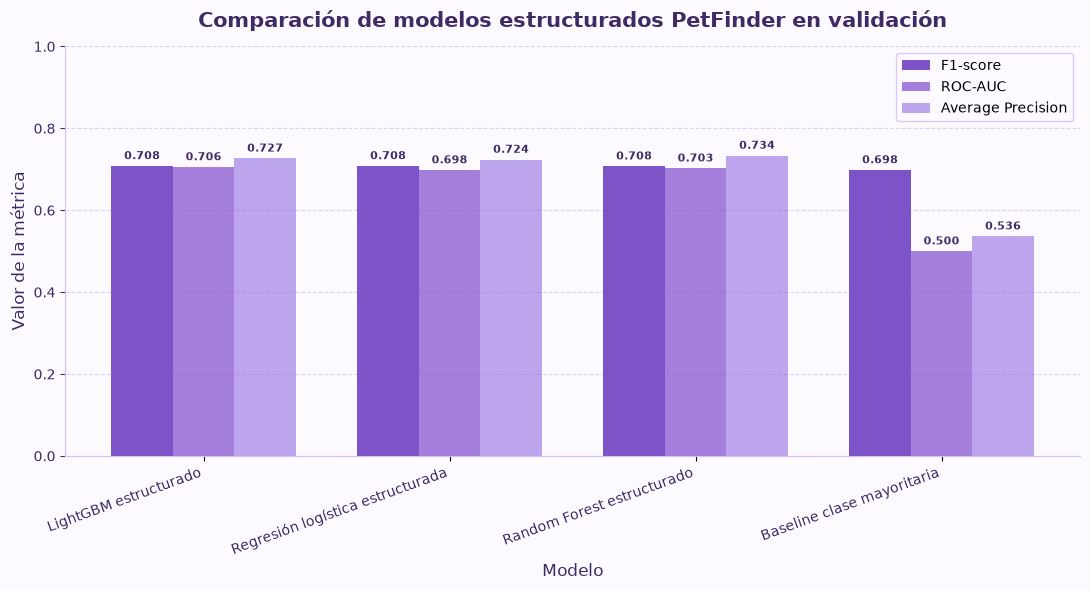

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_comparacion_modelos_estructurados_valid.png


In [93]:
# Gráfico comparativo de modelos estructurados en validación

metricas_plot_modelos = resultados_modelos_petfinder_df.melt(
    id_vars=["modelo"],
    value_vars=["f1_score", "roc_auc", "average_precision"],
    var_name="metrica",
    value_name="valor"
)

metricas_plot_modelos["metrica"] = metricas_plot_modelos["metrica"].map({
    "f1_score": "F1-score",
    "roc_auc": "ROC-AUC",
    "average_precision": "Average Precision"
})

orden_modelos_plot = (
    resultados_modelos_petfinder_df
    .sort_values("f1_score", ascending=False)["modelo"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

x = np.arange(len(orden_modelos_plot))
width = 0.25
metricas_unicas = ["F1-score", "ROC-AUC", "Average Precision"]
colores_metricas = {
    "F1-score": "#6F42C1",
    "ROC-AUC": "#9B72D9",
    "Average Precision": "#B79CED"
}

for i, metrica in enumerate(metricas_unicas):
    valores = []
    for modelo in orden_modelos_plot:
        valor = metricas_plot_modelos.loc[
            (metricas_plot_modelos["modelo"] == modelo)
            & (metricas_plot_modelos["metrica"] == metrica),
            "valor"
        ].iloc[0]
        valores.append(valor)

    barras = ax.bar(
        x + (i - 1) * width,
        valores,
        width,
        label=metrica,
        color=colores_metricas[metrica],
        alpha=0.9
    )

    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f"{altura:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "Comparación de modelos estructurados PetFinder en validación",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)
ax.set_xlabel("Modelo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Valor de la métrica", fontsize=12, color="#3F2A64")
ax.set_xticks(x)
ax.set_xticklabels(orden_modelos_plot, rotation=20, ha="right", color="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF")
legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()

fig_path = figures_path / "petfinder_comparacion_modelos_estructurados_valid.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:")
print(fig_path)


El primer bloque de modelización complementaria muestra que las variables estructuradas, textuales simples, de sentimiento y de metadata visual aportan señal predictiva para identificar perros con adopción lenta en PetFinder.

La comparación inicial se realiza sobre el conjunto de validación. El modelo estructurado con mejor F1-score se conserva como referencia para estudiar el comportamiento de este tipo de variables, mientras que el conjunto de test permanece reservado para la evaluación final del proceso completo de selección.

El baseline de clase mayoritaria permite contextualizar los resultados: al predecir sistemáticamente la clase más frecuente puede alcanzar un F1 aparentemente competitivo, pero carece de capacidad discriminativa. Por ello, la valoración conjunta considera también ROC-AUC y Average Precision.

En conjunto, este bloque confirma que PetFinder contiene señal predictiva útil y que las variables de presentación pública del animal pueden ayudar a caracterizar casos con mayor dificultad de adopción. La siguiente fase incorpora representación textual mediante TF-IDF para comprobar si el contenido completo de las descripciones aporta información adicional.


## 10. Modelización con texto mediante TF-IDF

En los bloques anteriores se han creado variables textuales agregadas, como longitud de la descripción, número de tokens, diversidad léxica y menciones semánticas.

Sin embargo, estas variables resumen el texto y no aprovechan todo el contenido de la descripción. Por ello, en este bloque se incorpora una representación TF-IDF de las descripciones públicas de los perros.

Se comparan dos enfoques:

- modelo basado únicamente en texto;
- modelo combinado con variables estructuradas, visibilidad, sentiment, metadata visual y texto TF-IDF.

El objetivo es evaluar si la descripción pública del animal aporta señal adicional para detectar adopción lenta.

In [94]:
# Creación de texto depurado para TF-IDF

stopwords_tfidf_extra = set("""
contact call whatsapp sms msg message phone email interested
please pls kindly
some does then from the and for with
""".split())

def preparar_texto_tfidf_petfinder(texto):
    tokens = tokenizar_texto_petfinder(texto)
    tokens = [
        token
        for token in tokens
        if token not in stopwords_tfidf_extra
    ]
    return " ".join(tokens)

petfinder_dogs_enriched["description_tfidf_clean"] = (
    petfinder_dogs_enriched["Description"]
    .fillna("")
    .astype(str)
    .apply(preparar_texto_tfidf_petfinder)
)

print("Texto depurado para TF-IDF creado correctamente.")

display(
    petfinder_dogs_enriched[
        [
            "PetID",
            "Description",
            "description_tfidf_clean",
            "target_adopcion_lenta"
        ]
    ].head(10)
)

Texto depurado para TF-IDF creado correctamente.


,PetID,Description,description_tfidf_clean,target_adopcion_lenta
0,3422e4906,Their pregnant mother was dumped by her irresp...,pregnant mother dumped irresponsible owner roa...,1
1,5842f1ff5,"Good guard dog, very alert, active, obedience ...",good guard alert active obedience waiting good...,0
2,850a43f90,This handsome yet cute boy is up for adoption....,handsome yet cute boy playful pal seen loves n...,0
3,97aa9eeac,Siu Pak just give birth on 13/6/10 to 6puppies...,siu pak give birth left female,1
4,8b693ca84,"For serious adopter, please do sms or call for...",serious details,0
5,aaedd873d,Peanut was an abused puppy until he was rescue...,peanut abused rescued scared people happy acti...,0
6,c02be41e6,"Lost Dog Found (Bandar Menjalara, Kepong／Taman...",lost found bandar menjalara kepong taman bukit...,0
7,1fd342e17,We moved out of our apartment to a landed home...,moved apartment landed many friendly strays ne...,1
8,f9d07d5fa,shes active... she can obey wht command that u...,shes active obey wht command told example shak...,1
9,1c92ce464,This cutie dumped by it's owner at the market ...,cutie dumped owner market almost kill car kick...,0


In [95]:
# Preparación de datasets para modelos con texto depurado

variable_texto_petfinder = "description_tfidf_clean"

if variable_texto_petfinder not in petfinder_dogs_enriched.columns:
    raise ValueError("No se encuentra description_tfidf_clean. Ejecuta primero la celda de texto depurado para TF-IDF.")

variables_modelizacion_petfinder_texto = (
    variables_modelizacion_petfinder
    + [variable_texto_petfinder]
)

petfinder_model_texto_df = petfinder_dogs_enriched[
    ["PetID", variable_objetivo_petfinder] + variables_modelizacion_petfinder_texto
].copy()

petfinder_model_texto_df[variable_texto_petfinder] = (
    petfinder_model_texto_df[variable_texto_petfinder]
    .fillna("")
    .astype(str)
)

for variable in variables_booleanas_petfinder:
    petfinder_model_texto_df[variable] = petfinder_model_texto_df[variable].astype(int)

X_texto_petfinder = petfinder_model_texto_df[variables_modelizacion_petfinder_texto].copy()
y_texto_petfinder = petfinder_model_texto_df[variable_objetivo_petfinder].astype(int).copy()

X_train_texto_petfinder = X_texto_petfinder.loc[X_train_petfinder.index].copy()
X_valid_texto_petfinder = X_texto_petfinder.loc[X_valid_petfinder.index].copy()
X_test_texto_petfinder = X_texto_petfinder.loc[X_test_petfinder.index].copy()

y_train_texto_petfinder = y_texto_petfinder.loc[y_train_petfinder.index].copy()
y_valid_texto_petfinder = y_texto_petfinder.loc[y_valid_petfinder.index].copy()
y_test_texto_petfinder = y_texto_petfinder.loc[y_test_petfinder.index].copy()

print("Dimensiones de datasets con texto depurado:")
print("Train:", X_train_texto_petfinder.shape)
print("Valid:", X_valid_texto_petfinder.shape)
print("Test:", X_test_texto_petfinder.shape)

print("\nEjemplo de descripción depurada para TF-IDF:")
display(
    X_train_texto_petfinder[[variable_texto_petfinder]]
    .head(5)
)


Dimensiones de datasets con texto depurado:
Train: (5204, 74)
Valid: (1301, 74)
Test: (1627, 74)

Ejemplo de descripción depurada para TF-IDF:


,description_tfidf_clean
7477,name age month dob breed mixed mongrel gender ...
967,cute adorable looks like doberman pinscher mix...
3439,playful boy jumping around friendly see people
2528,dexter rescued friend puchong good natured ste...
544,found near taman seem like abandoned owner try...


In [96]:
# Preprocesadores para modelos con texto TF-IDF

tfidf_petfinder = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

preprocesador_solo_texto_petfinder = ColumnTransformer(
    transformers=[
        (
            "texto",
            tfidf_petfinder,
            variable_texto_petfinder
        )
    ],
    remainder="drop"
)

preprocesador_estructurado_texto_petfinder = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            variables_numericas_petfinder + variables_booleanas_petfinder
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Sin información")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
                ]
            ),
            variables_categoricas_petfinder
        ),
        (
            "texto",
            TfidfVectorizer(
                max_features=5000,
                min_df=5,
                max_df=0.85,
                ngram_range=(1, 2),
                sublinear_tf=True
            ),
            variable_texto_petfinder
        )
    ],
    remainder="drop"
)

print("Preprocesadores con TF-IDF definidos correctamente.")

Preprocesadores con TF-IDF definidos correctamente.


In [97]:
# Entrenamiento de modelos con texto TF-IDF

modelos_petfinder_texto = {}

modelos_petfinder_texto["Solo texto TF-IDF"] = Pipeline(
    steps=[
        ("preprocesador", preprocesador_solo_texto_petfinder),
        ("modelo", LogisticRegression(
            max_iter=1500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

modelos_petfinder_texto["Estructurado + texto TF-IDF"] = Pipeline(
    steps=[
        ("preprocesador", preprocesador_estructurado_texto_petfinder),
        ("modelo", LogisticRegression(
            max_iter=1500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

resultados_modelos_petfinder_texto_valid = []
umbrales_modelos_petfinder_texto = {}

for nombre_modelo, pipeline_modelo in modelos_petfinder_texto.items():
    print(f"Entrenando: {nombre_modelo}")
    
    pipeline_modelo.fit(X_train_texto_petfinder, y_train_texto_petfinder)
    
    y_valid_score = pipeline_modelo.predict_proba(X_valid_texto_petfinder)[:, 1]
    
    umbral_optimo, tabla_umbrales = buscar_umbral_optimo_f1_petfinder(
        y_true=y_valid_texto_petfinder,
        y_score=y_valid_score
    )
    
    y_valid_pred = (y_valid_score >= umbral_optimo).astype(int)
    
    umbrales_modelos_petfinder_texto[nombre_modelo] = {
        "umbral": umbral_optimo,
        "tabla_umbrales": tabla_umbrales
    }
    
    metricas_valid = calcular_metricas_petfinder(
        y_true=y_valid_texto_petfinder,
        y_pred=y_valid_pred,
        y_score=y_valid_score,
        nombre_modelo=nombre_modelo,
        umbral=umbral_optimo
    )
    
    metricas_valid["conjunto"] = "valid"
    resultados_modelos_petfinder_texto_valid.append(metricas_valid)

resultados_modelos_petfinder_texto_valid_df = pd.DataFrame(
    resultados_modelos_petfinder_texto_valid
)

resultados_modelos_petfinder_texto_valid_df[columnas_metricas_petfinder] = (
    resultados_modelos_petfinder_texto_valid_df[columnas_metricas_petfinder]
    .round(4)
)

print("Resultados de modelos con texto en validación:")
display(
    resultados_modelos_petfinder_texto_valid_df
    .sort_values("f1_score", ascending=False)
)

Entrenando: Solo texto TF-IDF
Entrenando: Estructurado + texto TF-IDF
Resultados de modelos con texto en validación:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,n_predichos_adopcion_lenta,pct_predichos_adopcion_lenta,conjunto
1,Estructurado + texto TF-IDF,0.31,0.6218,0.5975,0.9040,0.7195,0.7141,0.7317,1056,0.8117,valid
0,Solo texto TF-IDF,0.28,0.5534,0.5463,0.9885,0.7037,0.6464,0.6656,1263,0.9708,valid


In [98]:
# Guardado de los resultados de los modelos con texto en validación

resultados_modelos_petfinder_texto_valid_path = (
    petfinder_outputs_path / "resultados_modelos_texto_petfinder_valid.csv"
)

resultados_modelos_petfinder_texto_valid_df.to_csv(
    resultados_modelos_petfinder_texto_valid_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resultados de modelos con texto en validación guardados en:")
print(resultados_modelos_petfinder_texto_valid_path)


Resultados de modelos con texto en validación guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resultados_modelos_texto_petfinder_valid.csv


In [99]:
# Comparación global de modelos estructurados y modelos con texto en validación

comparacion_global_modelos_petfinder_valid = pd.concat(
    [
        resultados_modelos_petfinder_df,
        resultados_modelos_petfinder_texto_valid_df
    ],
    ignore_index=True
)

comparacion_global_modelos_petfinder_valid = comparacion_global_modelos_petfinder_valid.sort_values(
    "f1_score",
    ascending=False
).reset_index(drop=True)

comparacion_global_modelos_petfinder_valid_path = (
    petfinder_outputs_path / "comparacion_global_modelos_petfinder_valid.csv"
)

comparacion_global_modelos_petfinder_valid.to_csv(
    comparacion_global_modelos_petfinder_valid_path,
    index=False,
    encoding="utf-8-sig"
)

print("Comparación global de modelos PetFinder en validación:")
display(comparacion_global_modelos_petfinder_valid)

print("Comparación global guardada en:")
print(comparacion_global_modelos_petfinder_valid_path)


Comparación global de modelos PetFinder en validación:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,n_predichos_adopcion_lenta,pct_predichos_adopcion_lenta,conjunto
0,Estructurado + texto TF-IDF,0.31,0.6218,0.5975,0.9040,0.7195,0.7141,0.7317,1056,0.8117,valid
1,LightGBM estructurado,0.41,0.6449,0.6332,0.8037,0.7083,0.7056,0.7267,886,0.6810,valid
2,Regresión logística estructurada,0.32,0.5972,0.5792,0.9112,0.7082,0.6981,0.7238,1098,0.8440,valid
3,Random Forest estructurado,0.40,0.5926,0.5754,0.9183,0.7075,0.7025,0.7336,1114,0.8563,valid
4,Solo texto TF-IDF,0.28,0.5534,0.5463,0.9885,0.7037,0.6464,0.6656,1263,0.9708,valid
5,Baseline clase mayoritaria,0.50,0.5365,0.5365,1.0000,0.6983,0.5000,0.5365,1301,1.0000,valid


Comparación global guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\comparacion_global_modelos_petfinder_valid.csv


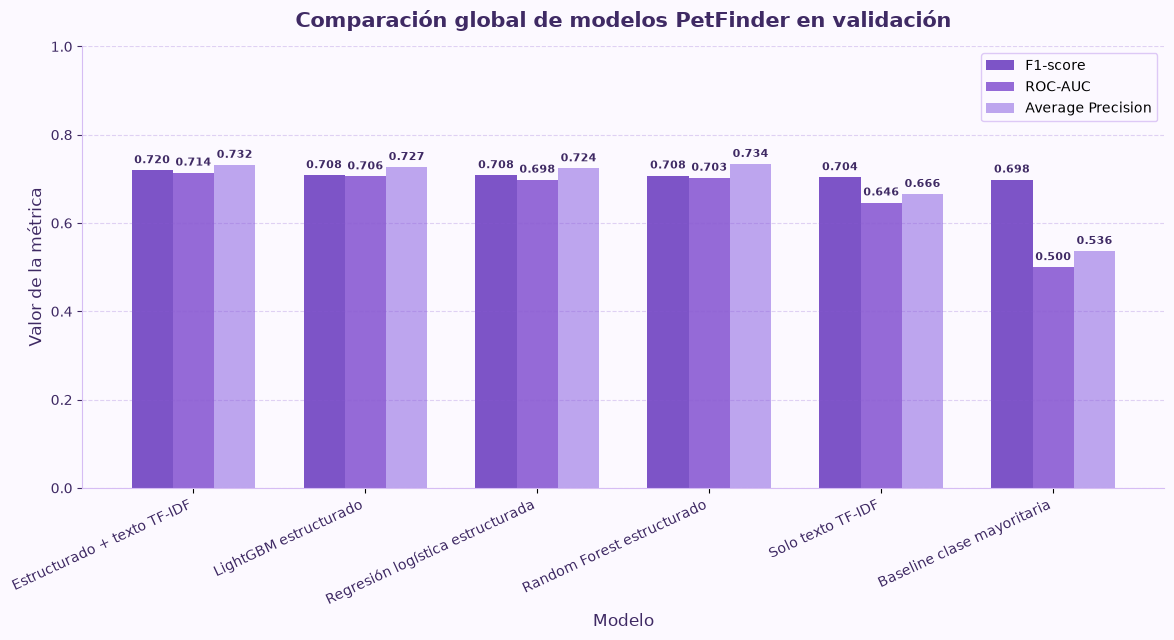

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_comparacion_global_modelos_valid.png


In [100]:
# Gráfico global de comparación de modelos PetFinder en validación

modelos_a_mostrar = comparacion_global_modelos_petfinder_valid.copy()

metricas_global_plot = modelos_a_mostrar.melt(
    id_vars=["modelo"],
    value_vars=["f1_score", "roc_auc", "average_precision"],
    var_name="metrica",
    value_name="valor"
)

metricas_global_plot["metrica"] = metricas_global_plot["metrica"].map({
    "f1_score": "F1-score",
    "roc_auc": "ROC-AUC",
    "average_precision": "Average Precision"
})

orden_modelos_global = modelos_a_mostrar["modelo"].tolist()

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

x = np.arange(len(orden_modelos_global))
width = 0.24
metricas_unicas = ["F1-score", "ROC-AUC", "Average Precision"]
colores_metricas = {
    "F1-score": "#6F42C1",
    "ROC-AUC": "#8A5BD3",
    "Average Precision": "#B79CED"
}

for i, metrica in enumerate(metricas_unicas):
    valores = []
    for modelo in orden_modelos_global:
        valor = metricas_global_plot.loc[
            (metricas_global_plot["modelo"] == modelo)
            & (metricas_global_plot["metrica"] == metrica),
            "valor"
        ].iloc[0]
        valores.append(valor)

    barras = ax.bar(
        x + (i - 1) * width,
        valores,
        width,
        label=metrica,
        color=colores_metricas[metrica],
        alpha=0.9
    )

    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f"{altura:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "Comparación global de modelos PetFinder en validación",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)
ax.set_xlabel("Modelo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Valor de la métrica", fontsize=12, color="#3F2A64")
ax.set_xticks(x)
ax.set_xticklabels(orden_modelos_global, rotation=25, ha="right", color="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF")
legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()

fig_path = figures_path / "petfinder_comparacion_global_modelos_valid.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:")
print(fig_path)


In [101]:
# Selección del modelo de referencia PetFinder según F1-score en validación

mejor_modelo_global_petfinder_nombre = (
    comparacion_global_modelos_petfinder_valid
    .iloc[0]["modelo"]
)

if mejor_modelo_global_petfinder_nombre in modelos_petfinder:
    mejor_modelo_global_petfinder = modelos_petfinder[mejor_modelo_global_petfinder_nombre]
    mejor_umbral_global_petfinder = umbrales_modelos_petfinder[mejor_modelo_global_petfinder_nombre]["umbral"]
    X_valid_mejor_global = X_valid_petfinder
    y_valid_mejor_global = y_valid_petfinder
else:
    mejor_modelo_global_petfinder = modelos_petfinder_texto[mejor_modelo_global_petfinder_nombre]
    mejor_umbral_global_petfinder = umbrales_modelos_petfinder_texto[mejor_modelo_global_petfinder_nombre]["umbral"]
    X_valid_mejor_global = X_valid_texto_petfinder
    y_valid_mejor_global = y_valid_texto_petfinder

print("Modelo de referencia PetFinder seleccionado en validación:")
print(mejor_modelo_global_petfinder_nombre)

print("\nUmbral asociado:")
print(mejor_umbral_global_petfinder)

print("\nLa selección se realiza sin consultar el conjunto de test.")


Modelo de referencia PetFinder seleccionado en validación:
Estructurado + texto TF-IDF

Umbral asociado:
0.31

La selección se realiza sin consultar el conjunto de test.


In [102]:
# Matriz de confusión del modelo de referencia en validación

y_valid_score_mejor_global = mejor_modelo_global_petfinder.predict_proba(
    X_valid_mejor_global
)[:, 1]

y_valid_pred_mejor_global = (
    y_valid_score_mejor_global >= mejor_umbral_global_petfinder
).astype(int)

matriz_confusion_mejor_global = confusion_matrix(
    y_valid_mejor_global,
    y_valid_pred_mejor_global
)

matriz_confusion_mejor_global_df = pd.DataFrame(
    matriz_confusion_mejor_global,
    index=["Real no lenta", "Real lenta"],
    columns=["Predicha no lenta", "Predicha lenta"]
)

print("Matriz de confusión del modelo de referencia en validación:")
display(matriz_confusion_mejor_global_df)

print("\nClassification report:")
print(
    classification_report(
        y_valid_mejor_global,
        y_valid_pred_mejor_global,
        target_names=["Adopción no lenta", "Adopción lenta"],
        zero_division=0
    )
)


Matriz de confusión del modelo de referencia en validación:


,Predicha no lenta,Predicha lenta
Real no lenta,178,425
Real lenta,67,631



Classification report:
                   precision    recall  f1-score   support

Adopción no lenta       0.73      0.30      0.42       603
   Adopción lenta       0.60      0.90      0.72       698

         accuracy                           0.62      1301
        macro avg       0.66      0.60      0.57      1301
     weighted avg       0.66      0.62      0.58      1301



In [103]:
# Análisis Top-K del modelo de referencia en validación

def calcular_topk_petfinder(y_true, y_score, porcentajes_top):
    df_topk = pd.DataFrame({
        "target_real": np.array(y_true),
        "score_modelo": np.array(y_score)
    }).sort_values("score_modelo", ascending=False).reset_index(drop=True)

    total_positivos = df_topk["target_real"].sum()
    tasa_base = df_topk["target_real"].mean()
    resultados_topk = []

    for porcentaje in porcentajes_top:
        n_top = max(1, int(np.ceil(len(df_topk) * porcentaje)))
        df_top = df_topk.head(n_top)
        casos_lentos_detectados = int(df_top["target_real"].sum())
        precision_top = casos_lentos_detectados / n_top
        recall_top = casos_lentos_detectados / total_positivos if total_positivos > 0 else 0
        lift_top = precision_top / tasa_base if tasa_base > 0 else np.nan

        resultados_topk.append({
            "segmento": f"Top {int(porcentaje * 100)}%",
            "porcentaje": porcentaje,
            "n_perros": n_top,
            "casos_adopcion_lenta_detectados": casos_lentos_detectados,
            "precision_topk": precision_top,
            "recall_topk": recall_top,
            "lift": lift_top
        })

    resultados_topk = pd.DataFrame(resultados_topk)
    columnas_redondear = ["porcentaje", "precision_topk", "recall_topk", "lift"]
    resultados_topk[columnas_redondear] = resultados_topk[columnas_redondear].round(4)
    return resultados_topk

porcentajes_top_petfinder = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]

topk_referencia_petfinder_valid = calcular_topk_petfinder(
    y_true=y_valid_mejor_global,
    y_score=y_valid_score_mejor_global,
    porcentajes_top=porcentajes_top_petfinder
)

topk_referencia_petfinder_valid["modelo"] = mejor_modelo_global_petfinder_nombre

topk_referencia_petfinder_valid_path = (
    petfinder_outputs_path / "topk_modelo_referencia_petfinder_valid.csv"
)
topk_referencia_petfinder_valid.to_csv(
    topk_referencia_petfinder_valid_path,
    index=False,
    encoding="utf-8-sig"
)

print("Análisis Top-K del modelo de referencia en validación:")
display(topk_referencia_petfinder_valid)

print("Top-K guardado en:")
print(topk_referencia_petfinder_valid_path)


Análisis Top-K del modelo de referencia en validación:


,segmento,porcentaje,n_perros,casos_adopcion_lenta_detectados,precision_topk,recall_topk,lift,modelo
0,Top 1%,0.01,14,12,0.8571,0.0172,1.5976,Estructurado + texto TF-IDF
1,Top 5%,0.05,66,54,0.8182,0.0774,1.5250,Estructurado + texto TF-IDF
2,Top 10%,0.10,131,111,0.8473,0.1590,1.5793,Estructurado + texto TF-IDF
3,Top 20%,0.20,261,209,0.8008,0.2994,1.4925,Estructurado + texto TF-IDF
4,Top 30%,0.30,391,298,0.7621,0.4269,1.4206,Estructurado + texto TF-IDF
5,Top 50%,0.50,651,453,0.6959,0.6490,1.2970,Estructurado + texto TF-IDF


Top-K guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\topk_modelo_referencia_petfinder_valid.csv


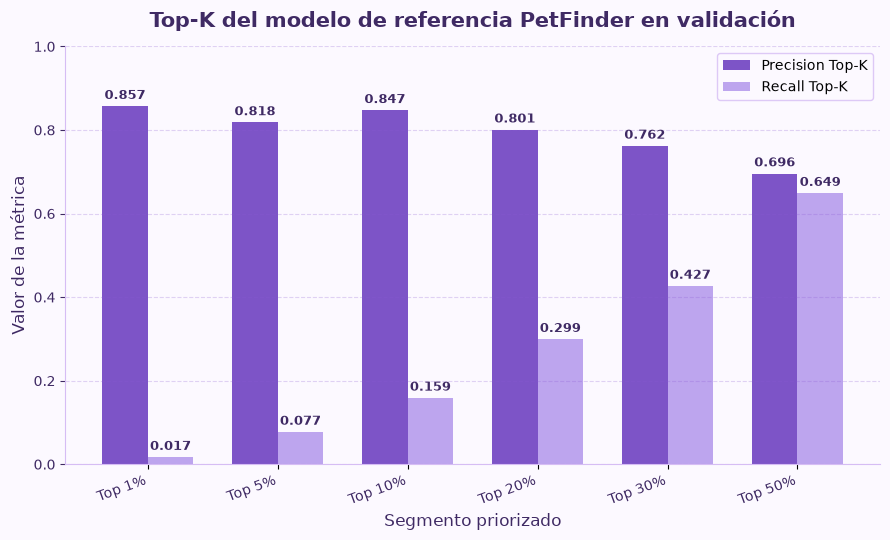

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_topk_modelo_referencia_valid.png


In [104]:
# Gráfico Top-K del modelo de referencia en validación

datos_topk_plot = topk_referencia_petfinder_valid.copy()

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

x = np.arange(len(datos_topk_plot))
width = 0.35

barras_precision = ax.bar(
    x - width / 2,
    datos_topk_plot["precision_topk"],
    width,
    label="Precision Top-K",
    color="#6F42C1",
    alpha=0.9
)
barras_recall = ax.bar(
    x + width / 2,
    datos_topk_plot["recall_topk"],
    width,
    label="Recall Top-K",
    color="#B79CED",
    alpha=0.9
)

for barras in [barras_precision, barras_recall]:
    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f"{altura:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "Top-K del modelo de referencia PetFinder en validación",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)
ax.set_xlabel("Segmento priorizado", fontsize=12, color="#3F2A64")
ax.set_ylabel("Valor de la métrica", fontsize=12, color="#3F2A64")
ax.set_xticks(x)
ax.set_xticklabels(datos_topk_plot["segmento"], rotation=20, ha="right", color="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")
legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF")
legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()

fig_path = figures_path / "petfinder_topk_modelo_referencia_valid.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:")
print(fig_path)


### 10.1. Evaluación probabilística del modelo de referencia en validación

Además de las métricas de clasificación y priorización, se revisa el comportamiento probabilístico del modelo de referencia sobre el conjunto de validación.

Esta comprobación permite estudiar si las puntuaciones estimadas mantienen una relación razonable con la tasa observada de adopción lenta antes de abordar el ajuste y la selección final. Se incorporan Brier score, curva ROC, curva Precision-Recall y curva de calibración.

El conjunto de test continúa reservado y no interviene en estas decisiones.


In [105]:
# Métricas probabilísticas del modelo de referencia en validación

from sklearn.metrics import brier_score_loss, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

brier_referencia_petfinder_valid = brier_score_loss(
    y_valid_mejor_global,
    y_valid_score_mejor_global
)

metricas_calibracion_referencia_valid = pd.DataFrame([
    {
        "modelo": mejor_modelo_global_petfinder_nombre,
        "conjunto": "valid",
        "umbral": mejor_umbral_global_petfinder,
        "brier_score": brier_referencia_petfinder_valid,
        "roc_auc": roc_auc_score(y_valid_mejor_global, y_valid_score_mejor_global),
        "average_precision": average_precision_score(y_valid_mejor_global, y_valid_score_mejor_global),
        "accuracy": accuracy_score(y_valid_mejor_global, y_valid_pred_mejor_global),
        "precision": precision_score(y_valid_mejor_global, y_valid_pred_mejor_global, zero_division=0),
        "recall": recall_score(y_valid_mejor_global, y_valid_pred_mejor_global, zero_division=0),
        "f1_score": f1_score(y_valid_mejor_global, y_valid_pred_mejor_global, zero_division=0),
        "tasa_base_adopcion_lenta": float(np.mean(y_valid_mejor_global))
    }
])

columnas_redondear_calibracion = [
    "umbral", "brier_score", "roc_auc", "average_precision",
    "accuracy", "precision", "recall", "f1_score", "tasa_base_adopcion_lenta"
]
metricas_calibracion_referencia_valid[columnas_redondear_calibracion] = (
    metricas_calibracion_referencia_valid[columnas_redondear_calibracion].round(4)
)

metricas_calibracion_referencia_valid_path = (
    petfinder_outputs_path / "metricas_calibracion_referencia_petfinder_valid.csv"
)
metricas_calibracion_referencia_valid.to_csv(
    metricas_calibracion_referencia_valid_path,
    index=False,
    encoding="utf-8-sig"
)

print("Métricas probabilísticas del modelo de referencia en validación:")
display(metricas_calibracion_referencia_valid)


Métricas probabilísticas del modelo de referencia en validación:


,modelo,conjunto,umbral,brier_score,roc_auc,average_precision,accuracy,precision,recall,f1_score,tasa_base_adopcion_lenta
0,Estructurado + texto TF-IDF,valid,0.31,0.2163,0.7141,0.7317,0.6218,0.5975,0.904,0.7195,0.5365


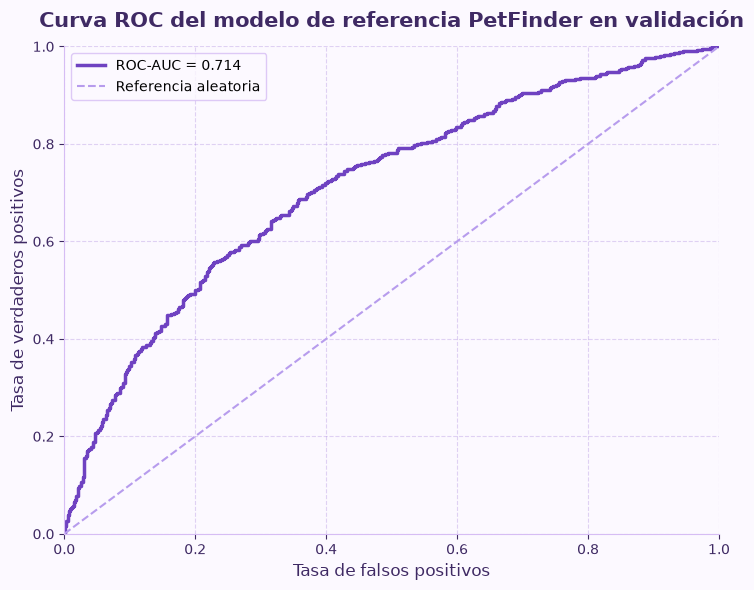

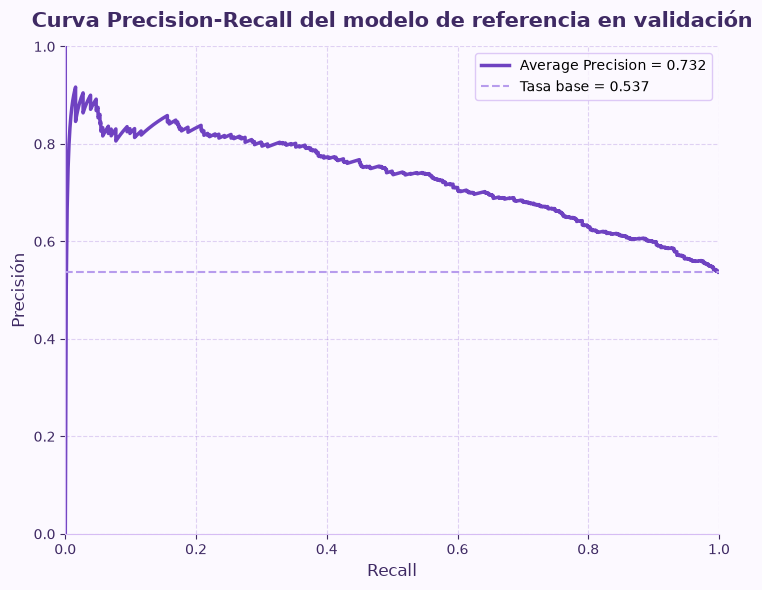

In [106]:
# Curvas ROC y Precision-Recall del modelo de referencia en validación

fpr_petfinder, tpr_petfinder, _ = roc_curve(
    y_valid_mejor_global,
    y_valid_score_mejor_global
)
precision_curve_petfinder, recall_curve_petfinder, _ = precision_recall_curve(
    y_valid_mejor_global,
    y_valid_score_mejor_global
)

roc_auc_referencia = roc_auc_score(y_valid_mejor_global, y_valid_score_mejor_global)
average_precision_referencia = average_precision_score(y_valid_mejor_global, y_valid_score_mejor_global)
tasa_base_petfinder_valid = float(np.mean(y_valid_mejor_global))

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")
ax.plot(fpr_petfinder, tpr_petfinder, color="#6F42C1", linewidth=2.5,
        label=f"ROC-AUC = {roc_auc_referencia:.3f}")
ax.plot([0, 1], [0, 1], color="#B79CED", linestyle="--", linewidth=1.5,
        label="Referencia aleatoria")
ax.set_title("Curva ROC del modelo de referencia PetFinder en validación",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Tasa de falsos positivos", fontsize=12, color="#3F2A64")
ax.set_ylabel("Tasa de verdaderos positivos", fontsize=12, color="#3F2A64")
ax.tick_params(axis="both", colors="#3F2A64")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(axis="both", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF"); legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()
fig_path_roc_petfinder = figures_path / "petfinder_curva_roc_referencia_valid.png"
fig.savefig(fig_path_roc_petfinder, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")
ax.plot(recall_curve_petfinder, precision_curve_petfinder, color="#6F42C1", linewidth=2.5,
        label=f"Average Precision = {average_precision_referencia:.3f}")
ax.axhline(tasa_base_petfinder_valid, color="#B79CED", linestyle="--", linewidth=1.5,
           label=f"Tasa base = {tasa_base_petfinder_valid:.3f}")
ax.set_title("Curva Precision-Recall del modelo de referencia en validación",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Recall", fontsize=12, color="#3F2A64")
ax.set_ylabel("Precisión", fontsize=12, color="#3F2A64")
ax.tick_params(axis="both", colors="#3F2A64")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(axis="both", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF"); legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()
fig_path_pr_petfinder = figures_path / "petfinder_curva_precision_recall_referencia_valid.png"
fig.savefig(fig_path_pr_petfinder, dpi=300, bbox_inches="tight")
plt.show()


Tabla de calibración del modelo de referencia en validación:


,probabilidad_media_predicha,tasa_real_adopcion_lenta,diferencia_real_menos_predicha
0,0.1602,0.2824,0.1222
1,0.2801,0.2769,-0.0032
2,0.3608,0.4538,0.0931
3,0.4238,0.3538,-0.0700
4,0.4931,0.5154,0.0222
5,0.5641,0.5308,-0.0333
6,0.6414,0.6615,0.0201
7,0.7200,0.6846,-0.0354
8,0.7984,0.7615,-0.0368
9,0.8946,0.8462,-0.0485


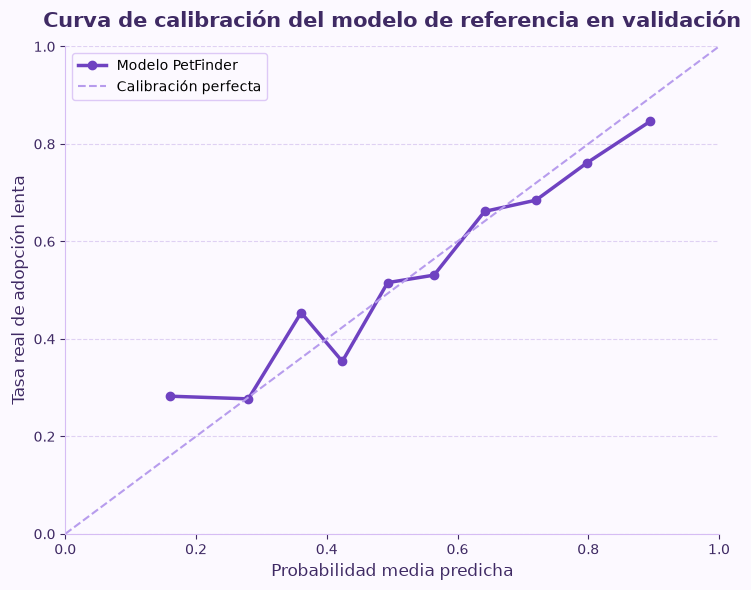

In [107]:
# Curva de calibración del modelo de referencia en validación

prob_true_petfinder, prob_pred_petfinder = calibration_curve(
    y_valid_mejor_global,
    y_valid_score_mejor_global,
    n_bins=10,
    strategy="quantile"
)

curva_calibracion_referencia_valid = pd.DataFrame({
    "probabilidad_media_predicha": prob_pred_petfinder,
    "tasa_real_adopcion_lenta": prob_true_petfinder
})
curva_calibracion_referencia_valid["diferencia_real_menos_predicha"] = (
    curva_calibracion_referencia_valid["tasa_real_adopcion_lenta"]
    - curva_calibracion_referencia_valid["probabilidad_media_predicha"]
)
curva_calibracion_referencia_valid = curva_calibracion_referencia_valid.round(4)

curva_calibracion_referencia_valid_path = (
    petfinder_outputs_path / "curva_calibracion_referencia_petfinder_valid.csv"
)
curva_calibracion_referencia_valid.to_csv(
    curva_calibracion_referencia_valid_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de calibración del modelo de referencia en validación:")
display(curva_calibracion_referencia_valid)

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")
ax.plot(
    curva_calibracion_referencia_valid["probabilidad_media_predicha"],
    curva_calibracion_referencia_valid["tasa_real_adopcion_lenta"],
    marker="o", color="#6F42C1", linewidth=2.5, label="Modelo PetFinder"
)
ax.plot([0, 1], [0, 1], color="#B79CED", linestyle="--", linewidth=1.5,
        label="Calibración perfecta")
ax.set_title("Curva de calibración del modelo de referencia en validación",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Probabilidad media predicha", fontsize=12, color="#3F2A64")
ax.set_ylabel("Tasa real de adopción lenta", fontsize=12, color="#3F2A64")
ax.tick_params(axis="both", colors="#3F2A64")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF"); legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()
fig_path_calibracion_petfinder = figures_path / "petfinder_curva_calibracion_referencia_valid.png"
fig.savefig(fig_path_calibracion_petfinder, dpi=300, bbox_inches="tight")
plt.show()


La evaluación probabilística del modelo de referencia complementa las métricas de clasificación y priorización utilizando exclusivamente el conjunto de validación.

El Brier score resume el error de las puntuaciones probabilísticas, mientras que las curvas ROC y Precision-Recall permiten estudiar la separación entre clases y la calidad del ranking. La curva de calibración compara la probabilidad media estimada con la tasa real observada.

Estas medidas se utilizan como diagnóstico del modelo de referencia. La selección final posterior se apoya en validación cruzada estratificada y el conjunto de test no se consulta hasta que modelo, hiperparámetros, pesos y umbral han quedado fijados.


La incorporación de TF-IDF permite evaluar si el contenido completo de las descripciones aporta señal adicional frente a las variables estructuradas y textuales agregadas.

En validación, el modelo combinado de variables estructuradas y texto TF-IDF obtiene el mejor F1-score entre los modelos de referencia, lo que indica que la descripción pública del animal contiene información complementaria. El modelo basado únicamente en texto también aporta señal, aunque su rendimiento es inferior al de los enfoques que combinan información estructurada y textual.

Estos resultados se utilizan como punto de partida para la fase de ajuste y selección final. En esa fase se amplía la representación textual, se ajustan los principales algoritmos y se comparan las alternativas mediante predicciones *out-of-fold* sobre `train + valid`, manteniendo el test completamente reservado hasta la evaluación final.


## 11. Interpretabilidad del modelo combinado de referencia PetFinder

El modelo combinado seleccionado como referencia en validación incorpora variables estructuradas, variables de visibilidad, sentimiento, metadata visual y representación textual TF-IDF.

Al tratarse de una regresión logística, es posible analizar sus coeficientes para identificar qué variables o términos aparecen más asociados a la predicción de adopción lenta y cuáles aparecen más asociados a adopción no lenta.

Esta interpretación debe entenderse como una lectura asociativa del modelo, no como una explicación causal. El objetivo es comprender qué señales utiliza el componente interpretable de PetFinder y cómo pueden alimentar el futuro módulo de análisis de ficha del prototipo.


In [108]:
# Extracción de coeficientes del mejor modelo global PetFinder

if mejor_modelo_global_petfinder_nombre != "Estructurado + texto TF-IDF":
    print("El mejor modelo global seleccionado no es el modelo combinado con texto.")
    print("Modelo seleccionado:", mejor_modelo_global_petfinder_nombre)
else:
    preprocesador_mejor_petfinder = mejor_modelo_global_petfinder.named_steps["preprocesador"]
    modelo_lineal_mejor_petfinder = mejor_modelo_global_petfinder.named_steps["modelo"]
    
    try:
        nombres_features_petfinder = preprocesador_mejor_petfinder.get_feature_names_out()
    except Exception:
        nombres_num_bool = [
            f"num__{variable}"
            for variable in variables_numericas_petfinder + variables_booleanas_petfinder
        ]
        
        cat_pipeline = preprocesador_mejor_petfinder.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        nombres_cat = [
            f"cat__{nombre}"
            for nombre in onehot.get_feature_names_out(variables_categoricas_petfinder)
        ]
        
        tfidf_model = preprocesador_mejor_petfinder.named_transformers_["texto"]
        nombres_texto = [
            f"texto__{termino}"
            for termino in tfidf_model.get_feature_names_out()
        ]
        
        nombres_features_petfinder = np.array(
            nombres_num_bool + nombres_cat + nombres_texto
        )
    
    coeficientes_petfinder = modelo_lineal_mejor_petfinder.coef_[0]
    
    importancia_modelo_petfinder = pd.DataFrame({
        "feature": nombres_features_petfinder,
        "coeficiente": coeficientes_petfinder
    })
    
    importancia_modelo_petfinder["coeficiente_abs"] = (
        importancia_modelo_petfinder["coeficiente"]
        .abs()
    )
    
    importancia_modelo_petfinder["tipo_feature"] = np.select(
        [
            importancia_modelo_petfinder["feature"].str.startswith("texto__"),
            importancia_modelo_petfinder["feature"].str.startswith("cat__"),
            importancia_modelo_petfinder["feature"].str.startswith("num__")
        ],
        [
            "Texto TF-IDF",
            "Variable categórica",
            "Variable numérica/booleana"
        ],
        default="Otra"
    )
    
    importancia_modelo_petfinder["feature_limpia"] = (
        importancia_modelo_petfinder["feature"]
        .str.replace("texto__", "", regex=False)
        .str.replace("cat__", "", regex=False)
        .str.replace("num__", "", regex=False)
    )
    
    importancia_modelo_petfinder = importancia_modelo_petfinder.sort_values(
        "coeficiente_abs",
        ascending=False
    ).reset_index(drop=True)
    
    importancia_modelo_petfinder_path = (
        petfinder_outputs_path / "importancia_coeficientes_mejor_modelo_petfinder.csv"
    )
    
    importancia_modelo_petfinder.to_csv(
        importancia_modelo_petfinder_path,
        index=False,
        encoding="utf-8-sig"
    )
    
    print("Top 25 señales con mayor peso absoluto:")
    display(
        importancia_modelo_petfinder[
            [
                "feature_limpia",
                "tipo_feature",
                "coeficiente",
                "coeficiente_abs"
            ]
        ].head(25).round(4)
    )
    
    print("Coeficientes guardados en:")
    print(importancia_modelo_petfinder_path)

Top 25 señales con mayor peso absoluto:


,feature_limpia,tipo_feature,coeficiente,coeficiente_abs
0,compulsory rachel,Texto TF-IDF,1.4463,1.4463
1,lil currently,Texto TF-IDF,-1.3306,1.3306
2,available,Texto TF-IDF,-1.3137,1.3137
3,ticks,Texto TF-IDF,-1.2909,1.2909
4,breed2_name_Rottweiler,Variable categórica,-1.2595,1.2595
5,doggie,Texto TF-IDF,1.2556,1.2556
6,never,Texto TF-IDF,1.2477,1.2477
7,adopting cute,Texto TF-IDF,1.1984,1.1984
8,joyceline,Texto TF-IDF,-1.1745,1.1745
9,amy,Texto TF-IDF,1.1659,1.1659


Coeficientes guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\importancia_coeficientes_mejor_modelo_petfinder.csv


In [109]:
# Señales más asociadas a adopción lenta y adopción no lenta

features_adopcion_lenta = (
    importancia_modelo_petfinder
    .sort_values("coeficiente", ascending=False)
    .head(25)
    .copy()
)

features_adopcion_no_lenta = (
    importancia_modelo_petfinder
    .sort_values("coeficiente", ascending=True)
    .head(25)
    .copy()
)

features_adopcion_lenta_path = (
    petfinder_outputs_path / "features_asociadas_adopcion_lenta_petfinder.csv"
)

features_adopcion_no_lenta_path = (
    petfinder_outputs_path / "features_asociadas_adopcion_no_lenta_petfinder.csv"
)

features_adopcion_lenta.to_csv(
    features_adopcion_lenta_path,
    index=False,
    encoding="utf-8-sig"
)

features_adopcion_no_lenta.to_csv(
    features_adopcion_no_lenta_path,
    index=False,
    encoding="utf-8-sig"
)

print("Top 25 señales asociadas a adopción lenta:")
display(
    features_adopcion_lenta[
        [
            "feature_limpia",
            "tipo_feature",
            "coeficiente"
        ]
    ].round(4)
)

print("\nTop 25 señales asociadas a adopción no lenta:")
display(
    features_adopcion_no_lenta[
        [
            "feature_limpia",
            "tipo_feature",
            "coeficiente"
        ]
    ].round(4)
)

Top 25 señales asociadas a adopción lenta:


,feature_limpia,tipo_feature,coeficiente
0,compulsory rachel,Texto TF-IDF,1.4463
5,doggie,Texto TF-IDF,1.2556
6,never,Texto TF-IDF,1.2477
7,adopting cute,Texto TF-IDF,1.1984
9,amy,Texto TF-IDF,1.1659
12,brothers,Texto TF-IDF,1.1302
15,traffic,Texto TF-IDF,1.0708
16,elderly,Texto TF-IDF,1.0708
17,rachel,Texto TF-IDF,1.0688
19,injured,Texto TF-IDF,1.0680



Top 25 señales asociadas a adopción no lenta:


,feature_limpia,tipo_feature,coeficiente
1,lil currently,Texto TF-IDF,-1.3306
2,available,Texto TF-IDF,-1.3137
3,ticks,Texto TF-IDF,-1.2909
4,breed2_name_Rottweiler,Variable categórica,-1.2595
8,joyceline,Texto TF-IDF,-1.1745
10,permanent,Texto TF-IDF,-1.1629
11,female weeks,Texto TF-IDF,-1.1627
13,hair,Texto TF-IDF,-1.1187
14,male,Texto TF-IDF,-1.1050
18,new born,Texto TF-IDF,-1.0684


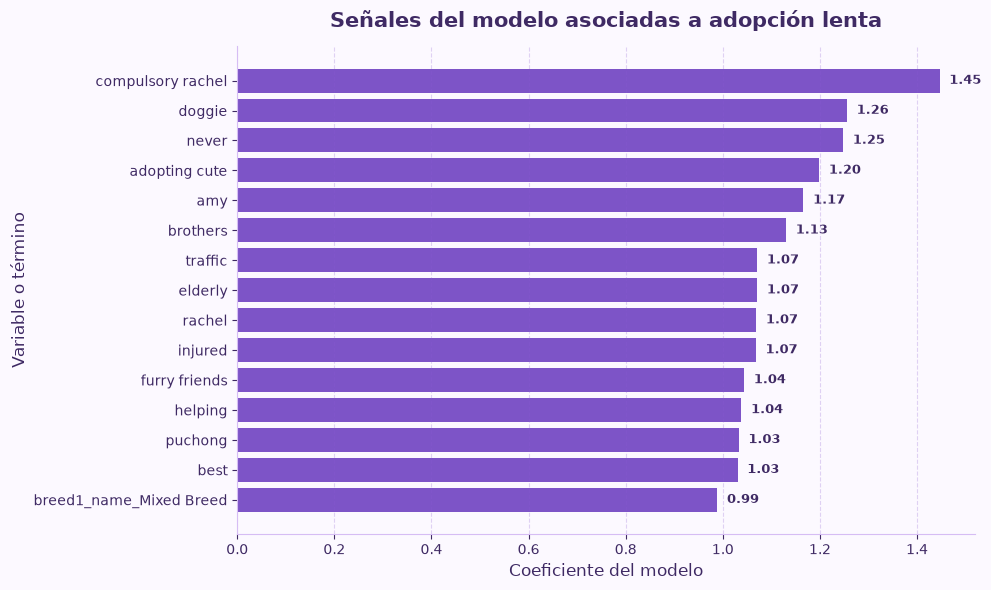

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_senales_modelo_asociadas_adopcion_lenta.png


In [110]:
# Gráfico de señales más asociadas a adopción lenta

datos_lenta_plot = (
    features_adopcion_lenta
    .head(15)
    .sort_values("coeficiente", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_lenta_plot["feature_limpia"],
    datos_lenta_plot["coeficiente"],
    color="#6F42C1",
    alpha=0.9
)

for i, row in enumerate(datos_lenta_plot.itertuples()):
    ax.text(
        row.coeficiente + 0.02,
        i,
        f"{row.coeficiente:.2f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Señales del modelo asociadas a adopción lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel("Coeficiente del modelo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Variable o término", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_senales_modelo_asociadas_adopcion_lenta.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

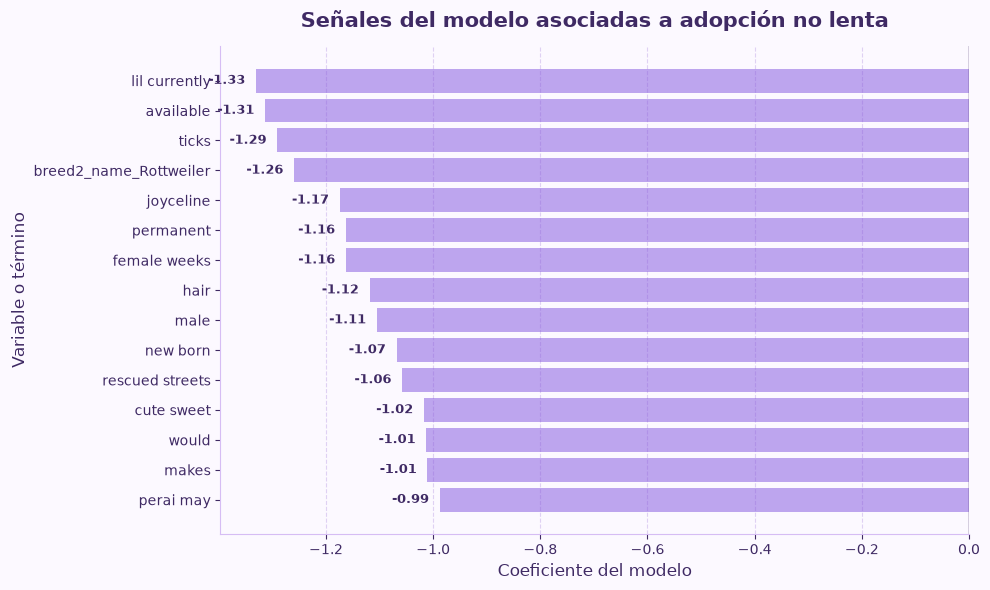

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_senales_modelo_asociadas_adopcion_no_lenta.png


In [111]:
# Gráfico de señales más asociadas a adopción no lenta

datos_no_lenta_plot = (
    features_adopcion_no_lenta
    .head(15)
    .sort_values("coeficiente", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_no_lenta_plot["feature_limpia"],
    datos_no_lenta_plot["coeficiente"],
    color="#B79CED",
    alpha=0.9
)

for i, row in enumerate(datos_no_lenta_plot.itertuples()):
    ax.text(
        row.coeficiente - 0.02,
        i,
        f"{row.coeficiente:.2f}",
        va="center",
        ha="right",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.axvline(0, color="#3F2A64", linewidth=1)

ax.set_title(
    "Señales del modelo asociadas a adopción no lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel("Coeficiente del modelo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Variable o término", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_senales_modelo_asociadas_adopcion_no_lenta.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [112]:
# Resumen de importancia por tipo de señal

resumen_importancia_tipo_feature = (
    importancia_modelo_petfinder
    .groupby("tipo_feature")
    .agg(
        n_features=("feature", "size"),
        importancia_abs_total=("coeficiente_abs", "sum"),
        importancia_abs_media=("coeficiente_abs", "mean"),
        importancia_abs_mediana=("coeficiente_abs", "median")
    )
    .reset_index()
)

resumen_importancia_tipo_feature["importancia_abs_normalizada"] = (
    resumen_importancia_tipo_feature["importancia_abs_total"]
    / resumen_importancia_tipo_feature["importancia_abs_total"].sum()
)

columnas_redondear_importancia = [
    "importancia_abs_total",
    "importancia_abs_media",
    "importancia_abs_mediana",
    "importancia_abs_normalizada"
]

resumen_importancia_tipo_feature[columnas_redondear_importancia] = (
    resumen_importancia_tipo_feature[columnas_redondear_importancia]
    .round(4)
)

resumen_importancia_tipo_feature = resumen_importancia_tipo_feature.sort_values(
    "importancia_abs_total",
    ascending=False
)

resumen_importancia_tipo_feature_path = (
    petfinder_outputs_path / "resumen_importancia_tipo_feature_petfinder.csv"
)

resumen_importancia_tipo_feature.to_csv(
    resumen_importancia_tipo_feature_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de importancia por tipo de señal:")
display(resumen_importancia_tipo_feature)

print("Resumen guardado en:")
print(resumen_importancia_tipo_feature_path)

Resumen de importancia por tipo de señal:


,tipo_feature,n_features,importancia_abs_total,importancia_abs_media,importancia_abs_mediana,importancia_abs_normalizada
0,Texto TF-IDF,5000,1116.9342,0.2234,0.1716,0.9725
1,Variable categórica,134,26.1416,0.1951,0.1126,0.0228
2,Variable numérica/booleana,42,5.4852,0.1306,0.0699,0.0048


Resumen guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resumen_importancia_tipo_feature_petfinder.csv


In [113]:
# Señales no textuales más relevantes del modelo combinado

features_no_textuales_petfinder = importancia_modelo_petfinder.loc[
    importancia_modelo_petfinder["tipo_feature"] != "Texto TF-IDF"
].copy()

features_no_textuales_lenta = (
    features_no_textuales_petfinder
    .sort_values("coeficiente", ascending=False)
    .head(20)
    .copy()
)

features_no_textuales_no_lenta = (
    features_no_textuales_petfinder
    .sort_values("coeficiente", ascending=True)
    .head(20)
    .copy()
)

features_no_textuales_lenta_path = (
    petfinder_outputs_path / "features_no_textuales_adopcion_lenta_petfinder.csv"
)

features_no_textuales_no_lenta_path = (
    petfinder_outputs_path / "features_no_textuales_adopcion_no_lenta_petfinder.csv"
)

features_no_textuales_lenta.to_csv(
    features_no_textuales_lenta_path,
    index=False,
    encoding="utf-8-sig"
)

features_no_textuales_no_lenta.to_csv(
    features_no_textuales_no_lenta_path,
    index=False,
    encoding="utf-8-sig"
)

print("Señales no textuales asociadas a adopción lenta:")
display(
    features_no_textuales_lenta[
        [
            "feature_limpia",
            "tipo_feature",
            "coeficiente"
        ]
    ].round(4)
)

print("\nSeñales no textuales asociadas a adopción no lenta:")
display(
    features_no_textuales_no_lenta[
        [
            "feature_limpia",
            "tipo_feature",
            "coeficiente"
        ]
    ].round(4)
)

Señales no textuales asociadas a adopción lenta:


,feature_limpia,tipo_feature,coeficiente
28,breed1_name_Mixed Breed,Variable categórica,0.9886
110,has_photo,Variable numérica/booleana,0.7491
115,breed1_name_Spitz,Variable categórica,0.7424
141,breed2_name_Mixed Breed,Variable categórica,0.7107
269,breed1_name_Terrier,Variable categórica,0.6112
636,state_name_Pahang,Variable categórica,0.4574
684,breed1_name_Doberman Pinscher,Variable categórica,0.4429
748,breed2_name_Golden Retriever,Variable categórica,0.4249
788,color3_name_Yellow,Variable categórica,0.4147
796,fee_group_Fee 51-100,Variable categórica,0.4132



Señales no textuales asociadas a adopción no lenta:


,feature_limpia,tipo_feature,coeficiente
4,breed2_name_Rottweiler,Variable categórica,-1.2595
124,label_score_mean,Variable numérica/booleana,-0.7299
128,age_group_petfinder_Cachorro: 0-3 meses,Variable categórica,-0.7281
249,breed1_name_German Shepherd Dog,Variable categórica,-0.6200
258,breed1_name_Chihuahua,Variable categórica,-0.6158
279,state_name_Johor,Variable categórica,-0.6019
359,maturity_size_label_infrequent_sklearn,Variable categórica,-0.5582
367,breed2_name_German Shepherd Dog,Variable categórica,-0.5543
446,breed1_name_Golden Retriever,Variable categórica,-0.5220
465,state_name_infrequent_sklearn,Variable categórica,-0.5151


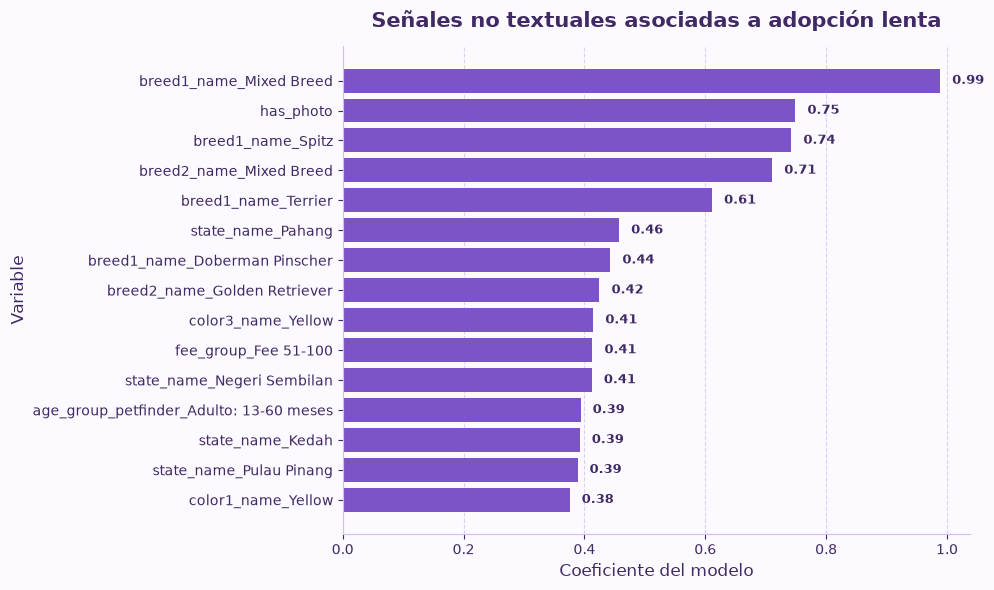

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_senales_no_textuales_adopcion_lenta.png


In [114]:
# Gráfico de señales no textuales asociadas a adopción lenta

datos_no_textuales_lenta_plot = (
    features_no_textuales_lenta
    .head(15)
    .sort_values("coeficiente", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_no_textuales_lenta_plot["feature_limpia"],
    datos_no_textuales_lenta_plot["coeficiente"],
    color="#6F42C1",
    alpha=0.9
)

for i, row in enumerate(datos_no_textuales_lenta_plot.itertuples()):
    ax.text(
        row.coeficiente + 0.02,
        i,
        f"{row.coeficiente:.2f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Señales no textuales asociadas a adopción lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)

ax.set_xlabel("Coeficiente del modelo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Variable", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "petfinder_senales_no_textuales_adopcion_lenta.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [115]:
# Selección de términos textuales interpretables

terminos_ruido_interpretabilidad = set("""
rachel joyceline puchong amy mths msg lil currently ticks
compulsory total shadow genuine currently perai may
some never then does would makes current
whatsapp sms phone email
""".split())

def es_termino_interpretable_petfinder(termino):
    termino = str(termino).lower().strip()
    
    if len(termino) < 4:
        return False
    
    tokens = termino.split()
    
    if any(token in terminos_ruido_interpretabilidad for token in tokens):
        return False
    
    if all(token in stopwords_english_basicas for token in tokens):
        return False
    
    if termino in stopwords_texto_petfinder:
        return False
    
    return True


features_textuales_interpretables = importancia_modelo_petfinder.loc[
    importancia_modelo_petfinder["tipo_feature"] == "Texto TF-IDF"
].copy()

features_textuales_interpretables = features_textuales_interpretables.loc[
    features_textuales_interpretables["feature_limpia"].apply(es_termino_interpretable_petfinder)
].copy()

features_textuales_lenta_interpretables = (
    features_textuales_interpretables
    .sort_values("coeficiente", ascending=False)
    .head(25)
    .copy()
)

features_textuales_no_lenta_interpretables = (
    features_textuales_interpretables
    .sort_values("coeficiente", ascending=True)
    .head(25)
    .copy()
)

features_textuales_lenta_interpretables_path = (
    petfinder_outputs_path / "features_textuales_interpretables_adopcion_lenta_petfinder.csv"
)

features_textuales_no_lenta_interpretables_path = (
    petfinder_outputs_path / "features_textuales_interpretables_adopcion_no_lenta_petfinder.csv"
)

features_textuales_lenta_interpretables.to_csv(
    features_textuales_lenta_interpretables_path,
    index=False,
    encoding="utf-8-sig"
)

features_textuales_no_lenta_interpretables.to_csv(
    features_textuales_no_lenta_interpretables_path,
    index=False,
    encoding="utf-8-sig"
)

print("Términos interpretables asociados a adopción lenta:")
display(
    features_textuales_lenta_interpretables[
        [
            "feature_limpia",
            "coeficiente"
        ]
    ].round(4)
)

print("\nTérminos interpretables asociados a adopción no lenta:")
display(
    features_textuales_no_lenta_interpretables[
        [
            "feature_limpia",
            "coeficiente"
        ]
    ].round(4)
)

Términos interpretables asociados a adopción lenta:


,feature_limpia,coeficiente
5,doggie,1.2556
7,adopting cute,1.1984
12,brothers,1.1302
15,traffic,1.0708
16,elderly,1.0708
19,injured,1.0680
21,furry friends,1.0439
22,helping,1.0382
24,best,1.0303
30,stray,0.9715



Términos interpretables asociados a adopción no lenta:


,feature_limpia,coeficiente
2,available,-1.3137
10,permanent,-1.1629
11,female weeks,-1.1627
13,hair,-1.1187
14,male,-1.1050
18,new born,-1.0684
20,rescued streets,-1.0578
25,cute sweet,-1.0173
31,milo,-0.9679
34,soft,-0.9600


### 11.1. Términos TF-IDF con mayor peso en el modelo de referencia

Para complementar el análisis de frecuencias, se representan los términos textuales interpretables con coeficientes más extremos en el modelo combinado de referencia. Los coeficientes positivos desplazan la predicción hacia adopción lenta y los negativos hacia adopción no lenta. La figura se utiliza como herramienta de interpretabilidad del modelo y no implica relaciones causales entre las palabras y la velocidad de adopción.


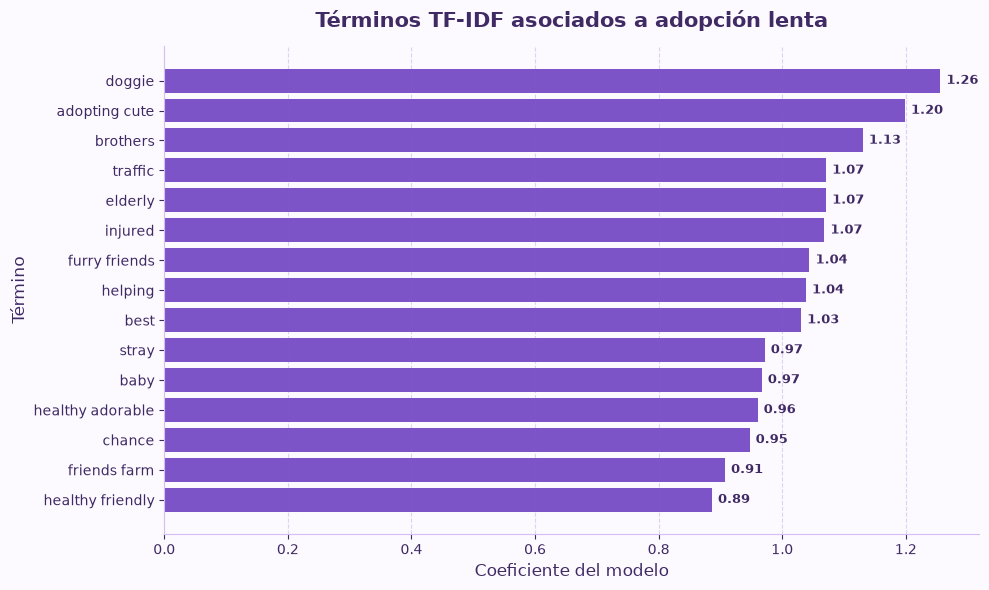

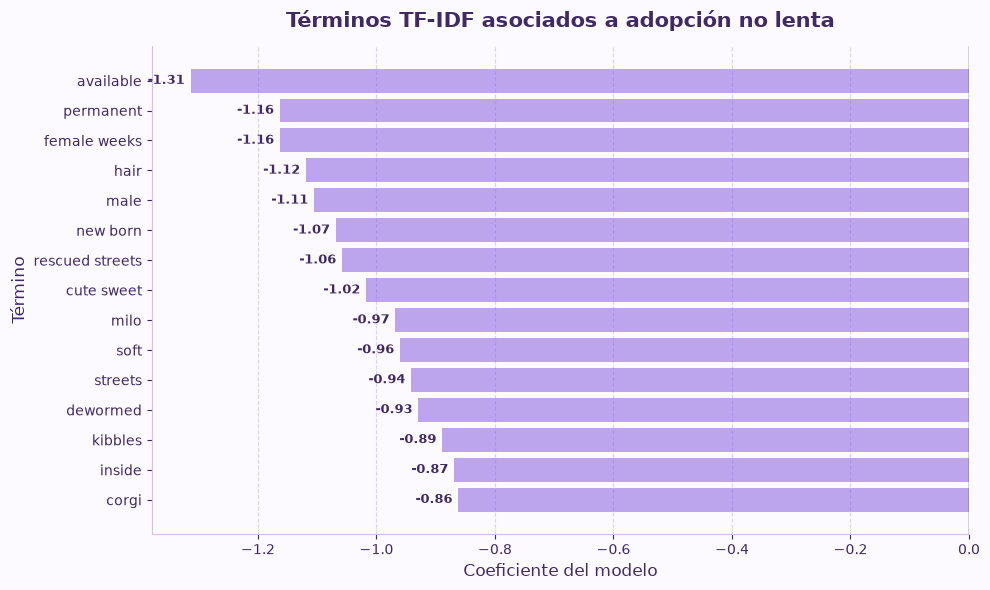

Gráficos guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_terminos_tfidf_adopcion_lenta.png
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_terminos_tfidf_adopcion_no_lenta.png


In [116]:
# Barras de términos TF-IDF interpretables con mayor peso en el modelo

datos_terminos_lenta_plot = (
    features_textuales_lenta_interpretables
    .head(15)
    .sort_values("coeficiente", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_terminos_lenta_plot["feature_limpia"],
    datos_terminos_lenta_plot["coeficiente"],
    color="#6F42C1",
    alpha=0.9
)

for i_barra, row in enumerate(datos_terminos_lenta_plot.itertuples()):
    ax.text(
        row.coeficiente + 0.01,
        i_barra,
        f"{row.coeficiente:.2f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Términos TF-IDF asociados a adopción lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)
ax.set_xlabel("Coeficiente del modelo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Término", fontsize=12, color="#3F2A64")
ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")
ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")
fig.tight_layout()

fig_path_lenta = figures_path / "petfinder_terminos_tfidf_adopcion_lenta.png"
fig.savefig(fig_path_lenta, dpi=300, bbox_inches="tight")
plt.show()


datos_terminos_no_lenta_plot = (
    features_textuales_no_lenta_interpretables
    .head(15)
    .sort_values("coeficiente", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_terminos_no_lenta_plot["feature_limpia"],
    datos_terminos_no_lenta_plot["coeficiente"],
    color="#B79CED",
    alpha=0.9
)

for i_barra, row in enumerate(datos_terminos_no_lenta_plot.itertuples()):
    ax.text(
        row.coeficiente - 0.01,
        i_barra,
        f"{row.coeficiente:.2f}",
        va="center",
        ha="right",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.axvline(0, color="#3F2A64", linewidth=1)
ax.set_title(
    "Términos TF-IDF asociados a adopción no lenta",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)
ax.set_xlabel("Coeficiente del modelo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Término", fontsize=12, color="#3F2A64")
ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")
ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")
fig.tight_layout()

fig_path_no_lenta = figures_path / "petfinder_terminos_tfidf_adopcion_no_lenta.png"
fig.savefig(fig_path_no_lenta, dpi=300, bbox_inches="tight")
plt.show()

print("Gráficos guardados en:")
print(fig_path_lenta)
print(fig_path_no_lenta)


La interpretación del modelo combinado permite identificar qué señales están más asociadas a la predicción de adopción lenta y cuáles se relacionan con adopción no lenta.

Los coeficientes positivos representan variables o términos que empujan la predicción hacia adopción lenta, mientras que los coeficientes negativos empujan hacia adopción no lenta. Esta lectura debe interpretarse con cautela, ya que los coeficientes reflejan asociaciones aprendidas por el modelo y no relaciones causales.

En este modelo de referencia, el bloque TF-IDF concentra la mayor parte de la importancia absoluta total porque genera un número muy superior de señales individuales. Por este motivo, no debe interpretarse como que el texto explica por sí solo la práctica totalidad del modelo, sino como que el bloque textual contiene muchas señales con capacidad predictiva.

Al revisar los términos individuales, se observa que algunas señales textuales pueden ser poco interpretables, como nombres propios, localizaciones o expresiones muy específicas. Por ello, se complementa el análisis con una versión depurada de términos textuales, representaciones específicas de los coeficientes TF-IDF más relevantes y un análisis separado de variables no textuales.

En conjunto, esta lectura del modelo combinado confirma que la información de presentación pública del perro aporta valor. El texto ayuda a caracterizar la ficha del animal, mientras que las variables estructuradas, visuales y de metadata permiten contextualizar mejor la dificultad de adopción.

Esta lectura refuerza la idea central del proyecto: el concepto de *Invisible Dogs* no se limita al perfil del animal, sino también a cómo se muestra y describe ante posibles adoptantes.


## 12. Ajuste y selección final del modelo predictivo

Tras comparar los modelos de referencia, se completa la selección del modelo PetFinder mediante un proceso de ajuste basado en validación cruzada estratificada. El objetivo es elegir una configuración con buena capacidad de generalización y con un equilibrio adecuado entre F1-score, precision, recall y calidad del ranking.

El proceso incluye cinco líneas de trabajo:

1. **Validación cruzada estratificada** sobre el conjunto de desarrollo (`train + valid`).
2. **Ajuste de hiperparámetros del modelo estructurado + TF-IDF de palabras**.
3. **TF-IDF de caracteres**, complementario al TF-IDF de palabras, para captar abreviaturas, variantes ortográficas y patrones locales del texto.
4. **SVM lineal calibrado**, adecuado para representaciones textuales dispersas y de alta dimensionalidad.
5. **Ajuste de modelos estructurados y ensemble**, combinando la señal textual con la señal de árboles cuando ambas aportan información complementaria.

Los hiperparámetros, el umbral de clasificación y los pesos del ensemble se seleccionan exclusivamente mediante predicciones *out-of-fold* sobre `train + valid`. El conjunto de test no interviene en esas decisiones y se utiliza al final para estimar el rendimiento de generalización de la configuración seleccionada.

Para la ejecución final se emplean **5 particiones de validación cruzada** y una búsqueda amplia de combinaciones de hiperparámetros.


In [117]:
# Configuración del ajuste y selección final

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    GridSearchCV,
    cross_val_predict
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report
import inspect
import joblib

# ------------------------------------------------------------
# CONFIGURACIÓN DE VALIDACIÓN CRUZADA Y BÚSQUEDA
# ------------------------------------------------------------
# Se utiliza la configuración completa para la selección final del TFM.
BUSQUEDA_EXHAUSTIVA_PETFINDER = True

if BUSQUEDA_EXHAUSTIVA_PETFINDER:
    N_SPLITS_OPT = 5
    N_ITER_TEXTO = 28
    N_ITER_TEXTO_CHAR = 24
    N_ITER_RF = 24
    N_ITER_LGBM = 24
else:
    # Opción reducida disponible únicamente para comprobaciones rápidas.
    N_SPLITS_OPT = 3
    N_ITER_TEXTO = 12
    N_ITER_TEXTO_CHAR = 10
    N_ITER_RF = 10
    N_ITER_LGBM = 10

# Las búsquedas se paralelizan. Las predicciones OOF se mantienen en un
# único proceso para evitar duplicar en memoria matrices TF-IDF grandes.
N_JOBS_BUSQUEDA = -1
N_JOBS_OOF = 1

cv_opt_petfinder = StratifiedKFold(
    n_splits=N_SPLITS_OPT,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# CONJUNTO DE DESARROLLO
# ------------------------------------------------------------
# Se conserva la descripción depurada creada para TF-IDF de palabras.
# Para caracteres se utiliza una versión menos procesada de la descripción,
# ya que interesa mantener variantes ortográficas y patrones locales.
variable_texto_char_petfinder = "description_char_tfidf"

petfinder_opt_df = petfinder_model_texto_df.copy()
petfinder_opt_df[variable_texto_char_petfinder] = (
    petfinder_dogs_enriched.loc[petfinder_opt_df.index, "Description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

variables_modelizacion_petfinder_opt = list(dict.fromkeys(
    variables_modelizacion_petfinder
    + [variable_texto_petfinder, variable_texto_char_petfinder]
))

X_petfinder_opt = petfinder_opt_df[variables_modelizacion_petfinder_opt].copy()
y_petfinder_opt = petfinder_opt_df[variable_objetivo_petfinder].astype(int).copy()

# Se combinan train y valid para aprovechar todo el conjunto de desarrollo.
indices_dev_petfinder = X_train_dev_petfinder.index
indices_test_petfinder = X_test_petfinder.index

X_dev_petfinder_opt = X_petfinder_opt.loc[indices_dev_petfinder].copy()
y_dev_petfinder_opt = y_petfinder_opt.loc[indices_dev_petfinder].copy()

X_test_petfinder_opt = X_petfinder_opt.loc[indices_test_petfinder].copy()
y_test_petfinder_opt = y_petfinder_opt.loc[indices_test_petfinder].copy()

print("Búsqueda exhaustiva:", BUSQUEDA_EXHAUSTIVA_PETFINDER)
print("Nº folds CV:", N_SPLITS_OPT)
print("Desarrollo (train + valid):", X_dev_petfinder_opt.shape)
print("Test reservado para evaluación del modelo final:", X_test_petfinder_opt.shape)
print("Tasa de adopción lenta en desarrollo:", round(float(y_dev_petfinder_opt.mean()), 4))


Búsqueda exhaustiva: True
Nº folds CV: 5
Desarrollo (train + valid): (6505, 75)
Test reservado para evaluación del modelo final: (1627, 75)
Tasa de adopción lenta en desarrollo: 0.5365


In [118]:
# Funciones auxiliares para la selección final

def crear_preprocesador_estructurado_opt():
    """Preprocesamiento estructurado equivalente al utilizado previamente."""
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())
                    ]
                ),
                variables_numericas_petfinder + variables_booleanas_petfinder
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(
                            strategy="constant",
                            fill_value="Sin información"
                        )),
                        ("onehot", OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=20
                        ))
                    ]
                ),
                variables_categoricas_petfinder
            )
        ],
        remainder="drop"
    )


def crear_preprocesador_palabras_opt():
    """Variables estructuradas + TF-IDF de palabras."""
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())
                    ]
                ),
                variables_numericas_petfinder + variables_booleanas_petfinder
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(
                            strategy="constant",
                            fill_value="Sin información"
                        )),
                        ("onehot", OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=20
                        ))
                    ]
                ),
                variables_categoricas_petfinder
            ),
            (
                "texto_palabras",
                TfidfVectorizer(
                    max_features=5000,
                    min_df=5,
                    max_df=0.85,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    strip_accents="unicode"
                ),
                variable_texto_petfinder
            )
        ],
        remainder="drop"
    )


def crear_preprocesador_palabras_caracteres_opt():
    """Variables estructuradas + TF-IDF de palabras + TF-IDF de caracteres."""
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())
                    ]
                ),
                variables_numericas_petfinder + variables_booleanas_petfinder
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(
                            strategy="constant",
                            fill_value="Sin información"
                        )),
                        ("onehot", OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=20
                        ))
                    ]
                ),
                variables_categoricas_petfinder
            ),
            (
                "texto_palabras",
                TfidfVectorizer(
                    max_features=7000,
                    min_df=3,
                    max_df=0.95,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    strip_accents="unicode"
                ),
                variable_texto_petfinder
            ),
            (
                "texto_caracteres",
                TfidfVectorizer(
                    analyzer="char_wb",
                    max_features=5000,
                    min_df=3,
                    ngram_range=(3, 5),
                    sublinear_tf=True,
                    strip_accents="unicode"
                ),
                variable_texto_char_petfinder
            )
        ],
        remainder="drop"
    )


def obtener_scores_oof_petfinder(estimator, X, y, cv):
    """Obtiene probabilidades OOF sin utilizar el conjunto de test."""
    probabilidades = cross_val_predict(
        clone(estimator),
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=N_JOBS_OOF
    )[:, 1]
    return probabilidades


def evaluar_scores_oof_petfinder(y_true, y_score, nombre_modelo):
    """Selecciona umbral por F1 y resume métricas sobre predicciones OOF."""
    umbral, tabla_umbrales = buscar_umbral_optimo_f1_petfinder(
        y_true=y_true,
        y_score=y_score
    )
    y_pred = (y_score >= umbral).astype(int)
    metricas = calcular_metricas_petfinder(
        y_true=y_true,
        y_pred=y_pred,
        y_score=y_score,
        nombre_modelo=nombre_modelo,
        umbral=umbral
    )
    metricas["conjunto"] = "OOF_train_valid"
    return metricas, tabla_umbrales

print("Funciones auxiliares para la selección final definidas correctamente.")


Funciones auxiliares para la selección final definidas correctamente.


In [119]:
# 12.1. Ajuste del modelo estructurado + TF-IDF de palabras + regresión logística

pipeline_lr_palabras_opt = Pipeline(
    steps=[
        ("preprocesador", crear_preprocesador_palabras_opt()),
        ("modelo", LogisticRegression(
            max_iter=2500,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ]
)

parametros_lr_palabras = {
    "preprocesador__texto_palabras__max_features": [4000, 6000, 8000, 12000],
    "preprocesador__texto_palabras__min_df": [2, 3, 5, 8],
    "preprocesador__texto_palabras__max_df": [0.80, 0.90, 0.95, 1.00],
    "preprocesador__texto_palabras__ngram_range": [(1, 1), (1, 2)],
    "modelo__C": [0.25, 0.5, 1.0, 2.0, 4.0, 8.0],
    "modelo__class_weight": [None, "balanced"]
}

busqueda_lr_palabras = RandomizedSearchCV(
    estimator=pipeline_lr_palabras_opt,
    param_distributions=parametros_lr_palabras,
    n_iter=N_ITER_TEXTO,
    scoring={
        "average_precision": "average_precision",
        "roc_auc": "roc_auc"
    },
    refit="average_precision",
    cv=cv_opt_petfinder,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_BUSQUEDA,
    verbose=1,
    return_train_score=False
)

busqueda_lr_palabras.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)

mejor_lr_palabras_petfinder = busqueda_lr_palabras.best_estimator_

print("Mejores parámetros - LR + TF-IDF palabras:")
print(busqueda_lr_palabras.best_params_)
print("\nAverage Precision CV de la mejor combinación:")
print(round(float(busqueda_lr_palabras.best_score_), 4))

resultados_busqueda_lr_palabras = pd.DataFrame(busqueda_lr_palabras.cv_results_)
columnas_busqueda_lr = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "params"
]
display(
    resultados_busqueda_lr_palabras[columnas_busqueda_lr]
    .sort_values("rank_test_average_precision")
    .head(10)
)


Fitting 5 folds for each of 28 candidates, totalling 140 fits
Mejores parámetros - LR + TF-IDF palabras:
{'preprocesador__texto_palabras__ngram_range': (1, 2), 'preprocesador__texto_palabras__min_df': 3, 'preprocesador__texto_palabras__max_features': 8000, 'preprocesador__texto_palabras__max_df': 1.0, 'modelo__class_weight': None, 'modelo__C': 0.5}

Average Precision CV de la mejor combinación:
0.7387


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,params
12,1,0.738716,0.012810,0.718731,{'preprocesador__texto_palabras__ngram_range':...
23,2,0.737816,0.013157,0.717541,{'preprocesador__texto_palabras__ngram_range':...
20,2,0.737816,0.013157,0.717541,{'preprocesador__texto_palabras__ngram_range':...
18,4,0.736770,0.011213,0.716521,{'preprocesador__texto_palabras__ngram_range':...
6,5,0.736592,0.014686,0.715996,{'preprocesador__texto_palabras__ngram_range':...
21,6,0.735710,0.012972,0.715454,{'preprocesador__texto_palabras__ngram_range':...
19,7,0.735619,0.011410,0.713964,{'preprocesador__texto_palabras__ngram_range':...
1,8,0.734398,0.011374,0.713168,{'preprocesador__texto_palabras__ngram_range':...
22,8,0.734398,0.011374,0.713168,{'preprocesador__texto_palabras__ngram_range':...
2,10,0.734055,0.012477,0.712638,{'preprocesador__texto_palabras__ngram_range':...


In [120]:
# 12.2. Modelo estructurado + TF-IDF de palabras y caracteres

pipeline_lr_palabras_char_opt = Pipeline(
    steps=[
        ("preprocesador", crear_preprocesador_palabras_caracteres_opt()),
        ("modelo", LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ]
)

parametros_lr_palabras_char = {
    "preprocesador__texto_palabras__max_features": [5000, 7000, 10000],
    "preprocesador__texto_palabras__min_df": [2, 3, 5],
    "preprocesador__texto_caracteres__max_features": [3000, 5000, 7000],
    "preprocesador__texto_caracteres__ngram_range": [(3, 5), (3, 6), (4, 6)],
    "modelo__C": [0.25, 0.5, 1.0, 2.0, 4.0],
    "modelo__class_weight": [None, "balanced"]
}

busqueda_lr_palabras_char = RandomizedSearchCV(
    estimator=pipeline_lr_palabras_char_opt,
    param_distributions=parametros_lr_palabras_char,
    n_iter=N_ITER_TEXTO_CHAR,
    scoring={
        "average_precision": "average_precision",
        "roc_auc": "roc_auc"
    },
    refit="average_precision",
    cv=cv_opt_petfinder,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_BUSQUEDA,
    verbose=1,
    return_train_score=False
)

busqueda_lr_palabras_char.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)

mejor_lr_palabras_char_petfinder = busqueda_lr_palabras_char.best_estimator_

print("Mejores parámetros - LR + palabras + caracteres:")
print(busqueda_lr_palabras_char.best_params_)
print("\nAverage Precision CV de la mejor combinación:")
print(round(float(busqueda_lr_palabras_char.best_score_), 4))

resultados_busqueda_lr_palabras_char = pd.DataFrame(busqueda_lr_palabras_char.cv_results_)
display(
    resultados_busqueda_lr_palabras_char[
        [
            "rank_test_average_precision",
            "mean_test_average_precision",
            "std_test_average_precision",
            "mean_test_roc_auc",
            "params"
        ]
    ]
    .sort_values("rank_test_average_precision")
    .head(10)
)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros - LR + palabras + caracteres:
{'preprocesador__texto_palabras__min_df': 3, 'preprocesador__texto_palabras__max_features': 10000, 'preprocesador__texto_caracteres__ngram_range': (3, 6), 'preprocesador__texto_caracteres__max_features': 3000, 'modelo__class_weight': 'balanced', 'modelo__C': 0.5}

Average Precision CV de la mejor combinación:
0.742


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,params
14,1,0.742010,0.013801,0.720231,"{'preprocesador__texto_palabras__min_df': 3, '..."
11,2,0.741919,0.014830,0.720910,"{'preprocesador__texto_palabras__min_df': 2, '..."
0,3,0.741821,0.014051,0.719830,"{'preprocesador__texto_palabras__min_df': 3, '..."
20,4,0.741593,0.013005,0.720075,"{'preprocesador__texto_palabras__min_df': 3, '..."
21,5,0.740970,0.013235,0.719891,"{'preprocesador__texto_palabras__min_df': 3, '..."
10,6,0.740929,0.013145,0.719866,"{'preprocesador__texto_palabras__min_df': 2, '..."
16,7,0.740648,0.014753,0.719083,"{'preprocesador__texto_palabras__min_df': 5, '..."
17,8,0.740458,0.013450,0.719205,"{'preprocesador__texto_palabras__min_df': 3, '..."
6,9,0.739923,0.014815,0.718518,"{'preprocesador__texto_palabras__min_df': 2, '..."
2,10,0.739886,0.014779,0.718521,"{'preprocesador__texto_palabras__min_df': 5, '..."


In [121]:
# 12.3. SVM lineal calibrado sobre la representación textual enriquecida

# Se reutiliza el preprocesador de palabras + caracteres seleccionado mediante CV.
preprocesador_svm_opt = clone(
    mejor_lr_palabras_char_petfinder.named_steps["preprocesador"]
)

# Compatibilidad con distintas versiones de scikit-learn.
parametros_calibrated = inspect.signature(CalibratedClassifierCV).parameters

if "estimator" in parametros_calibrated:
    svm_calibrado_base = CalibratedClassifierCV(
        estimator=LinearSVC(
            C=1.0,
            class_weight=None,
            random_state=RANDOM_STATE
        ),
        method="sigmoid",
        cv=3
    )
    nombre_parametro_c_svm = "modelo__estimator__C"
    nombre_parametro_peso_svm = "modelo__estimator__class_weight"
else:
    svm_calibrado_base = CalibratedClassifierCV(
        base_estimator=LinearSVC(
            C=1.0,
            class_weight=None,
            random_state=RANDOM_STATE
        ),
        method="sigmoid",
        cv=3
    )
    nombre_parametro_c_svm = "modelo__base_estimator__C"
    nombre_parametro_peso_svm = "modelo__base_estimator__class_weight"

pipeline_svm_calibrado_opt = Pipeline(
    steps=[
        ("preprocesador", preprocesador_svm_opt),
        ("modelo", svm_calibrado_base)
    ]
)

param_grid_svm = {
    nombre_parametro_c_svm: [0.25, 0.5, 1.0, 2.0],
    nombre_parametro_peso_svm: [None, "balanced"]
}

busqueda_svm = GridSearchCV(
    estimator=pipeline_svm_calibrado_opt,
    param_grid=param_grid_svm,
    scoring={
        "average_precision": "average_precision",
        "roc_auc": "roc_auc"
    },
    refit="average_precision",
    cv=cv_opt_petfinder,
    n_jobs=N_JOBS_BUSQUEDA,
    verbose=1,
    return_train_score=False
)

busqueda_svm.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)

mejor_svm_petfinder = busqueda_svm.best_estimator_

print("Mejores parámetros - SVM lineal calibrado:")
print(busqueda_svm.best_params_)
print("\nAverage Precision CV de la mejor combinación:")
print(round(float(busqueda_svm.best_score_), 4))

display(
    pd.DataFrame(busqueda_svm.cv_results_)[
        [
            "rank_test_average_precision",
            "mean_test_average_precision",
            "std_test_average_precision",
            "mean_test_roc_auc",
            "params"
        ]
    ]
    .sort_values("rank_test_average_precision")
    .head(10)
)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores parámetros - SVM lineal calibrado:
{'modelo__estimator__C': 0.25, 'modelo__estimator__class_weight': 'balanced'}

Average Precision CV de la mejor combinación:
0.7389


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,params
1,1,0.738858,0.015085,0.716904,"{'modelo__estimator__C': 0.25, 'modelo__estima..."
0,2,0.738502,0.015254,0.716863,"{'modelo__estimator__C': 0.25, 'modelo__estima..."
3,3,0.732772,0.015796,0.711553,"{'modelo__estimator__C': 0.5, 'modelo__estimat..."
2,4,0.732703,0.015895,0.711500,"{'modelo__estimator__C': 0.5, 'modelo__estimat..."
4,5,0.724972,0.015977,0.704987,"{'modelo__estimator__C': 1.0, 'modelo__estimat..."
5,6,0.724966,0.015710,0.704922,"{'modelo__estimator__C': 1.0, 'modelo__estimat..."
6,7,0.718166,0.015984,0.698443,"{'modelo__estimator__C': 2.0, 'modelo__estimat..."
7,8,0.717928,0.015688,0.698292,"{'modelo__estimator__C': 2.0, 'modelo__estimat..."


In [122]:
# 12.4. Ajuste de Random Forest estructurado

pipeline_rf_opt = Pipeline(
    steps=[
        ("preprocesador", crear_preprocesador_estructurado_opt()),
        ("modelo", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]
)

parametros_rf = {
    "modelo__n_estimators": [300, 450, 600, 800],
    "modelo__max_depth": [None, 12, 20, 30],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [2, 5, 10, 15],
    "modelo__max_features": ["sqrt", 0.30, 0.50],
    "modelo__class_weight": [None, "balanced_subsample"]
}

busqueda_rf = RandomizedSearchCV(
    estimator=pipeline_rf_opt,
    param_distributions=parametros_rf,
    n_iter=N_ITER_RF,
    scoring={
        "average_precision": "average_precision",
        "roc_auc": "roc_auc"
    },
    refit="average_precision",
    cv=cv_opt_petfinder,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_BUSQUEDA,
    verbose=1,
    return_train_score=False
)

busqueda_rf.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)

mejor_rf_petfinder = busqueda_rf.best_estimator_

print("Mejores parámetros - Random Forest:")
print(busqueda_rf.best_params_)
print("\nAverage Precision CV de la mejor combinación:")
print(round(float(busqueda_rf.best_score_), 4))

display(
    pd.DataFrame(busqueda_rf.cv_results_)[
        [
            "rank_test_average_precision",
            "mean_test_average_precision",
            "std_test_average_precision",
            "mean_test_roc_auc",
            "params"
        ]
    ]
    .sort_values("rank_test_average_precision")
    .head(10)
)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros - Random Forest:
{'modelo__n_estimators': 450, 'modelo__min_samples_split': 2, 'modelo__min_samples_leaf': 2, 'modelo__max_features': 'sqrt', 'modelo__max_depth': 20, 'modelo__class_weight': None}

Average Precision CV de la mejor combinación:
0.7495


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,params
17,1,0.749464,0.009664,0.725822,"{'modelo__n_estimators': 450, 'modelo__min_sam..."
19,2,0.748205,0.010465,0.724302,"{'modelo__n_estimators': 300, 'modelo__min_sam..."
2,3,0.745145,0.010822,0.720843,"{'modelo__n_estimators': 300, 'modelo__min_sam..."
15,4,0.744647,0.011198,0.721445,"{'modelo__n_estimators': 800, 'modelo__min_sam..."
6,5,0.742574,0.011572,0.716826,"{'modelo__n_estimators': 450, 'modelo__min_sam..."
8,6,0.742019,0.012768,0.714958,"{'modelo__n_estimators': 800, 'modelo__min_sam..."
3,7,0.739436,0.011274,0.710551,"{'modelo__n_estimators': 300, 'modelo__min_sam..."
12,8,0.738546,0.013255,0.711785,"{'modelo__n_estimators': 300, 'modelo__min_sam..."
23,9,0.738294,0.012543,0.712324,"{'modelo__n_estimators': 800, 'modelo__min_sam..."
5,10,0.737911,0.012248,0.711107,"{'modelo__n_estimators': 600, 'modelo__min_sam..."


In [123]:
# 12.5. Ajuste de LightGBM estructurado (si está disponible)

mejor_lgbm_petfinder = None
busqueda_lgbm = None

if lightgbm_disponible:
    pipeline_lgbm_opt = Pipeline(
        steps=[
            ("preprocesador", crear_preprocesador_estructurado_opt()),
            ("modelo", LGBMClassifier(
                objective="binary",
                random_state=RANDOM_STATE,
                n_jobs=1,
                subsample_freq=1,
                verbose=-1
            ))
        ]
    )

    parametros_lgbm = {
        "modelo__n_estimators": [300, 500, 700, 900],
        "modelo__learning_rate": [0.02, 0.03, 0.05, 0.08],
        "modelo__num_leaves": [15, 31, 47, 63],
        "modelo__max_depth": [-1, 8, 12, 16],
        "modelo__min_child_samples": [20, 40, 60, 80],
        "modelo__subsample": [0.80, 0.90, 1.00],
        "modelo__colsample_bytree": [0.70, 0.85, 1.00],
        "modelo__reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "modelo__reg_lambda": [0.5, 1.0, 2.0, 5.0]
    }

    busqueda_lgbm = RandomizedSearchCV(
        estimator=pipeline_lgbm_opt,
        param_distributions=parametros_lgbm,
        n_iter=N_ITER_LGBM,
        scoring={
            "average_precision": "average_precision",
            "roc_auc": "roc_auc"
        },
        refit="average_precision",
        cv=cv_opt_petfinder,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_BUSQUEDA,
        verbose=1,
        return_train_score=False
    )

    busqueda_lgbm.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)
    mejor_lgbm_petfinder = busqueda_lgbm.best_estimator_

    print("Mejores parámetros - LightGBM:")
    print(busqueda_lgbm.best_params_)
    print("\nAverage Precision CV de la mejor combinación:")
    print(round(float(busqueda_lgbm.best_score_), 4))

    display(
        pd.DataFrame(busqueda_lgbm.cv_results_)[
            [
                "rank_test_average_precision",
                "mean_test_average_precision",
                "std_test_average_precision",
                "mean_test_roc_auc",
                "params"
            ]
        ]
        .sort_values("rank_test_average_precision")
        .head(10)
    )
else:
    print("LightGBM no está disponible. Se omite esta búsqueda sin interrumpir el notebook.")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros - LightGBM:
{'modelo__subsample': 0.9, 'modelo__reg_lambda': 0.5, 'modelo__reg_alpha': 0.0, 'modelo__num_leaves': 15, 'modelo__n_estimators': 300, 'modelo__min_child_samples': 40, 'modelo__max_depth': -1, 'modelo__learning_rate': 0.02, 'modelo__colsample_bytree': 0.7}

Average Precision CV de la mejor combinación:
0.7445


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,params
15,1,0.744456,0.013286,0.716129,"{'modelo__subsample': 0.9, 'modelo__reg_lambda..."
3,2,0.742611,0.013426,0.713724,"{'modelo__subsample': 1.0, 'modelo__reg_lambda..."
6,3,0.741854,0.015271,0.714888,"{'modelo__subsample': 0.9, 'modelo__reg_lambda..."
18,4,0.740939,0.015708,0.714115,"{'modelo__subsample': 0.9, 'modelo__reg_lambda..."
16,5,0.740736,0.012977,0.714064,"{'modelo__subsample': 1.0, 'modelo__reg_lambda..."
4,6,0.740317,0.012670,0.712438,"{'modelo__subsample': 1.0, 'modelo__reg_lambda..."
13,7,0.740263,0.014192,0.713489,"{'modelo__subsample': 0.8, 'modelo__reg_lambda..."
5,8,0.739332,0.014343,0.712733,"{'modelo__subsample': 0.8, 'modelo__reg_lambda..."
23,9,0.738859,0.016933,0.711531,"{'modelo__subsample': 1.0, 'modelo__reg_lambda..."
17,10,0.738208,0.012461,0.709776,"{'modelo__subsample': 1.0, 'modelo__reg_lambda..."


In [124]:
# 12.6. Comparación de candidatos mediante predicciones out-of-fold

candidatos_opt_petfinder = {
    "LR + TF-IDF palabras": mejor_lr_palabras_petfinder,
    "LR + palabras + caracteres": mejor_lr_palabras_char_petfinder,
    "SVM lineal calibrado": mejor_svm_petfinder,
    "Random Forest ajustado": mejor_rf_petfinder
}

if mejor_lgbm_petfinder is not None:
    candidatos_opt_petfinder["LightGBM ajustado"] = mejor_lgbm_petfinder

scores_oof_opt_petfinder = {}
metricas_oof_opt_petfinder = []
tablas_umbrales_oof_opt_petfinder = {}

for nombre_modelo, estimator in candidatos_opt_petfinder.items():
    print(f"Generando predicciones OOF: {nombre_modelo}")

    y_oof_score = obtener_scores_oof_petfinder(
        estimator=estimator,
        X=X_dev_petfinder_opt,
        y=y_dev_petfinder_opt,
        cv=cv_opt_petfinder
    )

    metricas_oof, tabla_umbrales_oof = evaluar_scores_oof_petfinder(
        y_true=y_dev_petfinder_opt,
        y_score=y_oof_score,
        nombre_modelo=nombre_modelo
    )

    scores_oof_opt_petfinder[nombre_modelo] = y_oof_score
    tablas_umbrales_oof_opt_petfinder[nombre_modelo] = tabla_umbrales_oof
    metricas_oof_opt_petfinder.append(metricas_oof)

resultados_oof_opt_petfinder = pd.DataFrame(metricas_oof_opt_petfinder)

resultados_oof_opt_petfinder = resultados_oof_opt_petfinder.sort_values(
    ["f1_score", "average_precision", "precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

columnas_redondear_opt = [
    "umbral", "accuracy", "precision", "recall", "f1_score",
    "roc_auc", "average_precision", "pct_predichos_adopcion_lenta"
]

resultados_oof_opt_petfinder[columnas_redondear_opt] = (
    resultados_oof_opt_petfinder[columnas_redondear_opt].round(4)
)

print("Comparación OOF de candidatos para la selección final:")
display(resultados_oof_opt_petfinder)

resultados_oof_opt_path = petfinder_outputs_path / "resultados_seleccion_final_petfinder_oof.csv"
resultados_oof_opt_petfinder.to_csv(
    resultados_oof_opt_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resultados OOF guardados en:")
print(resultados_oof_opt_path)


Generando predicciones OOF: LR + TF-IDF palabras
Generando predicciones OOF: LR + palabras + caracteres
Generando predicciones OOF: SVM lineal calibrado
Generando predicciones OOF: Random Forest ajustado
Generando predicciones OOF: LightGBM ajustado
Comparación OOF de candidatos para la selección final:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,n_predichos_adopcion_lenta,pct_predichos_adopcion_lenta,conjunto
0,Random Forest ajustado,0.41,0.6338,0.6091,0.8860,0.7219,0.7254,0.7479,5076,0.7803,OOF_train_valid
1,SVM lineal calibrado,0.36,0.6146,0.5895,0.9272,0.7208,0.7172,0.7378,5489,0.8438,OOF_train_valid
2,LR + palabras + caracteres,0.31,0.6284,0.6039,0.8937,0.7207,0.7204,0.7407,5165,0.7940,OOF_train_valid
3,LR + TF-IDF palabras,0.34,0.6229,0.5980,0.9066,0.7206,0.7186,0.7372,5291,0.8134,OOF_train_valid
4,LightGBM ajustado,0.35,0.6117,0.5890,0.9140,0.7164,0.7157,0.7428,5416,0.8326,OOF_train_valid


Resultados OOF guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resultados_seleccion_final_petfinder_oof.csv


In [125]:
# 12.7. Ensemble entre la señal textual y la señal estructurada

nombres_textuales = [
    "LR + TF-IDF palabras",
    "LR + palabras + caracteres",
    "SVM lineal calibrado"
]

nombres_estructurados = [
    nombre
    for nombre in ["Random Forest ajustado", "LightGBM ajustado"]
    if nombre in candidatos_opt_petfinder
]

mejor_textual_nombre = (
    resultados_oof_opt_petfinder[
        resultados_oof_opt_petfinder["modelo"].isin(nombres_textuales)
    ]
    .sort_values(["f1_score", "average_precision", "precision"], ascending=False)
    .iloc[0]["modelo"]
)

mejor_estructurado_opt_nombre = (
    resultados_oof_opt_petfinder[
        resultados_oof_opt_petfinder["modelo"].isin(nombres_estructurados)
    ]
    .sort_values(["f1_score", "average_precision", "precision"], ascending=False)
    .iloc[0]["modelo"]
)

score_oof_textual = scores_oof_opt_petfinder[mejor_textual_nombre]
score_oof_estructurado = scores_oof_opt_petfinder[mejor_estructurado_opt_nombre]

resultados_pesos_ensemble = []

for peso_texto in np.arange(0.10, 0.91, 0.05):
    peso_texto = round(float(peso_texto), 2)
    peso_estructurado = round(1.0 - peso_texto, 2)

    score_ensemble = (
        peso_texto * score_oof_textual
        + peso_estructurado * score_oof_estructurado
    )

    umbral_ensemble, _ = buscar_umbral_optimo_f1_petfinder(
        y_true=y_dev_petfinder_opt,
        y_score=score_ensemble
    )

    pred_ensemble = (score_ensemble >= umbral_ensemble).astype(int)

    resultados_pesos_ensemble.append({
        "peso_texto": peso_texto,
        "peso_estructurado": peso_estructurado,
        "umbral": umbral_ensemble,
        "accuracy": accuracy_score(y_dev_petfinder_opt, pred_ensemble),
        "precision": precision_score(y_dev_petfinder_opt, pred_ensemble, zero_division=0),
        "recall": recall_score(y_dev_petfinder_opt, pred_ensemble, zero_division=0),
        "f1_score": f1_score(y_dev_petfinder_opt, pred_ensemble, zero_division=0),
        "roc_auc": roc_auc_score(y_dev_petfinder_opt, score_ensemble),
        "average_precision": average_precision_score(y_dev_petfinder_opt, score_ensemble)
    })

resultados_pesos_ensemble_df = pd.DataFrame(resultados_pesos_ensemble).sort_values(
    ["f1_score", "average_precision", "precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

mejor_peso_texto_petfinder = float(resultados_pesos_ensemble_df.loc[0, "peso_texto"])
mejor_peso_estructurado_petfinder = float(resultados_pesos_ensemble_df.loc[0, "peso_estructurado"])
mejor_umbral_ensemble_petfinder = float(resultados_pesos_ensemble_df.loc[0, "umbral"])

score_oof_ensemble_opt = (
    mejor_peso_texto_petfinder * score_oof_textual
    + mejor_peso_estructurado_petfinder * score_oof_estructurado
)

metricas_oof_ensemble, tabla_umbral_ensemble = evaluar_scores_oof_petfinder(
    y_true=y_dev_petfinder_opt,
    y_score=score_oof_ensemble_opt,
    nombre_modelo="Ensemble texto + estructurado"
)

print("Mejor modelo textual:", mejor_textual_nombre)
print("Mejor modelo estructurado:", mejor_estructurado_opt_nombre)
print("Peso textual:", mejor_peso_texto_petfinder)
print("Peso estructurado:", mejor_peso_estructurado_petfinder)
print("Umbral OOF del ensemble:", mejor_umbral_ensemble_petfinder)

print("\nTop de combinaciones de pesos:")
display(resultados_pesos_ensemble_df.head(10).round(4))


Mejor modelo textual: SVM lineal calibrado
Mejor modelo estructurado: Random Forest ajustado
Peso textual: 0.6
Peso estructurado: 0.4
Umbral OOF del ensemble: 0.39

Top de combinaciones de pesos:


,peso_texto,peso_estructurado,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,0.60,0.40,0.39,0.6312,0.6021,0.9221,0.7285,0.7369,0.7578
1,0.65,0.35,0.38,0.6260,0.5967,0.9341,0.7282,0.7353,0.7563
2,0.50,0.50,0.38,0.6232,0.5940,0.9404,0.7281,0.7390,0.7599
3,0.55,0.45,0.38,0.6240,0.5948,0.9381,0.7280,0.7381,0.7591
4,0.40,0.60,0.42,0.6463,0.6197,0.8817,0.7279,0.7394,0.7604
5,0.45,0.55,0.42,0.6467,0.6204,0.8799,0.7277,0.7394,0.7603
6,0.35,0.65,0.44,0.6593,0.6371,0.8481,0.7276,0.7390,0.7601
7,0.30,0.70,0.43,0.6517,0.6272,0.8648,0.7271,0.7382,0.7595
8,0.70,0.30,0.39,0.6304,0.6022,0.9169,0.7269,0.7334,0.7544
9,0.25,0.75,0.44,0.6570,0.6349,0.8487,0.7264,0.7369,0.7585


In [126]:
# 12.8. Selección final mediante OOF y evaluación en test

# Añadimos el ensemble a la comparación OOF de modelos individuales.
fila_ensemble_oof = pd.DataFrame([metricas_oof_ensemble])

comparacion_final_oof_petfinder = pd.concat(
    [
        pd.DataFrame(metricas_oof_opt_petfinder),
        fila_ensemble_oof
    ],
    ignore_index=True
).sort_values(
    ["f1_score", "average_precision", "precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

modelo_final_opt_nombre = comparacion_final_oof_petfinder.loc[0, "modelo"]
umbral_final_opt_petfinder = float(comparacion_final_oof_petfinder.loc[0, "umbral"])

print("Ranking OOF para seleccionar el modelo final:")
display(
    comparacion_final_oof_petfinder[
        [
            "modelo", "umbral", "precision", "recall",
            "f1_score", "roc_auc", "average_precision",
            "pct_predichos_adopcion_lenta"
        ]
    ].round(4)
)

print("\nModelo final seleccionado sin utilizar test:")
print(modelo_final_opt_nombre)
print("Umbral seleccionado con OOF:", round(umbral_final_opt_petfinder, 4))


# Ajuste definitivo con todo train + valid y evaluación en test
if modelo_final_opt_nombre == "Ensemble texto + estructurado":
    modelo_textual_final_opt = clone(candidatos_opt_petfinder[mejor_textual_nombre])
    modelo_estructurado_final_opt = clone(candidatos_opt_petfinder[mejor_estructurado_opt_nombre])

    modelo_textual_final_opt.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)
    modelo_estructurado_final_opt.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)

    score_test_textual = modelo_textual_final_opt.predict_proba(X_test_petfinder_opt)[:, 1]
    score_test_estructurado = modelo_estructurado_final_opt.predict_proba(X_test_petfinder_opt)[:, 1]

    y_test_score_opt_petfinder = (
        mejor_peso_texto_petfinder * score_test_textual
        + mejor_peso_estructurado_petfinder * score_test_estructurado
    )

    modelo_final_opt_petfinder = {
        "tipo": "ensemble",
        "modelo_textual_nombre": mejor_textual_nombre,
        "modelo_textual": modelo_textual_final_opt,
        "modelo_estructurado_nombre": mejor_estructurado_opt_nombre,
        "modelo_estructurado": modelo_estructurado_final_opt,
        "peso_texto": mejor_peso_texto_petfinder,
        "peso_estructurado": mejor_peso_estructurado_petfinder
    }
else:
    modelo_individual_final_opt = clone(candidatos_opt_petfinder[modelo_final_opt_nombre])
    modelo_individual_final_opt.fit(X_dev_petfinder_opt, y_dev_petfinder_opt)
    y_test_score_opt_petfinder = modelo_individual_final_opt.predict_proba(
        X_test_petfinder_opt
    )[:, 1]

    modelo_final_opt_petfinder = {
        "tipo": "individual",
        "modelo_nombre": modelo_final_opt_nombre,
        "modelo": modelo_individual_final_opt
    }

# El umbral procede exclusivamente de OOF train+valid.
y_test_pred_opt_petfinder = (
    y_test_score_opt_petfinder >= umbral_final_opt_petfinder
).astype(int)

metricas_test_opt_petfinder = calcular_metricas_petfinder(
    y_true=y_test_petfinder_opt,
    y_pred=y_test_pred_opt_petfinder,
    y_score=y_test_score_opt_petfinder,
    nombre_modelo=modelo_final_opt_nombre,
    umbral=umbral_final_opt_petfinder
)
metricas_test_opt_petfinder["conjunto"] = "test"

resultados_modelo_final_test_df = pd.DataFrame([metricas_test_opt_petfinder])
resultados_modelo_final_test_df[columnas_redondear_opt] = (
    resultados_modelo_final_test_df[columnas_redondear_opt].round(4)
)

print("\nResultado del modelo final en TEST:")
display(resultados_modelo_final_test_df)

print("\nMatriz de confusión - modelo final:")
matriz_opt = confusion_matrix(y_test_petfinder_opt, y_test_pred_opt_petfinder)
display(pd.DataFrame(
    matriz_opt,
    index=["Real no lenta", "Real lenta"],
    columns=["Predicha no lenta", "Predicha lenta"]
))

print("\nClassification report - modelo final:")
print(classification_report(
    y_test_petfinder_opt,
    y_test_pred_opt_petfinder,
    target_names=["Adopción no lenta", "Adopción lenta"],
    zero_division=0
))


Ranking OOF para seleccionar el modelo final:


,modelo,umbral,precision,recall,f1_score,roc_auc,average_precision,pct_predichos_adopcion_lenta
0,Ensemble texto + estructurado,0.39,0.6021,0.9221,0.7285,0.7369,0.7578,0.8217
1,Random Forest ajustado,0.41,0.6091,0.8860,0.7219,0.7254,0.7479,0.7803
2,SVM lineal calibrado,0.36,0.5895,0.9272,0.7208,0.7172,0.7378,0.8438
3,LR + palabras + caracteres,0.31,0.6039,0.8937,0.7207,0.7204,0.7407,0.7940
4,LR + TF-IDF palabras,0.34,0.5980,0.9066,0.7206,0.7186,0.7372,0.8134
5,LightGBM ajustado,0.35,0.5890,0.9140,0.7164,0.7157,0.7428,0.8326



Modelo final seleccionado sin utilizar test:
Ensemble texto + estructurado
Umbral seleccionado con OOF: 0.39

Resultado del modelo final en TEST:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,n_predichos_adopcion_lenta,pct_predichos_adopcion_lenta,conjunto
0,Ensemble texto + estructurado,0.39,0.6386,0.6077,0.921,0.7322,0.7384,0.758,1323,0.8132,test



Matriz de confusión - modelo final:


,Predicha no lenta,Predicha lenta
Real no lenta,235,519
Real lenta,69,804



Classification report - modelo final:
                   precision    recall  f1-score   support

Adopción no lenta       0.77      0.31      0.44       754
   Adopción lenta       0.61      0.92      0.73       873

         accuracy                           0.64      1627
        macro avg       0.69      0.62      0.59      1627
     weighted avg       0.68      0.64      0.60      1627



In [127]:
# 12.9. Comparación final con el modelo de referencia

# El modelo de referencia se evalúa en test únicamente en este punto,
# una vez fijadas todas las decisiones del modelo final.
if mejor_modelo_global_petfinder_nombre in modelos_petfinder:
    X_test_referencia = X_test_petfinder
    y_test_referencia = y_test_petfinder
else:
    X_test_referencia = X_test_texto_petfinder
    y_test_referencia = y_test_texto_petfinder

y_test_score_referencia = mejor_modelo_global_petfinder.predict_proba(
    X_test_referencia
)[:, 1]
y_test_pred_referencia = (
    y_test_score_referencia >= mejor_umbral_global_petfinder
).astype(int)

metricas_referencia_test = calcular_metricas_petfinder(
    y_true=y_test_referencia,
    y_pred=y_test_pred_referencia,
    y_score=y_test_score_referencia,
    nombre_modelo=mejor_modelo_global_petfinder_nombre,
    umbral=mejor_umbral_global_petfinder
)
metricas_referencia_test["conjunto"] = "test"

fila_referencia_test = pd.DataFrame([metricas_referencia_test])
fila_referencia_test["version"] = "Modelo de referencia"

fila_final_test = resultados_modelo_final_test_df.copy()
fila_final_test["version"] = "Modelo final (CV OOF)"

comparacion_referencia_final_petfinder = pd.concat(
    [fila_referencia_test, fila_final_test],
    ignore_index=True
)

columnas_comparacion_final = [
    "version", "modelo", "umbral", "accuracy", "precision", "recall",
    "f1_score", "roc_auc", "average_precision",
    "n_predichos_adopcion_lenta", "pct_predichos_adopcion_lenta"
]
comparacion_referencia_final_petfinder = comparacion_referencia_final_petfinder[
    columnas_comparacion_final
]

print("Comparación del modelo de referencia y el modelo final en test:")
display(comparacion_referencia_final_petfinder.round(4))

f1_referencia = float(fila_referencia_test.iloc[0]["f1_score"])
f1_final = float(resultados_modelo_final_test_df.iloc[0]["f1_score"])
auc_referencia = float(fila_referencia_test.iloc[0]["roc_auc"])
auc_final = float(resultados_modelo_final_test_df.iloc[0]["roc_auc"])
ap_referencia = float(fila_referencia_test.iloc[0]["average_precision"])
ap_final = float(resultados_modelo_final_test_df.iloc[0]["average_precision"])
precision_referencia = float(fila_referencia_test.iloc[0]["precision"])
precision_final = float(resultados_modelo_final_test_df.iloc[0]["precision"])
recall_referencia = float(fila_referencia_test.iloc[0]["recall"])
recall_final = float(resultados_modelo_final_test_df.iloc[0]["recall"])

print("\nDiferencia entre la referencia y el modelo final en test:")
print(f"F1-score:          {f1_referencia:.4f} -> {f1_final:.4f}  ({f1_final-f1_referencia:+.4f})")
print(f"ROC-AUC:           {auc_referencia:.4f} -> {auc_final:.4f}  ({auc_final-auc_referencia:+.4f})")
print(f"Average Precision: {ap_referencia:.4f} -> {ap_final:.4f}  ({ap_final-ap_referencia:+.4f})")
print(f"Precision:         {precision_referencia:.4f} -> {precision_final:.4f}  ({precision_final-precision_referencia:+.4f})")
print(f"Recall:            {recall_referencia:.4f} -> {recall_final:.4f}  ({recall_final-recall_referencia:+.4f})")

comparacion_ref_final_path = (
    petfinder_outputs_path / "comparacion_modelo_referencia_vs_final_petfinder.csv"
)
comparacion_referencia_final_petfinder.to_csv(
    comparacion_ref_final_path,
    index=False,
    encoding="utf-8-sig"
)

resultados_modelo_final_test_path = (
    petfinder_outputs_path / "resultados_modelo_final_petfinder_test.csv"
)
resultados_modelo_final_test_df.to_csv(
    resultados_modelo_final_test_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nComparación guardada en:")
print(comparacion_ref_final_path)
print("Resultados del modelo final guardados en:")
print(resultados_modelo_final_test_path)


Comparación del modelo de referencia y el modelo final en test:


,version,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,n_predichos_adopcion_lenta,pct_predichos_adopcion_lenta
0,Modelo de referencia,Estructurado + texto TF-IDF,0.31,0.6238,0.5988,0.9061,0.7211,0.7058,0.7255,1321,0.8119
1,Modelo final (CV OOF),Ensemble texto + estructurado,0.39,0.6386,0.6077,0.9210,0.7322,0.7384,0.7580,1323,0.8132



Diferencia entre la referencia y el modelo final en test:
F1-score:          0.7211 -> 0.7322  (+0.0111)
ROC-AUC:           0.7058 -> 0.7384  (+0.0326)
Average Precision: 0.7255 -> 0.7580  (+0.0325)
Precision:         0.5988 -> 0.6077  (+0.0089)
Recall:            0.9061 -> 0.9210  (+0.0149)

Comparación guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\comparacion_modelo_referencia_vs_final_petfinder.csv
Resultados del modelo final guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\resultados_modelo_final_petfinder_test.csv


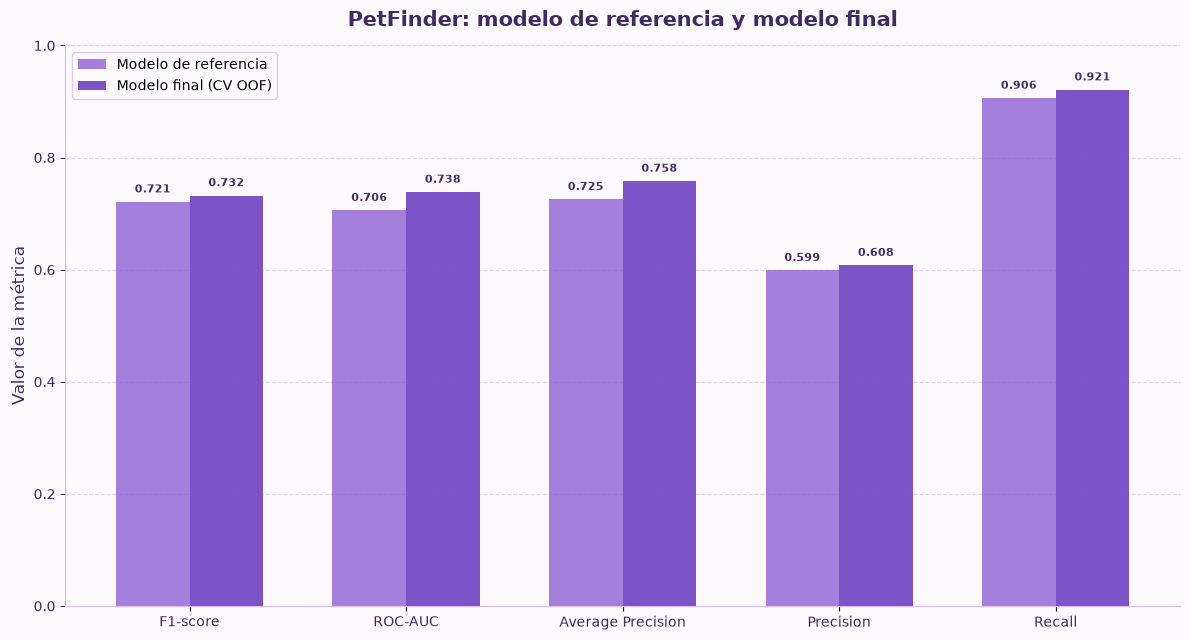

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\petfinder_modelo_referencia_vs_final.png


In [128]:
# Gráfico comparativo del modelo de referencia y el modelo final

metricas_comparacion_plot = comparacion_referencia_final_petfinder.melt(
    id_vars=["version"],
    value_vars=["f1_score", "roc_auc", "average_precision", "precision", "recall"],
    var_name="metrica",
    value_name="valor"
)

metricas_comparacion_plot["metrica"] = metricas_comparacion_plot["metrica"].map({
    "f1_score": "F1-score",
    "roc_auc": "ROC-AUC",
    "average_precision": "Average Precision",
    "precision": "Precision",
    "recall": "Recall"
})

versiones_plot = comparacion_referencia_final_petfinder["version"].tolist()
metricas_plot_opt = ["F1-score", "ROC-AUC", "Average Precision", "Precision", "Recall"]

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

x = np.arange(len(metricas_plot_opt))
width = 0.34
colores_versiones = ["#9B72D9", "#6F42C1"]

for i, version in enumerate(versiones_plot):
    valores = []
    for metrica in metricas_plot_opt:
        valor = metricas_comparacion_plot.loc[
            (metricas_comparacion_plot["version"] == version)
            & (metricas_comparacion_plot["metrica"] == metrica),
            "valor"
        ].iloc[0]
        valores.append(float(valor))

    barras = ax.bar(
        x + (i - 0.5) * width,
        valores,
        width,
        label=version,
        color=colores_versiones[i],
        alpha=0.9
    )

    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.012,
            f"{altura:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#3F2A64",
            fontweight="bold"
        )

ax.set_title(
    "PetFinder: modelo de referencia y modelo final",
    fontsize=15,
    fontweight="bold",
    color="#3F2A64",
    pad=14
)
ax.set_ylabel("Valor de la métrica", fontsize=12, color="#3F2A64")
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot_opt, color="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

legend = ax.legend(frameon=True)
legend.get_frame().set_facecolor("#FCF9FF")
legend.get_frame().set_edgecolor("#D6BDF4")

fig.tight_layout()
fig_path_opt = figures_path / "petfinder_modelo_referencia_vs_final.png"
fig.savefig(fig_path_opt, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:")
print(fig_path_opt)


In [129]:
# 12.10. Priorización Top-K, score y guardado del modelo final

topk_modelo_final_petfinder = calcular_topk_petfinder(
    y_true=y_test_petfinder_opt,
    y_score=y_test_score_opt_petfinder,
    porcentajes_top=[0.05, 0.10, 0.20, 0.30, 0.50]
)

print("Top-K del modelo final en test:")
display(topk_modelo_final_petfinder.round(4))

topk_modelo_final_petfinder_path = petfinder_outputs_path / "topk_modelo_final_petfinder_test.csv"
topk_modelo_final_petfinder.to_csv(topk_modelo_final_petfinder_path, index=False, encoding="utf-8-sig")

# Score histórico fuera de muestra para el conjunto completo.
# En desarrollo se utilizan las predicciones OOF generadas durante la selección;
# para test se reutilizan las predicciones obtenidas una vez fijado el modelo final.
# De este modo, cada perro histórico recibe un score procedente de un modelo que no
# fue ajustado utilizando esa observación concreta.
if modelo_final_opt_nombre == "Ensemble texto + estructurado":
    score_dev_historico_petfinder = np.asarray(score_oof_ensemble_opt, dtype=float)
else:
    score_dev_historico_petfinder = np.asarray(
        scores_oof_opt_petfinder[modelo_final_opt_nombre],
        dtype=float
    )

score_historico_final_petfinder = pd.Series(
    np.nan,
    index=X_petfinder_opt.index,
    dtype=float,
    name="prob_adopcion_lenta_petfinder_final"
)

score_historico_final_petfinder.loc[X_dev_petfinder_opt.index] = score_dev_historico_petfinder
score_historico_final_petfinder.loc[X_test_petfinder_opt.index] = np.asarray(
    y_test_score_opt_petfinder,
    dtype=float
)

if score_historico_final_petfinder.isna().any():
    n_faltantes_score = int(score_historico_final_petfinder.isna().sum())
    raise ValueError(
        f"Quedan {n_faltantes_score} observaciones sin score histórico fuera de muestra."
    )

petfinder_scores_finales = petfinder_dogs_enriched.copy()
petfinder_scores_finales["prob_adopcion_lenta_petfinder_final"] = (
    score_historico_final_petfinder
    .reindex(petfinder_scores_finales.index)
    .astype(float)
)
petfinder_scores_finales["petfinder_adoption_risk_score_final"] = (
    petfinder_scores_finales["prob_adopcion_lenta_petfinder_final"] * 100
).round(2)
petfinder_scores_finales["pred_adopcion_lenta_petfinder_final"] = (
    petfinder_scores_finales["prob_adopcion_lenta_petfinder_final"] >= umbral_final_opt_petfinder
).astype(int)

petfinder_scores_finales["origen_score_petfinder_final"] = "OOF desarrollo"
petfinder_scores_finales.loc[
    X_test_petfinder_opt.index,
    "origen_score_petfinder_final"
] = "Test fuera de muestra"

# Bandas de riesgo para facilitar la lectura operativa del score.
orden_bandas_petfinder = [
    "Riesgo bajo", "Riesgo medio", "Riesgo alto", "Riesgo muy alto"
]
petfinder_scores_finales["banda_riesgo_petfinder_final"] = pd.cut(
    petfinder_scores_finales["petfinder_adoption_risk_score_final"],
    bins=[-0.1, 40, 55, 70, 100],
    labels=orden_bandas_petfinder
)
petfinder_scores_finales["banda_riesgo_petfinder_final"] = pd.Categorical(
    petfinder_scores_finales["banda_riesgo_petfinder_final"],
    categories=orden_bandas_petfinder,
    ordered=True
)

columnas_ranking_final = [
    columna
    for columna in [
        "PetID", "Name", "Age", "age_group_petfinder", "breed1_name", "breed2_name",
        "state_name", "gender_label", "maturity_size_label", "sterilized_label",
        "health_label", "PhotoAmt", "VideoAmt", "description_words", "score_calidad_ficha",
        "sentiment_score", "sentiment_magnitude", "n_metadata_images",
        "pct_images_with_dog_label", "brightness_mean", "AdoptionSpeed",
        "target_adopcion_lenta", "prob_adopcion_lenta_petfinder_final",
        "petfinder_adoption_risk_score_final", "origen_score_petfinder_final",
        "banda_riesgo_petfinder_final",
        "pred_adopcion_lenta_petfinder_final"
    ]
    if columna in petfinder_scores_finales.columns
]

ranking_petfinder_final = (
    petfinder_scores_finales[columnas_ranking_final]
    .sort_values("petfinder_adoption_risk_score_final", ascending=False)
    .reset_index(drop=True)
)

print("Ranking final - primeras filas:")
display(ranking_petfinder_final.head(20))

ranking_petfinder_final_path = petfinder_outputs_path / "ranking_petfinder_final.csv"
ranking_petfinder_final.to_csv(
    ranking_petfinder_final_path,
    index=False,
    encoding="utf-8-sig"
)

petfinder_dogs_enriched_final_path = (
    processed_data_path / "petfinder_dogs_enriched_scored.csv"
)
petfinder_scores_finales.to_csv(
    petfinder_dogs_enriched_final_path,
    index=False,
    encoding="utf-8-sig"
)

models_path = outputs_path / "models"
models_path.mkdir(parents=True, exist_ok=True)

modelo_petfinder_final_package = {
    "modelo_nombre": modelo_final_opt_nombre,
    "modelo": modelo_final_opt_petfinder,
    "umbral": umbral_final_opt_petfinder,
    "variable_objetivo": variable_objetivo_petfinder,
    "mejor_textual_nombre": mejor_textual_nombre,
    "mejor_estructurado_nombre": mejor_estructurado_opt_nombre,
    "peso_texto_ensemble": mejor_peso_texto_petfinder,
    "peso_estructurado_ensemble": mejor_peso_estructurado_petfinder,
    "variables_modelizacion": variables_modelizacion_petfinder_opt,
    "variable_texto_palabras": variable_texto_petfinder,
    "variable_texto_caracteres": variable_texto_char_petfinder,
    "resultados_oof": comparacion_final_oof_petfinder,
    "resultados_test": resultados_modelo_final_test_df,
    "comparacion_referencia_vs_final": comparacion_referencia_final_petfinder,
    "topk_test": topk_modelo_final_petfinder,
    "busqueda_exhaustiva": BUSQUEDA_EXHAUSTIVA_PETFINDER,
    "n_splits_cv": N_SPLITS_OPT,
    "random_state": RANDOM_STATE,
    "nota_metodologica": (
        "Hiperparámetros, umbral y pesos del ensemble se seleccionaron "
        "sin utilizar el conjunto de test. El ranking histórico utiliza scores "
        "OOF en desarrollo y scores fuera de muestra en test; el modelo ajustado "
        "con train + valid se conserva para puntuar observaciones nuevas."
    )
}

modelo_petfinder_final_path = models_path / "modelo_complementario_petfinder_final.pkl"
joblib.dump(modelo_petfinder_final_package, modelo_petfinder_final_path)

print("Ranking final guardado en:")
print(ranking_petfinder_final_path)
print("\nDataset enriquecido y puntuado guardado en:")
print(petfinder_dogs_enriched_final_path)
print("\nModelo final guardado en:")
print(modelo_petfinder_final_path)


Top-K del modelo final en test:


,segmento,porcentaje,n_perros,casos_adopcion_lenta_detectados,precision_topk,recall_topk,lift
0,Top 5%,0.05,82,71,0.8659,0.0813,1.6137
1,Top 10%,0.10,163,144,0.8834,0.1649,1.6464
2,Top 20%,0.20,326,263,0.8067,0.3013,1.5035
3,Top 30%,0.30,489,378,0.7730,0.4330,1.4406
4,Top 50%,0.50,814,577,0.7088,0.6609,1.3211


Ranking final - primeras filas:


,PetID,Name,Age,age_group_petfinder,breed1_name,breed2_name,state_name,gender_label,maturity_size_label,sterilized_label,health_label,PhotoAmt,VideoAmt,description_words,score_calidad_ficha,sentiment_score,sentiment_magnitude,n_metadata_images,pct_images_with_dog_label,brightness_mean,AdoptionSpeed,target_adopcion_lenta,prob_adopcion_lenta_petfinder_final,petfinder_adoption_risk_score_final,origen_score_petfinder_final,banda_riesgo_petfinder_final,pred_adopcion_lenta_petfinder_final
0,bea72e6c5,Simone,24,Adulto: 13-60 meses,Mixed Breed,Sin segunda raza,Selangor,Hembra,Mediano,Sí,Sano,24.0,0,87,5,0.2,3.5,24.0,1.0,128.104958,4,1,0.916953,91.70,OOF desarrollo,Riesgo muy alto,1
1,04260adf8,Suppy,7,Joven: 4-12 meses,Mixed Breed,Mixed Breed,Johor,Macho,Mediano,No seguro,Sano,0.0,0,29,2,0.1,1.5,0.0,0.0,0.000000,4,1,0.916229,91.62,Test fuera de muestra,Riesgo muy alto,1
2,1a47d1c94,Wei Wei,48,Adulto: 13-60 meses,Mixed Breed,Sin segunda raza,Melaka,Hembra,Mediano,Sí,Sano,2.0,0,20,3,0.5,1.1,2.0,1.0,131.218000,4,1,0.900368,90.04,OOF desarrollo,Riesgo muy alto,1
3,9ca5f1891,HAPPY,48,Adulto: 13-60 meses,Mixed Breed,Mixed Breed,Selangor,Hembra,Mediano,Sí,Sano,3.0,0,4,4,0.1,2.1,3.0,1.0,75.746667,4,1,0.900388,90.04,OOF desarrollo,Riesgo muy alto,1
4,cbd0bf6b1,Lucy,24,Adulto: 13-60 meses,Mixed Breed,Sin segunda raza,Pulau Pinang,Hembra,Mediano,No seguro,Sano,1.0,0,15,3,0.6,0.6,1.0,1.0,202.413000,4,1,0.900260,90.03,OOF desarrollo,Riesgo muy alto,1
5,3f8824a3b,â¥â¥â¥ Lily â¥â¥â¥,36,Adulto: 13-60 meses,Mixed Breed,Sin segunda raza,Selangor,Hembra,Mediano,Sí,Sano,1.0,0,41,4,0.5,1.0,1.0,1.0,153.728000,4,1,0.899420,89.94,OOF desarrollo,Riesgo muy alto,1
6,6d815d3ef,Scooby31,7,Joven: 4-12 meses,Mixed Breed,Mixed Breed,Johor,Macho,Mediano,No seguro,Sano,0.0,0,29,2,0.1,1.5,0.0,0.0,0.000000,4,1,0.897581,89.76,OOF desarrollo,Riesgo muy alto,1
7,56f62a309,Bailey (Great With Kids).,24,Adulto: 13-60 meses,Mixed Breed,Sin segunda raza,Selangor,Hembra,Mediano,Sí,Sano,15.0,0,188,5,0.3,7.8,15.0,1.0,138.888867,4,1,0.893529,89.35,OOF desarrollo,Riesgo muy alto,1
8,53f434ae8,Sweet Lollipop,24,Adulto: 13-60 meses,Mixed Breed,Sin segunda raza,Selangor,Hembra,Mediano,Sí,Sano,17.0,0,31,5,0.2,0.4,17.0,1.0,100.136412,4,1,0.893129,89.31,OOF desarrollo,Riesgo muy alto,1
9,0fd5ff08e,MISON,39,Adulto: 13-60 meses,Mixed Breed,Mixed Breed,Selangor,Hembra,Mediano,Sí,Sano,3.0,0,4,4,0.1,2.1,3.0,1.0,157.994667,4,1,0.892772,89.28,OOF desarrollo,Riesgo muy alto,1


Ranking final guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\petfinder\ranking_petfinder_final.csv

Dataset enriquecido y puntuado guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\petfinder_dogs_enriched_scored.csv

Modelo final guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\modelo_complementario_petfinder_final.pkl


### 12.11. Evaluación probabilística del modelo final

Una vez cerrado el proceso de selección, se completa la evaluación del modelo final sobre el conjunto de test. Esta fase describe el comportamiento probabilístico y operativo del score definitivo, sin utilizar sus resultados para modificar hiperparámetros, pesos o umbral.


In [130]:
# Métricas probabilísticas del modelo final en test

from sklearn.metrics import brier_score_loss, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

brier_modelo_final_petfinder = brier_score_loss(
    y_test_petfinder_opt,
    y_test_score_opt_petfinder
)

metricas_calibracion_final_petfinder = pd.DataFrame([
    {
        "modelo": modelo_final_opt_nombre,
        "conjunto": "test",
        "umbral": umbral_final_opt_petfinder,
        "brier_score": brier_modelo_final_petfinder,
        "roc_auc": roc_auc_score(y_test_petfinder_opt, y_test_score_opt_petfinder),
        "average_precision": average_precision_score(y_test_petfinder_opt, y_test_score_opt_petfinder),
        "accuracy": accuracy_score(y_test_petfinder_opt, y_test_pred_opt_petfinder),
        "precision": precision_score(y_test_petfinder_opt, y_test_pred_opt_petfinder, zero_division=0),
        "recall": recall_score(y_test_petfinder_opt, y_test_pred_opt_petfinder, zero_division=0),
        "f1_score": f1_score(y_test_petfinder_opt, y_test_pred_opt_petfinder, zero_division=0),
        "tasa_base_adopcion_lenta": float(np.mean(y_test_petfinder_opt))
    }
])

columnas_prob_final = [
    "umbral", "brier_score", "roc_auc", "average_precision",
    "accuracy", "precision", "recall", "f1_score", "tasa_base_adopcion_lenta"
]
metricas_calibracion_final_petfinder[columnas_prob_final] = (
    metricas_calibracion_final_petfinder[columnas_prob_final].round(4)
)

metricas_calibracion_final_path = (
    petfinder_outputs_path / "metricas_calibracion_modelo_final_petfinder_test.csv"
)
metricas_calibracion_final_petfinder.to_csv(
    metricas_calibracion_final_path,
    index=False,
    encoding="utf-8-sig"
)

print("Métricas probabilísticas del modelo final en test:")
display(metricas_calibracion_final_petfinder)


Métricas probabilísticas del modelo final en test:


,modelo,conjunto,umbral,brier_score,roc_auc,average_precision,accuracy,precision,recall,f1_score,tasa_base_adopcion_lenta
0,Ensemble texto + estructurado,test,0.39,0.2093,0.7384,0.758,0.6386,0.6077,0.921,0.7322,0.5366


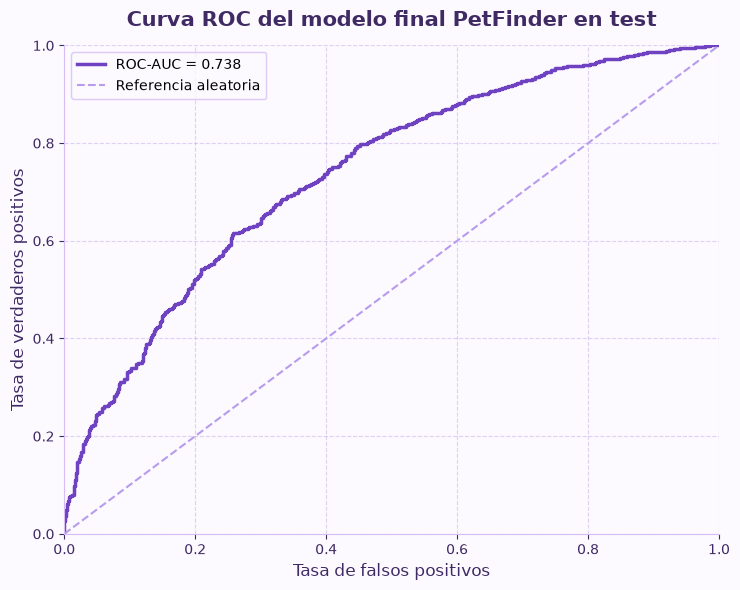

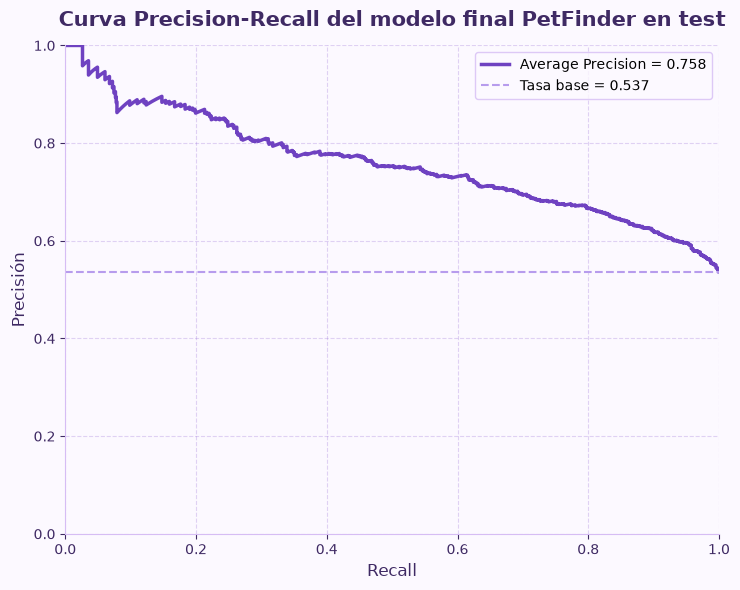

In [131]:
# Curvas ROC y Precision-Recall del modelo final en test

fpr_final, tpr_final, _ = roc_curve(
    y_test_petfinder_opt,
    y_test_score_opt_petfinder
)
precision_final_curve, recall_final_curve, _ = precision_recall_curve(
    y_test_petfinder_opt,
    y_test_score_opt_petfinder
)

roc_auc_final_plot = roc_auc_score(y_test_petfinder_opt, y_test_score_opt_petfinder)
ap_final_plot = average_precision_score(y_test_petfinder_opt, y_test_score_opt_petfinder)
tasa_base_final = float(np.mean(y_test_petfinder_opt))

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor("#FCF9FF"); ax.set_facecolor("#FCF9FF")
ax.plot(fpr_final, tpr_final, color="#6F42C1", linewidth=2.5,
        label=f"ROC-AUC = {roc_auc_final_plot:.3f}")
ax.plot([0, 1], [0, 1], color="#B79CED", linestyle="--", linewidth=1.5,
        label="Referencia aleatoria")
ax.set_title("Curva ROC del modelo final PetFinder en test",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Tasa de falsos positivos", fontsize=12, color="#3F2A64")
ax.set_ylabel("Tasa de verdaderos positivos", fontsize=12, color="#3F2A64")
ax.tick_params(axis="both", colors="#3F2A64"); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.grid(axis="both", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
legend=ax.legend(frameon=True); legend.get_frame().set_facecolor("#FCF9FF"); legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()
fig_path_roc_final = figures_path / "petfinder_curva_roc_modelo_final_test.png"
fig.savefig(fig_path_roc_final, dpi=300, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor("#FCF9FF"); ax.set_facecolor("#FCF9FF")
ax.plot(recall_final_curve, precision_final_curve, color="#6F42C1", linewidth=2.5,
        label=f"Average Precision = {ap_final_plot:.3f}")
ax.axhline(tasa_base_final, color="#B79CED", linestyle="--", linewidth=1.5,
           label=f"Tasa base = {tasa_base_final:.3f}")
ax.set_title("Curva Precision-Recall del modelo final PetFinder en test",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Recall", fontsize=12, color="#3F2A64")
ax.set_ylabel("Precisión", fontsize=12, color="#3F2A64")
ax.tick_params(axis="both", colors="#3F2A64"); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.grid(axis="both", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
legend=ax.legend(frameon=True); legend.get_frame().set_facecolor("#FCF9FF"); legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()
fig_path_pr_final = figures_path / "petfinder_curva_precision_recall_modelo_final_test.png"
fig.savefig(fig_path_pr_final, dpi=300, bbox_inches="tight"); plt.show()


Tabla de calibración del modelo final en test:


,probabilidad_media_predicha,tasa_real_adopcion_lenta,diferencia_real_menos_predicha
0,0.2874,0.1718,-0.1156
1,0.3673,0.2945,-0.0728
2,0.4208,0.3765,-0.0443
3,0.4669,0.4724,0.0055
4,0.5077,0.5092,0.0015
5,0.5534,0.5802,0.0269
6,0.6001,0.6380,0.0380
7,0.6510,0.7099,0.0588
8,0.7083,0.7301,0.0217
9,0.7858,0.8834,0.0976


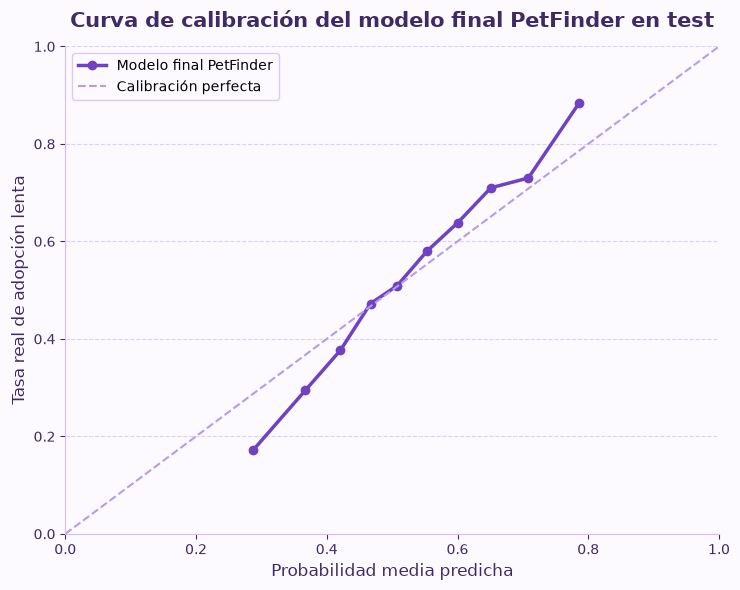

In [132]:
# Curva de calibración del modelo final en test

prob_true_final, prob_pred_final = calibration_curve(
    y_test_petfinder_opt,
    y_test_score_opt_petfinder,
    n_bins=10,
    strategy="quantile"
)

curva_calibracion_final_petfinder = pd.DataFrame({
    "probabilidad_media_predicha": prob_pred_final,
    "tasa_real_adopcion_lenta": prob_true_final
})
curva_calibracion_final_petfinder["diferencia_real_menos_predicha"] = (
    curva_calibracion_final_petfinder["tasa_real_adopcion_lenta"]
    - curva_calibracion_final_petfinder["probabilidad_media_predicha"]
)
curva_calibracion_final_petfinder = curva_calibracion_final_petfinder.round(4)

curva_calibracion_final_path = (
    petfinder_outputs_path / "curva_calibracion_modelo_final_petfinder_test.csv"
)
curva_calibracion_final_petfinder.to_csv(
    curva_calibracion_final_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de calibración del modelo final en test:")
display(curva_calibracion_final_petfinder)

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor("#FCF9FF"); ax.set_facecolor("#FCF9FF")
ax.plot(curva_calibracion_final_petfinder["probabilidad_media_predicha"],
        curva_calibracion_final_petfinder["tasa_real_adopcion_lenta"],
        marker="o", color="#6F42C1", linewidth=2.5, label="Modelo final PetFinder")
ax.plot([0,1], [0,1], color="#B79CED", linestyle="--", linewidth=1.5,
        label="Calibración perfecta")
ax.set_title("Curva de calibración del modelo final PetFinder en test",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Probabilidad media predicha", fontsize=12, color="#3F2A64")
ax.set_ylabel("Tasa real de adopción lenta", fontsize=12, color="#3F2A64")
ax.tick_params(axis="both", colors="#3F2A64"); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
legend=ax.legend(frameon=True); legend.get_frame().set_facecolor("#FCF9FF"); legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()
fig_path_calibracion_final = figures_path / "petfinder_curva_calibracion_modelo_final_test.png"
fig.savefig(fig_path_calibracion_final, dpi=300, bbox_inches="tight"); plt.show()


### 12.12. Lectura operativa del score final

Además de las métricas globales, el score se revisa mediante Top-K y bandas de riesgo. Estas lecturas permiten comprobar si los valores más altos concentran realmente una mayor proporción de perros con adopción lenta y facilitan su interpretación posterior en el prototipo.

Para el análisis histórico del conjunto completo se utilizan **scores fuera de muestra**: predicciones *out-of-fold* para los perros de `train + valid` y predicciones del conjunto reservado para los perros de `test`. El modelo ajustado posteriormente con todo `train + valid` se conserva para puntuar observaciones nuevas. De este modo, las bandas y el ranking histórico no mezclan puntuaciones *in-sample* con puntuaciones fuera de muestra.


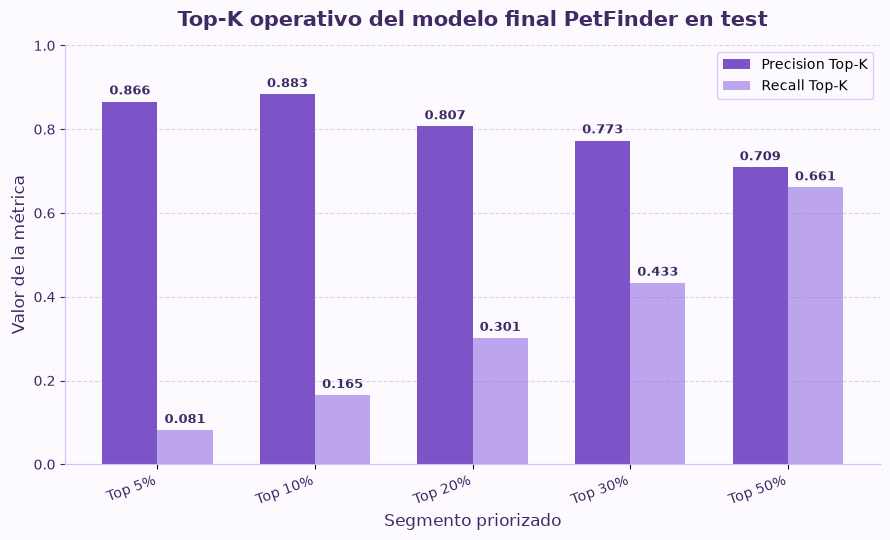

In [133]:
# Gráfico Top-K del modelo final en test

datos_topk_final_plot = topk_modelo_final_petfinder.copy()
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#FCF9FF"); ax.set_facecolor("#FCF9FF")
x = np.arange(len(datos_topk_final_plot)); width = 0.35

barras_precision = ax.bar(x - width/2, datos_topk_final_plot["precision_topk"], width,
                          label="Precision Top-K", color="#6F42C1", alpha=0.9)
barras_recall = ax.bar(x + width/2, datos_topk_final_plot["recall_topk"], width,
                       label="Recall Top-K", color="#B79CED", alpha=0.9)
for barras in [barras_precision, barras_recall]:
    for barra in barras:
        altura=barra.get_height()
        ax.text(barra.get_x()+barra.get_width()/2, altura+0.01, f"{altura:.3f}",
                ha="center", va="bottom", fontsize=9, color="#3F2A64", fontweight="bold")
ax.set_title("Top-K operativo del modelo final PetFinder en test",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Segmento priorizado", fontsize=12, color="#3F2A64")
ax.set_ylabel("Valor de la métrica", fontsize=12, color="#3F2A64")
ax.set_xticks(x); ax.set_xticklabels(datos_topk_final_plot["segmento"], rotation=20, ha="right", color="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64"); ax.set_ylim(0,1)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top","right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
legend=ax.legend(frameon=True); legend.get_frame().set_facecolor("#FCF9FF"); legend.get_frame().set_edgecolor("#D6BDF4")
fig.tight_layout()
fig_path_topk_final = figures_path / "petfinder_topk_modelo_final_test.png"
fig.savefig(fig_path_topk_final, dpi=300, bbox_inches="tight"); plt.show()


In [134]:
# Resumen por bandas del score final PetFinder

resumen_bandas_petfinder_final = (
    petfinder_scores_finales
    .groupby("banda_riesgo_petfinder_final", observed=False)
    .agg(
        n_perros=("PetID", "size"),
        porcentaje_perros=("PetID", lambda x: len(x) / len(petfinder_scores_finales) * 100),
        score_medio=("petfinder_adoption_risk_score_final", "mean"),
        score_mediano=("petfinder_adoption_risk_score_final", "median"),
        n_adopcion_lenta=("target_adopcion_lenta", "sum"),
        tasa_adopcion_lenta=("target_adopcion_lenta", "mean"),
        adoption_speed_medio=("AdoptionSpeed", "mean"),
        adoption_speed_mediano=("AdoptionSpeed", "median"),
        fotos_mediana=("PhotoAmt", "median"),
        palabras_descripcion_mediana=("description_words", "median")
    )
    .reset_index()
)

columnas_redondear_bandas = [
    "porcentaje_perros", "score_medio", "score_mediano", "tasa_adopcion_lenta",
    "adoption_speed_medio", "adoption_speed_mediano", "fotos_mediana",
    "palabras_descripcion_mediana"
]
resumen_bandas_petfinder_final[columnas_redondear_bandas] = (
    resumen_bandas_petfinder_final[columnas_redondear_bandas].round(4)
)

resumen_bandas_petfinder_final_path = (
    petfinder_outputs_path / "resumen_bandas_score_petfinder_final.csv"
)
resumen_bandas_petfinder_final.to_csv(
    resumen_bandas_petfinder_final_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen por bandas del score histórico fuera de muestra:")
display(resumen_bandas_petfinder_final)

# Resumen específico del test, manteniendo únicamente predicciones fuera de muestra.
petfinder_scores_test_final = petfinder_scores_finales.loc[X_test_petfinder.index].copy()
resumen_bandas_petfinder_test_final = (
    petfinder_scores_test_final
    .groupby("banda_riesgo_petfinder_final", observed=False)
    .agg(
        n_perros=("PetID", "size"),
        porcentaje_perros=("PetID", lambda x: len(x) / len(petfinder_scores_test_final) * 100),
        score_medio=("petfinder_adoption_risk_score_final", "mean"),
        score_mediano=("petfinder_adoption_risk_score_final", "median"),
        n_adopcion_lenta=("target_adopcion_lenta", "sum"),
        tasa_adopcion_lenta=("target_adopcion_lenta", "mean"),
        adoption_speed_medio=("AdoptionSpeed", "mean"),
        adoption_speed_mediano=("AdoptionSpeed", "median")
    )
    .reset_index()
)
columnas_redondear_test = [
    "porcentaje_perros", "score_medio", "score_mediano", "tasa_adopcion_lenta",
    "adoption_speed_medio", "adoption_speed_mediano"
]
resumen_bandas_petfinder_test_final[columnas_redondear_test] = (
    resumen_bandas_petfinder_test_final[columnas_redondear_test].round(4)
)

resumen_bandas_petfinder_test_final_path = (
    petfinder_outputs_path / "resumen_bandas_score_petfinder_final_test.csv"
)
resumen_bandas_petfinder_test_final.to_csv(
    resumen_bandas_petfinder_test_final_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nResumen por bandas del score final en test:")
display(resumen_bandas_petfinder_test_final)


Resumen por bandas del score histórico fuera de muestra:


,banda_riesgo_petfinder_final,n_perros,porcentaje_perros,score_medio,score_mediano,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,adoption_speed_mediano,fotos_mediana,palabras_descripcion_mediana
0,Riesgo bajo,1627,20.0074,33.4423,34.35,411,0.2526,1.9133,2.0,3.0,42.0
1,Riesgo medio,2860,35.1697,47.5894,47.59,1297,0.4535,2.3867,2.0,3.0,42.0
2,Riesgo alto,2351,28.9105,62.1794,61.99,1564,0.6652,2.9328,3.0,3.0,43.0
3,Riesgo muy alto,1294,15.9124,76.0303,75.38,1091,0.8431,3.4250,4.0,3.0,42.0



Resumen por bandas del score final en test:


,banda_riesgo_petfinder_final,n_perros,porcentaje_perros,score_medio,score_mediano,n_adopcion_lenta,tasa_adopcion_lenta,adoption_speed_medio,adoption_speed_mediano
0,Riesgo bajo,334,20.5286,32.9091,33.745,79,0.2365,1.8982,2.0
1,Riesgo medio,546,33.5587,47.5184,47.695,253,0.4634,2.4084,2.0
2,Riesgo alto,481,29.5636,62.1012,62.090,318,0.6611,2.9231,3.0
3,Riesgo muy alto,266,16.3491,75.9965,75.540,223,0.8383,3.3985,4.0


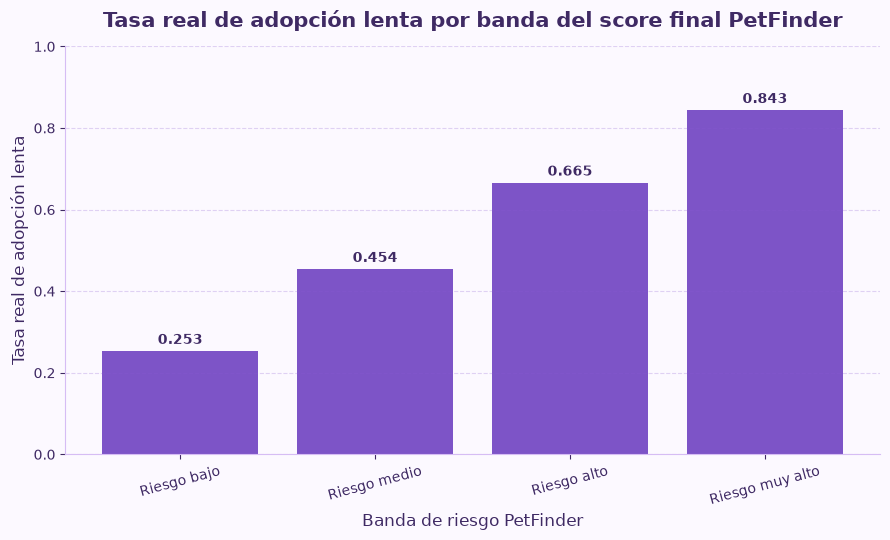

In [135]:
# Gráfico de tasa real de adopción lenta por banda del score final

datos_bandas_plot = resumen_bandas_petfinder_final.copy()
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#FCF9FF"); ax.set_facecolor("#FCF9FF")
ax.bar(datos_bandas_plot["banda_riesgo_petfinder_final"].astype(str),
       datos_bandas_plot["tasa_adopcion_lenta"], color="#6F42C1", alpha=0.9)
for i, row in enumerate(datos_bandas_plot.itertuples()):
    ax.text(i, row.tasa_adopcion_lenta + 0.01, f"{row.tasa_adopcion_lenta:.3f}",
            ha="center", va="bottom", fontsize=10, color="#3F2A64", fontweight="bold")
ax.set_title("Tasa real de adopción lenta por banda del score final PetFinder",
             fontsize=15, fontweight="bold", color="#3F2A64", pad=14)
ax.set_xlabel("Banda de riesgo PetFinder", fontsize=12, color="#3F2A64")
ax.set_ylabel("Tasa real de adopción lenta", fontsize=12, color="#3F2A64")
ax.tick_params(axis="x", colors="#3F2A64", rotation=15); ax.tick_params(axis="y", colors="#3F2A64")
ax.set_ylim(0,1); ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
for spine in ["top","right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#D6BDF4"); ax.spines["bottom"].set_color("#D6BDF4")
fig.tight_layout()
fig_path_bandas_final = figures_path / "petfinder_tasa_adopcion_lenta_bandas_score_final.png"
fig.savefig(fig_path_bandas_final, dpi=300, bbox_inches="tight"); plt.show()


In [136]:
# 12.13. Comprobación de archivos generados

archivos_finales_petfinder = {
    "Dataset perros base": processed_data_path / "petfinder_dogs_base.csv",
    "Dataset enriquecido": processed_data_path / "petfinder_dogs_enriched_completo.csv",
    "Dataset enriquecido y puntuado": petfinder_dogs_enriched_final_path,
    "Split modelización": petfinder_outputs_path / "split_petfinder_modelizacion.csv",
    "Comparación modelos valid": petfinder_outputs_path / "comparacion_global_modelos_petfinder_valid.csv",
    "Resultados selección OOF": petfinder_outputs_path / "resultados_seleccion_final_petfinder_oof.csv",
    "Resultados modelo final test": resultados_modelo_final_test_path,
    "Comparación referencia vs final": comparacion_ref_final_path,
    "Métricas calibración final": metricas_calibracion_final_path,
    "Curva calibración final": curva_calibracion_final_path,
    "Top-K modelo final": petfinder_outputs_path / "topk_modelo_final_petfinder_test.csv",
    "Resumen bandas score final": resumen_bandas_petfinder_final_path,
    "Resumen bandas score final test": resumen_bandas_petfinder_test_final_path,
    "Ranking PetFinder final": ranking_petfinder_final_path,
    "Modelo complementario final": modelo_petfinder_final_path,
    "Figura ROC final": fig_path_roc_final,
    "Figura Precision-Recall final": fig_path_pr_final,
    "Figura calibración final": fig_path_calibracion_final,
    "Figura Top-K final": fig_path_topk_final,
    "Figura bandas final": fig_path_bandas_final,
    "Figura longitud y riqueza textual": fig_path_longitud_riqueza_textual,
    "Figura word cloud textual": fig_path_wordcloud_texto,
    "Figura términos TF-IDF adopción lenta": fig_path_lenta,
    "Figura términos TF-IDF adopción no lenta": fig_path_no_lenta,
}

comprobacion_archivos_petfinder = pd.DataFrame([
    {"archivo": nombre, "ruta": str(ruta), "existe": Path(ruta).exists()}
    for nombre, ruta in archivos_finales_petfinder.items()
])

print("Comprobación de archivos generados en el notebook 05:")
display(comprobacion_archivos_petfinder)


Comprobación de archivos generados en el notebook 05:


,archivo,ruta,existe
0,Dataset perros base,g:\Mi unidad\TFM\invisible-dogs-tfm\data\proce...,True
1,Dataset enriquecido,g:\Mi unidad\TFM\invisible-dogs-tfm\data\proce...,True
2,Dataset enriquecido y puntuado,g:\Mi unidad\TFM\invisible-dogs-tfm\data\proce...,True
3,Split modelización,g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
4,Comparación modelos valid,g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
5,Resultados selección OOF,g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
6,Resultados modelo final test,g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
7,Comparación referencia vs final,g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
8,Métricas calibración final,g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
9,Curva calibración final,g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True


### 12.14. Criterios para interpretar la selección final

La selección del modelo no se basa únicamente en maximizar una única métrica. Para valorar la configuración final se revisan conjuntamente:

- **F1-score**, como métrica de equilibrio entre precision y recall.
- **Precision**, relevante para limitar el número de perros priorizados incorrectamente.
- **Recall**, porque el objetivo sigue siendo detectar la mayor parte de los perros con adopción lenta.
- **ROC-AUC y Average Precision**, que permiten valorar la calidad de la separación y del ranking con independencia de un único umbral.
- **Top-K**, para comprobar si los perros situados en la parte superior del ranking concentran una mayor proporción de casos reales de adopción lenta.

La elección se realiza con predicciones *out-of-fold* del conjunto de desarrollo. Después de fijar modelo, hiperparámetros, pesos y umbral, el test se utiliza para estimar el rendimiento final de generalización.

El ranking histórico se construye de forma independiente del ajuste de cada observación: las filas de desarrollo reciben su score OOF y las filas de test conservan su score fuera de muestra. El estimador entrenado con `train + valid` queda reservado para inferencia sobre perros nuevos.


## 13. Conclusiones del notebook

Este notebook desarrolla un análisis complementario con el dataset PetFinder.my Adoption Prediction, centrado en perros y orientado a estudiar factores asociados a adopción lenta.

A diferencia del dataset principal de Austin Animal Center, PetFinder incorpora información relacionada con la presentación pública del animal, como fotografías, vídeos, descripción textual, sentimiento del texto y metadatos visuales. Esto permite ampliar el enfoque del proyecto desde la predicción de larga estancia hacia el análisis de visibilidad de la ficha del perro.

El análisis exploratorio muestra diferencias relevantes en variables de presentación. En particular, los perros sin fotografías o sin una etiqueta visual clara de perro presentan tasas de adopción lenta superiores. Este resultado refuerza la idea de que la visibilidad visual puede ser un componente importante del problema de los *Invisible Dogs*.

El análisis textual y de sentimiento aporta señales complementarias. Las descripciones más emocionales, con mayor carga contextual o con determinadas menciones semánticas aparecen asociadas a adopción lenta. Esta relación no debe interpretarse como causal, sino como una señal de que los casos más complejos pueden requerir más explicación, difusión o contexto en la ficha pública.

La modelización se plantea de forma progresiva. Primero se comparan modelos estructurados y modelos con texto TF-IDF sobre validación. A continuación, la selección final utiliza validación cruzada estratificada de cinco particiones sobre `train + valid`, ajuste de hiperparámetros, representaciones TF-IDF de palabras y caracteres, SVM lineal calibrado y modelos estructurados ajustados. El conjunto de test permanece reservado hasta que quedan fijados modelo, pesos y umbral.

La configuración seleccionada es un **ensemble entre SVM lineal calibrado y Random Forest ajustado**, con un peso del **60 % para la señal textual y del 40 % para la señal estructurada**, y un umbral de clasificación de **0,39**. En predicciones *out-of-fold* obtiene un **F1-score de 0,7285**, **ROC-AUC de 0,7369** y **Average Precision de 0,7578**. La cercanía entre estos resultados y los obtenidos posteriormente en test respalda la estabilidad del modelo.

En el conjunto de test, el modelo final alcanza **F1-score = 0,7322**, **precision = 0,6077**, **recall = 0,9210**, **ROC-AUC = 0,7384** y **Average Precision = 0,7580**. El recall elevado resulta especialmente relevante para el objetivo del proyecto, ya que permite identificar una proporción alta de los perros con adopción lenta, mientras que ROC-AUC y Average Precision muestran una capacidad razonable para ordenar los casos según su nivel de riesgo.

La lectura Top-K refuerza esta utilidad operativa. En el **10 % de perros con mayor score**, la precision alcanza **0,8834**, lo que significa que la gran mayoría de los casos situados en ese tramo corresponden realmente a adopciones lentas. De este modo, el score puede utilizarse como herramienta de priorización cuando no es posible revisar todas las fichas con la misma intensidad.

Para construir el ranking histórico del conjunto completo, los scores se mantienen fuera de muestra: se utilizan predicciones *out-of-fold* en `train + valid` y las predicciones reservadas en `test`. El ensemble ajustado con todo el conjunto de desarrollo se conserva para puntuar perros nuevos. Esta separación evita que las bandas de riesgo históricas estén artificialmente reforzadas por predicciones *in-sample*.

La evaluación probabilística mediante Brier score, curva ROC, curva Precision-Recall y curva de calibración complementa las métricas de clasificación. El score debe interpretarse principalmente como una señal de riesgo para ordenar y priorizar casos, no como una probabilidad causal o exacta de adopción lenta.

La interpretación del modelo combinado de referencia confirma que el texto aporta señal predictiva relevante, aunque su importancia total debe leerse con cautela porque la representación TF-IDF genera un número elevado de términos. Por ello, la lectura de coeficientes se complementa con señales no textuales y términos depurados, manteniendo una interpretación prudente y no causal.

En conjunto, PetFinder confirma que la dificultad de adopción puede estudiarse desde una perspectiva complementaria al modelo principal de Austin. Mientras Austin permite construir el modelo principal de larga estancia y el *Invisible Dog Score*, PetFinder permite analizar dimensiones adicionales relacionadas con visibilidad, texto e imagen.

Por tanto, este notebook refuerza la narrativa global del TFM: los perros invisibles no son solo aquellos con mayor riesgo predictivo de permanecer más tiempo en el refugio, sino también aquellos cuya presentación pública puede dificultar que sean vistos, comprendidos o priorizados por posibles adoptantes.


## 14. Limitaciones y conexión con los siguientes notebooks

Los resultados de PetFinder deben interpretarse como un análisis complementario externo. El dataset procede de un contexto distinto al de Austin Animal Center y utiliza una variable objetivo diferente, `AdoptionSpeed`, por lo que sus resultados no se mezclan con el modelo principal del proyecto.

La variable `target_adopcion_lenta` construida a partir de `AdoptionSpeed >= 3` no es equivalente al target de larga estancia de Austin, aunque representa un concepto relacionado: animales con adopción más lenta o mayor dificultad de salida.

Además, los análisis de texto, sentimiento, imagen y calibración deben interpretarse como asociaciones descriptivas y predictivas, no como relaciones causales. La calidad de una descripción o de una imagen puede estar relacionada con muchos factores externos, como el tipo de organización, la zona geográfica, el perfil del perro o el esfuerzo de difusión. Aunque el score se expresa en una escala probabilística, su uso recomendado es la priorización operativa y el apoyo al análisis de ficha.

Este notebook aporta una base útil para los siguientes pasos del TFM. En el notebook 06 se profundizará en la parte visual y de redes neuronales, utilizando imágenes de PetFinder y apoyo de Tsinghua Dogs. El prototipo final podrá incorporar señales procedentes del score principal, la severidad estimada, el texto y la imagen para ofrecer recomendaciones prácticas de mejora de ficha y priorización.
